In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
import csv
import sys
sys.path.append('/storage/home/hcoda1/4/ashelby8/Manitoba/pyNab/src/')
import nabPy as Nab
sys.path.append('/storage/home/hcoda1/4/ashelby8/calibration/calibration/')
from FitClass import SnCalibration
from FitClass import CdCalibration
from config import conf
import FitFuncs
import pandas as pd
import pylab as py
np.set_printoptions(threshold=sys.maxsize)
pd.set_option("display.max_colwidth", 15)

In [2]:
runs = [1389,1374,1391,1392,1393]
runs2 = [1375,1376,1377,1379,1381,1383,1385]
runs_Cd = [1749,1751,1756,1760,1763,1766,1769,1407]
# [1407]
bias = [-320,-300,-250,-180,-120]
bias2 = [-320,-300,-250,-210,-180,-150,-120]
pixel = [76,87,97,106,114]

runs_300 = [1751,1407,1374]


eV_points_total = [22.102983701979042,24.13701754385965,62.5196,84.2278,363.758,387.461]
eV_points_Sn = [24.13701754385965,363.758,387.461]
eV_points_Cd = [22.102983701979042,62.5196,84.2278]

In [3]:
tempSn = [123.7832817,122.4513491,123.939699,124.1098418,124.2730173,124.3668707,124.469523]
tempSn_err = [0.04725864347,0.1034086961,0.03473400297,0.05881966838,0.0237057631,0.02900287979,0.01995262721]
tempSn2 = [122.2173443,122.1328703,122.0240803,121.9221453,121.788196,121.6360487,121.5328053]
tempSn2_err = [0.01927655469,0.02276451657,0.02894572139,0.02504217922,0.02940732004,0.0388618641,0.01927299237]

In [4]:
data = []
for i in range(len(runs)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll = pd.concat(data,ignore_index = True)

data = []
for i in range(len(runs2)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs2[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll2 = pd.concat(data,ignore_index = True)

data = []
for i in range(len(runs_Cd)):
    with open('/storage/home/hcoda1/4/ashelby8/output%d.csv'%runs_Cd[i]) as f:
        csv.DictReader(f)
        data.append(pd.read_csv(f))
dataAll_Cd = pd.concat(data,ignore_index = True)

names = []
for i in range(10):
    names.append('p%d'%i)
names_xray = []
for i in range(15):
    names_xray.append('p%d'%i)
    
def cal_data(dataAll,run,ecap_data,xray_data,ecap_err,xray_err,index):
    calibration_data = []
    sig_data = []
    calibration_error = []
    sig_error = []
    for i in range(20):
        points = []
        sig = []
        pnts_err = []
        sig_err = []
        
        i = i+21*index
        if dataAll[dataAll['run']==run]['CE'][i]==3 or dataAll[dataAll['run']==run]['CE'][i]==2:
            points.append(ecap_data['p1'][i])
            points.append(ecap_data['p4'][i])
#             points.append(ecap_data['p4'][i]*CEpeak)
            pnts_err.append(ecap_err['p1'][i])
            pnts_err.append(ecap_err['p4'][i])
        
            sig.append(ecap_data['p2'][i])
            sig.append(ecap_data['p5'][i])
            sig_err.append(ecap_err['p2'][i])
            sig_err.append(ecap_err['p5'][i])

        if dataAll[dataAll['run']==run]['CE'][i]==1:
            points.append(ecap_data['p1'][i])
            sig.append(ecap_data['p2'][i])
            
            pnts_err.append(ecap_err['p1'][i])
            sig_err.append(ecap_err['p2'][i])
            
        if dataAll[dataAll['run']==run]['Xray'][i]==5:
            points.append(xray_data['p9'][i])
            sig.append(xray_data['p10'][i])

            pnts_err.append(xray_err['p9'][i])
            sig_err.append(xray_err['p10'][i])
        
        if dataAll[dataAll['run']==run]['Xray'][i]==4:
            points.append(xray_data['p6'][i])
            sig.append(xray_data['p7'][i])

            pnts_err.append(xray_err['p6'][i])
            sig_err.append(xray_err['p7'][i])
            
        if dataAll[dataAll['run']==run]['Xray'][i]==3:
            points.append(xray_data['p3'][i])
            sig.append(xray_data['p4'][i])
            
            pnts_err.append(xray_err['p3'][i])
            sig_err.append(xray_err['p4'][i])

        calibration_data.append(points)
        sig_data.append(sig)
        calibration_error.append(pnts_err)
        sig_error.append(sig_err)
        
    return calibration_data, sig_data, calibration_error, sig_error
    
def calibration_quad(x,a,b,c):
    return a*x**2 + b*x+c

def calibration_lin(x,a,b):
    return a*x + b

def convert(x,pars):
    y = []
    for i in pars:
        lin = i[0]
        intercept = i[1]
        y.append(lin*x + intercept)     
    return y

def wave_fit(wave, func, pretrig=3000,p0=None):
    xdata = np.arange(0,len(wave))
    prewave = wave[0:int(pretrig)]
    base = np.average(prewave)
    ydata = wave - base
    if p0 == None:
        popt, pcov = curve_fit(func, xdata, ydata,maxfev=4000)
    
    else:
        try:
            popt, pcov = curve_fit(func, xdata, ydata, p0)
        except Exception as e:
            plt.plot(wave)
            return 0,0
    
    return func(xdata, *popt)+ base, popt

def wave_func(x, a,b,c,d,e,f):
    return a + b*x + c*x**2.0 + d*np.exp(-(x-e)/1250.0) / (1.0 + np.exp(-(x-e)/f))

def risetime(wave,fit_mid,low=0.1, high=0.9,pretrigger=[3000,3400], cut=0,max_delay=0, max_length=50):
    try:
        shift = np.mean(wave[pretrigger[0]:pretrigger[1]])
        wave = wave - shift
        if max_delay == 0:
            maxval = np.max(wave)
        else:
            maxval = np.mean(wave[3500+max_delay:3500+max_delay+max_length])

        wave = wave[cut:]
        xs = np.arange(len(wave))*4

        upperCross = maxval * high
        lowerCross = maxval * low

        x = np.arange(0,7000)

        upCrossPoint = np.argwhere(wave[int(fit_mid):]>upperCross)[0][0]+int(fit_mid)
        lowCrossPoint = np.argwhere(wave[:int(fit_mid)]<lowerCross)[-1][0]+1
        upper = np.interp(upperCross, wave[upCrossPoint-1:upCrossPoint+1], xs[upCrossPoint-1:upCrossPoint+1])
        lower = np.interp(lowerCross, wave[lowCrossPoint-1:lowCrossPoint+1], xs[lowCrossPoint-1:lowCrossPoint+1])
        
        return upper-lower, [lower/4+cut, upper/4+cut, maxval+shift]
    except:
        plt.plot(wave)
        plt.show()
        return 0,[0,0,0]
    
def get_risetime(runNumber,pixel,lowerE,higherE):
    
    directory = '/storage/home/hcoda1/4/ashelby8/scratch/ManitobaData/'
    run = Nab.DataRun(directory, int(runNumber), ignoreEventFile = True)
    
    risetime_list = []
    time = []
    for i in range(len(pixel)):
        run.singleWaves().resetCuts()
        run.singleWaves().defineCut('pixel', '=', int(pixel[i]))
        print('got run')
        results = run.singleWaves().determineEnergyTiming(method='trap', params=[1250, 50, 1250])

        results.resetCuts()
        results.defineCut('energy', 'between',lowerE[i],higherE[i])

        cut = results.returnCut()
        run.singleWaves().defineCut('custom', cut)
        waves = run.singleWaves().waves()
        
        
        risetimeDistribution = []
        time_mid = []
        for i in range(len(waves)):
            func, par = wave_fit(waves[i].compute(),wave_func,p0=[-5,5e-7,1e-10,-20,3500,10])
            if type(par)==int:
                pass
            else:
                time_mid.append(par[4])
                risetimeDistribution.append(risetime(waves[i].compute(),par[4],low=0.1, high=0.9)[0])

        risetime_list.append(risetimeDistribution)
        time.append(time_mid)
        
    return risetime_list, time

def gaussian(x,*pars):
    return pars[0]*np.exp(-1.0*((x-pars[1])/pars[2])**2.0)

In [5]:
df_ecap_Sn = {}
df_ecap_err_Sn = {}
for k in range(len(runs)):
    print(runs[k])
    df1 = {}
    df1_err = {}
    for i in range(len(names)):
        df1[names[i]] = {}
        df1_err[names[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll[dataAll['run']==runs[k]]['ecap'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll[dataAll['run']==runs[k]]['CE errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names):
                par_list.extend(['']*(len(names)-len(par_list)))
                err_list.extend(['']*(len(names)-len(err_list)))
            df1[names[i]][j] = par_list[i]
            df1_err[names[i]][j] = err_list[i]
    ecap_data_Sn = pd.DataFrame(df1)
    ecap_error_Sn = pd.DataFrame(df1_err)
    df_ecap_Sn[k] = df1
    df_ecap_err_Sn[k] = df1_err
    
df_xray_Sn = {}
df_xray_err_Sn = {}
for k in range(len(runs)):
    df2 = {}
    df2_err = {}
    for i in range(len(names_xray)):
        df2[names_xray[i]] = {}
        df2_err[names_xray[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll[dataAll['run']==runs[k]]['xray'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll[dataAll['run']==runs[k]]['Xray errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            
            if len(par_list) != len(names_xray):
                par_list.extend(['']*(len(names_xray)-len(par_list)))
                err_list.extend(['']*(len(names_xray)-len(err_list)))
            df2[names_xray[i]][j] = par_list[i]
            df2_err[names_xray[i]][j] = err_list[i]
    xray_data_Sn = pd.DataFrame(df2)
    xray_error_Sn = pd.DataFrame(df2_err)
    df_xray_Sn[k] = df2
    df_xray_err_Sn[k] = df2_err

1389
1374
1391
1392
1393


In [6]:
# p1 = []
# for i in range(len(calibration_Sn)):
#     l=[]
#     [l.append(calibration_Sn[i][j][0]) for j in range(len(calibration_Sn))]
#     p1.append(l)
    
# p4 = []
# for i in range(len(calibration_Sn)):
#     l=[]
#     [l.append(calibration_Sn[i][j][1]) for j in range(len(calibration_Sn))]
#     p4.append(l)
    
# p9 = []
# for i in range(len(calibration_Sn)):
#     l=[]
#     [l.append(calibration_Sn[i][j][2]) for j in range(len(calibration_Sn))]
#     p9.append(l)

In [7]:
# p1 = []
# for i in range(len(df_ecap_Sn)):
#     l=[]
#     [l.append(v) for k,v in df_ecap_Sn[i]['p1'].items()]
#     p1.append(l)
    
# p4 = []
# for i in range(len(df_ecap_Sn)):
#     l=[]
#     for k,v in df_ecap_Sn[i]['p4'].items():
#         if v =='':
#             pass
#         else:
#             l.append(v)
#     p4.append(l)

In [8]:
# sum = 0
# for i in range(len(p1)):
#     sum+= np.array(p1[i])
    
# average1 = sum/len(p1)
# print(average1)

# sum = 0
# for i in range(len(p4)):
#     sum+= np.array(p4[i])
    
# average4 = sum/len(p4)

# sum = 0
# for i in range(len(p9)):
#     sum+= np.array(p9[i])
    
# average9 = sum/len(p9)

In [9]:
# print(average4)

# residual1 = p1-average1
# error1 = residual1*100/average1

# residual4 = p4-average4
# error4 = residual4*100/average4

# residual9 = p9-average9
# error9 = residual9*100/average9
# error1

In [10]:
# plt.axhline(0,linestyle = '--',color = 'black',label = 'mean')
# cnt = 0
# ind = [0,3,6,11,14]
# for j in ind:
#     for i in range(len(residual1)):
#         if i==0:
#             plt.plot(bias[i],error1[i][j],marker = 'o',color = 'C%d'%cnt,label = '%d'%pixel[ind.index(j)])
#         else:
#             plt.plot(bias[i],error1[i][j],marker = 'o',color = 'C%d'%cnt)
#     cnt += 1
# plt.legend(loc = 'upper right')

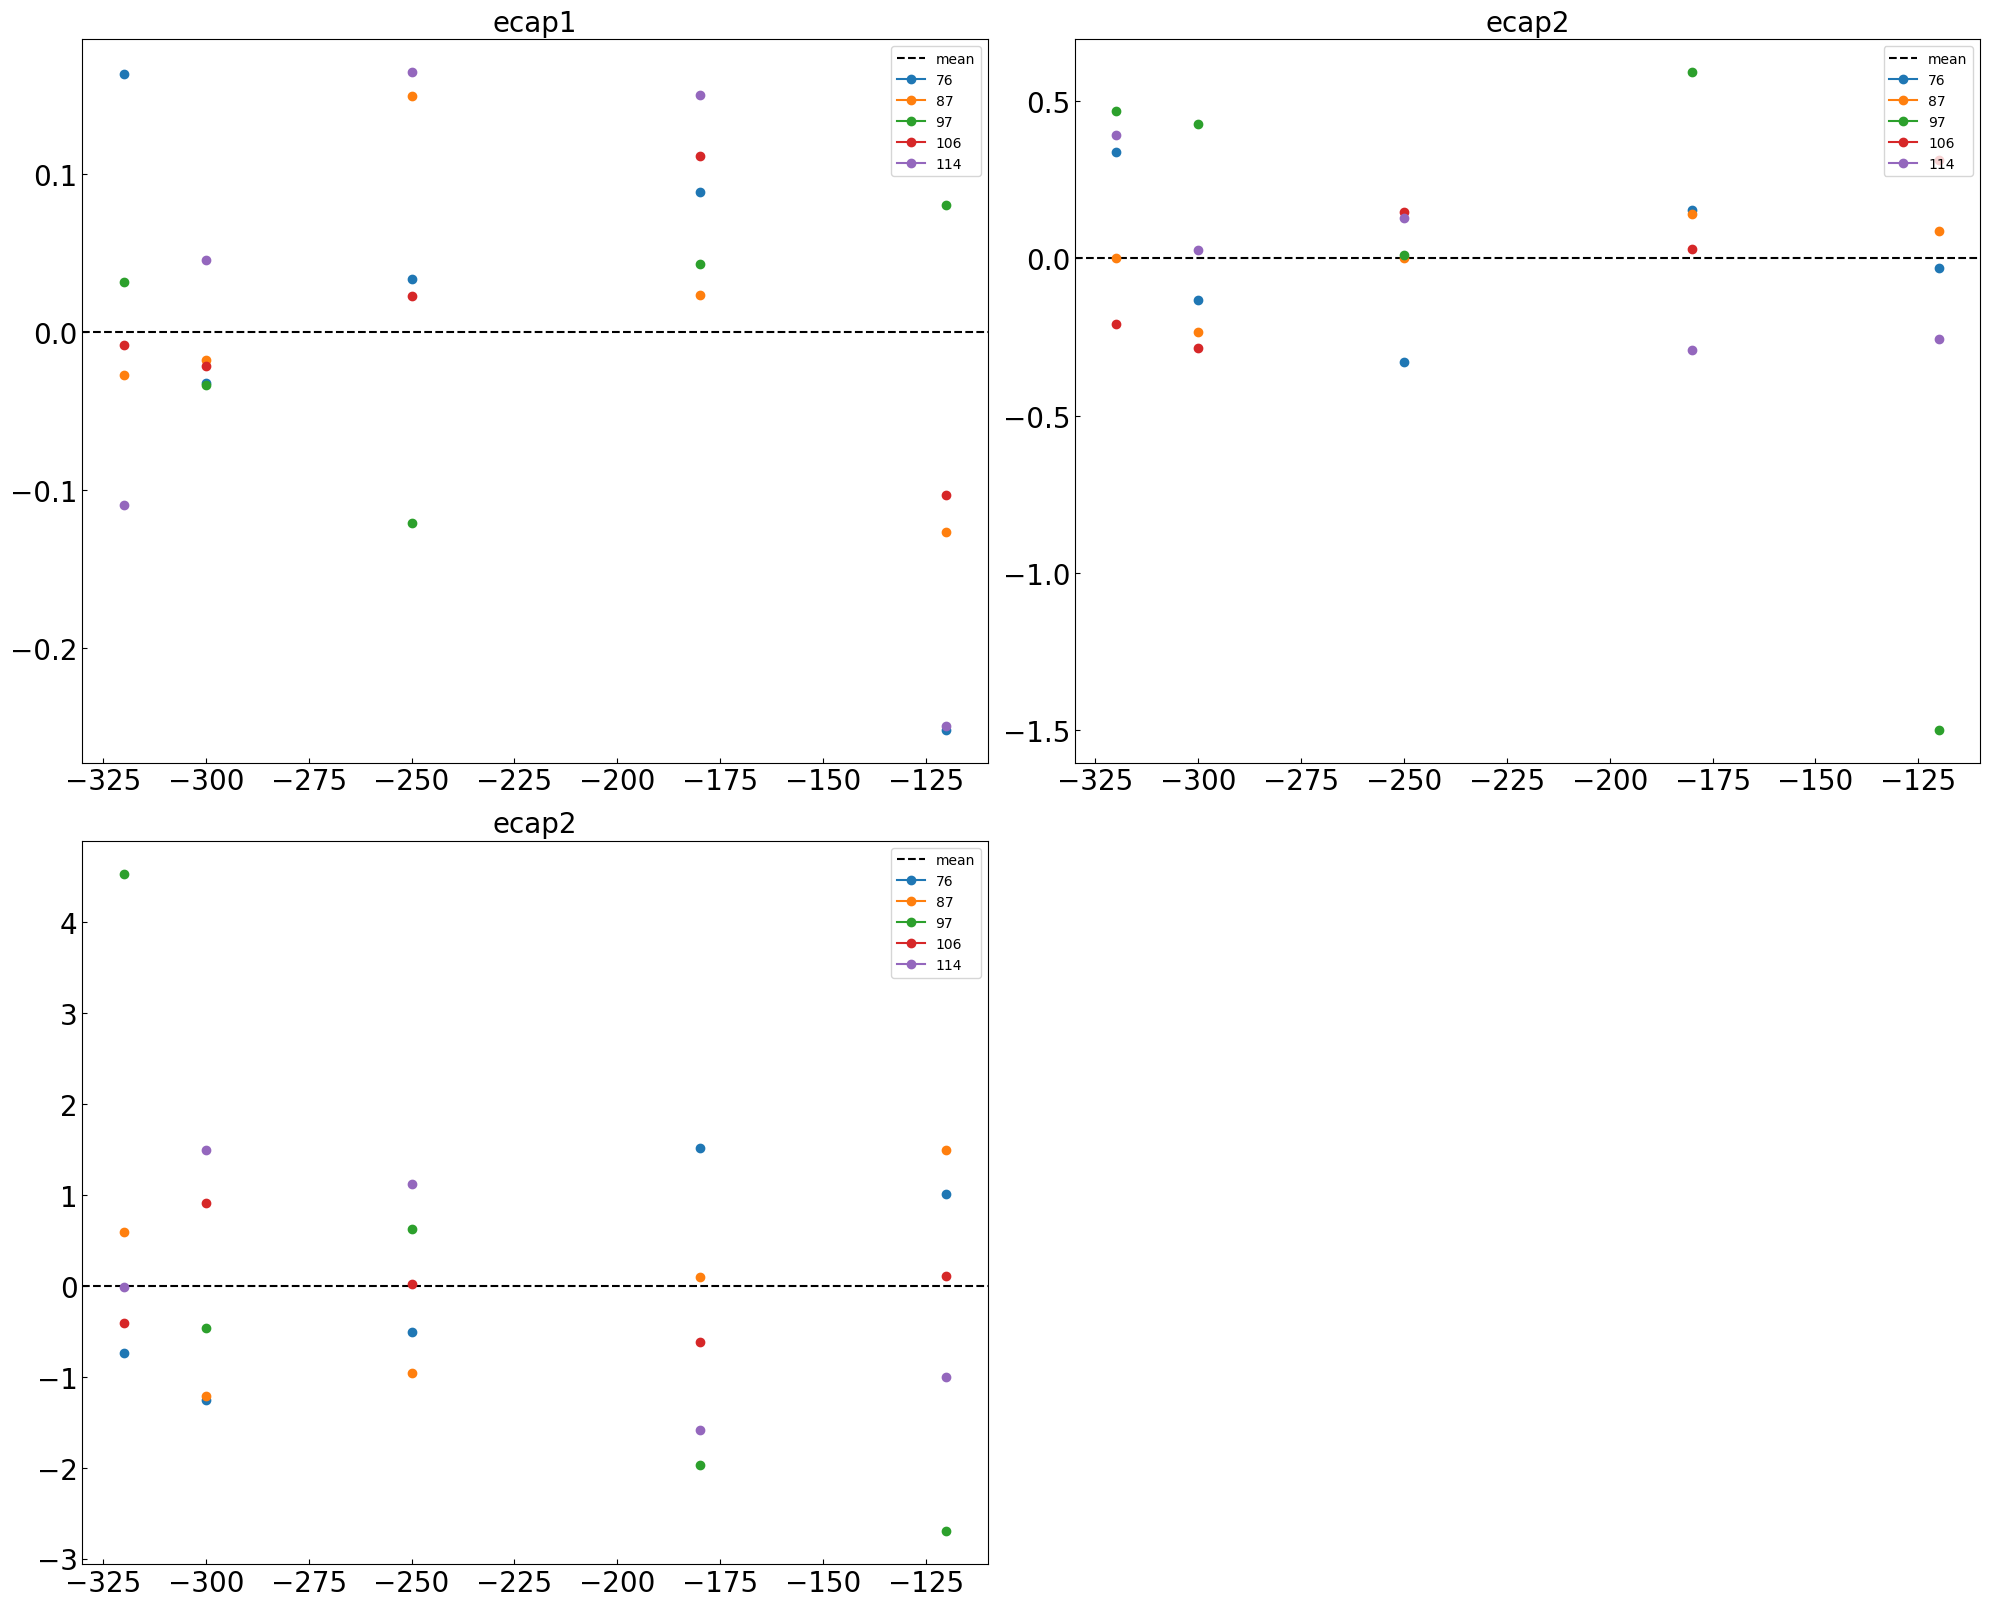

In [111]:
nrows,ncols=12,2
py.figure(figsize=(10*ncols,8*nrows))
ax=py.subplot(nrows,ncols,1)
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.axhline(0,linestyle = '--',color = 'black',label = 'mean')
ax.set_title('ecap1',size=20)
cnt = 0
ind = [0,3,6,11,14]
for j in range(len(ind)):
    for i in range(len(residual1)):
        if i==0:
            ax.plot(bias[i],error1[i][j],marker = 'o',color = 'C%d'%cnt,label = '%d'%pixel[j])
        else:
            ax.plot(bias[i],error1[i][j],marker = 'o',color = 'C%d'%cnt)
    cnt += 1
ax.legend(loc = 'upper right')

ax=py.subplot(nrows,ncols,2)
ax.axhline(0,linestyle = '--',color = 'black',label = 'mean')
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('ecap2',size=20)
cnt = 0
ind = [0,3,6,11,14]
for j in range(len(ind)):
    for i in range(len(residual4)):
        if i==0:
            ax.plot(bias[i],error4[i][j],marker = 'o',color = 'C%d'%cnt,label = '%d'%pixel[j])
        else:
            ax.plot(bias[i],error4[i][j],marker = 'o',color = 'C%d'%cnt)
    cnt += 1
ax.legend(loc = 'upper right')

ax=py.subplot(nrows,ncols,3)
ax.axhline(0,linestyle = '--',color = 'black',label = 'mean')
ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
ax.set_title('ecap2',size=20)
cnt = 0
ind = [0,3,6,11,14]
for j in range(len(ind)):
    for i in range(len(residual9)):
        if i==0:
            ax.plot(bias[i],error9[i][j],marker = 'o',color = 'C%d'%cnt,label = '%d'%pixel[j])
        else:
            ax.plot(bias[i],error9[i][j],marker = 'o',color = 'C%d'%cnt)
    cnt += 1
ax.legend(loc = 'upper right')


py.tight_layout()

In [11]:
df_ecap_Sn2 = {}
df_ecap_err_Sn2 = {}
for k in range(len(runs2)):
    print(runs2[k])
    df1 = {}
    df1_err = {}
    for i in range(len(names)):
        df1[names[i]] = {}
        df1_err[names[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll2[dataAll2['run']==runs2[k]]['ecap'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll2[dataAll2['run']==runs2[k]]['CE errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names):
                par_list.extend(['']*(len(names)-len(par_list)))
                err_list.extend(['']*(len(names)-len(err_list)))
            df1[names[i]][j] = par_list[i]
            df1_err[names[i]][j] = err_list[i]
    ecap_data_Sn2 = pd.DataFrame(df1)
    ecap_error_Sn2 = pd.DataFrame(df1_err)
    df_ecap_Sn2[k] = df1
    df_ecap_err_Sn2[k] = df1_err
    
df_xray_Sn2 = {}
df_xray_err_Sn2 = {}
for k in range(len(runs2)):
    df2 = {}
    df2_err = {}
    for i in range(len(names_xray)):
        df2[names_xray[i]] = {}
        df2_err[names_xray[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll2[dataAll2['run']==runs2[k]]['xray'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll2[dataAll2['run']==runs2[k]]['Xray errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            
            if len(par_list) != len(names_xray):
                par_list.extend(['']*(len(names_xray)-len(par_list)))
                err_list.extend(['']*(len(names_xray)-len(err_list)))
            df2[names_xray[i]][j] = par_list[i]
            df2_err[names_xray[i]][j] = err_list[i]
    xray_data_Sn2 = pd.DataFrame(df2)
    xray_error_Sn2 = pd.DataFrame(df2_err)
    df_xray_Sn2[k] = df2
    df_xray_err_Sn2[k] = df2_err

1375
1376
1377
1379
1381
1383
1385


In [12]:
df_ecap_Cd = {}
df_ecap_err_Cd = {}
for k in range(len(runs_Cd)):
    print(runs_Cd[k])
    df1 = {}
    df1_err = {}
    for i in range(len(names)):
        df1[names[i]] = {}
        df1_err[names[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['ecap'][j].replace('[','').replace(']','').split()).tolist()
            arr = []
            arr+= [np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['CE errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names):
                par_list.extend(['']*(len(names)-len(par_list)))
                err_list.extend(['']*(len(names)-len(err_list)))
            df1[names[i]][j] = par_list[i]
            df1_err[names[i]][j] = err_list[i]
    ecap_data_Cd = pd.DataFrame(df1)
    ecap_error_Cd = pd.DataFrame(df1_err)
    df_ecap_Cd[k] = df1
    df_ecap_err_Cd[k] = df1_err
    
df_xray_Cd = {}
df_xray_err_Cd = {}
for k in range(len(runs_Cd)):
    df2 = {}
    df2_err = {}
    for i in range(len(names_xray)):
        df2[names_xray[i]] = {}
        df2_err[names_xray[i]] = {}
        for j in range(20):
            j = j+k*21
            par_list = np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['xray'][j].replace('[','').replace(']','').split()).tolist()
            
            arr = []
            arr+= [np.float64(dataAll_Cd[dataAll_Cd['run']==runs_Cd[k]]['Xray errors'][j].replace('\n','').replace('[[','').replace(']]','').split('] [')[i].split()).tolist() for i in range(len(par_list))]
            err_list = np.sqrt(np.diag(np.array(arr))).tolist()
            if len(par_list) != len(names_xray):
                par_list.extend(['']*(len(names_xray)-len(par_list)))
                err_list.extend(['']*(len(names_xray)-len(err_list)))
            df2[names_xray[i]][j] = par_list[i]
            df2_err[names_xray[i]][j] = err_list[i]
    xray_data_Cd = pd.DataFrame(df2)
    xray_error_Cd = pd.DataFrame(df2_err)
    df_xray_Cd[k] = df2
    df_xray_err_Cd[k] = df2_err

1749
1751
1756
1760
1763
1766
1769
1407


In [13]:
calibration_Sn = []
sigma_Sn = []
calibration_error_Sn = []
sigma_error_Sn = []
for i in range(len(runs)):
    pars, sig, pars_err, sig_err = cal_data(dataAll,runs[i],pd.DataFrame(df_ecap_Sn[i]),pd.DataFrame(df_xray_Sn[i]),pd.DataFrame(df_ecap_err_Sn[i]),pd.DataFrame(df_xray_err_Sn[i]),i)
    calibration_Sn.append(pars)
    sigma_Sn.append(sig)
    calibration_error_Sn.append(pars_err)
    sigma_error_Sn.append(sig_err)
    
calibration_Sn2 = []
sigma_Sn2 = []
calibration_error_Sn2 = []
sigma_error_Sn2 = []
for i in range(len(runs2)):
    pars, sig, pars_err, sig_err = cal_data(dataAll2,runs2[i],pd.DataFrame(df_ecap_Sn2[i]),pd.DataFrame(df_xray_Sn2[i]),pd.DataFrame(df_ecap_err_Sn2[i]),pd.DataFrame(df_xray_err_Sn2[i]),i)
    calibration_Sn2.append(pars)
    sigma_Sn2.append(sig)
    calibration_error_Sn2.append(pars_err)
    sigma_error_Sn2.append(sig_err)
    
calibration_Cd = []
sigma_Cd = []
calibration_error_Cd = []
sigma_error_Cd = []
for i in range(len(runs_Cd)):
    pars, sig, pars_err, sig_err = cal_data(dataAll_Cd,runs_Cd[i],pd.DataFrame(df_ecap_Cd[i]),pd.DataFrame(df_xray_Cd[i]),pd.DataFrame(df_ecap_err_Cd[i]),pd.DataFrame(df_xray_err_Cd[i]),i)
    calibration_Cd.append(pars)
    sigma_Cd.append(sig)
    calibration_error_Cd.append(pars_err)
    sigma_error_Cd.append(sig_err)

In [14]:
ADC_data_Sn = []
ADC_error_Sn = []
ADC_sigma_Sn = []
ADC_sigma_error_Sn = []
for j in range(len(calibration_Sn)):
    ADC_data_Sn.append([np.sort(calibration_Sn[j][i]) for i in range(len(calibration_Sn[j]))])
    idx = [[np.argsort(calibration_Sn[j][i])] for i in range(len(calibration_Sn[j]))]
    cal_err = []
    sig = []
    sig_err = []
    for i in range(len(idx)):
        cal_err.append([calibration_error_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig.append([sigma_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig_err.append([sigma_error_Sn[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
    ADC_error_Sn.append(cal_err)
    ADC_sigma_Sn.append(sig)
    ADC_sigma_error_Sn.append(sig_err)

    
ADC_data_Sn2 = []
ADC_error_Sn2 = []
ADC_sigma_Sn2 = []
ADC_sigma_error_Sn2 = []
for j in range(len(calibration_Sn2)):
    ADC_data_Sn2.append([np.sort(calibration_Sn2[j][i]) for i in range(len(calibration_Sn2[j]))])
    idx = [[np.argsort(calibration_Sn2[j][i])] for i in range(len(calibration_Sn2[j]))]
    cal_err = []
    sig = []
    sig_err = []
    for i in range(len(idx)):
        cal_err.append([calibration_error_Sn2[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig.append([sigma_Sn2[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig_err.append([sigma_error_Sn2[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
    ADC_error_Sn2.append(cal_err)
    ADC_sigma_Sn2.append(sig)
    ADC_sigma_error_Sn2.append(sig_err)

ADC_data_Cd = []
ADC_error_Cd = []
ADC_sigma_Cd = []
ADC_sigma_error_Cd = []
for j in range(len(calibration_Cd)):
    ADC_data_Cd.append([np.sort(calibration_Cd[j][i]) for i in range(len(calibration_Cd[j]))])
    idx = [[np.argsort(calibration_Cd[j][i])] for i in range(len(calibration_Cd[j]))]
    cal_err = []
    sig = []
    sig_err = []
    for i in range(len(idx)):
        cal_err.append([calibration_error_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig.append([sigma_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
        sig_err.append([sigma_error_Cd[j][i][idx[i][0][k]] for k in range(len(idx[i][0]))])
    ADC_error_Cd.append(cal_err)
    ADC_sigma_Cd.append(sig)
    ADC_sigma_error_Cd.append(sig_err)

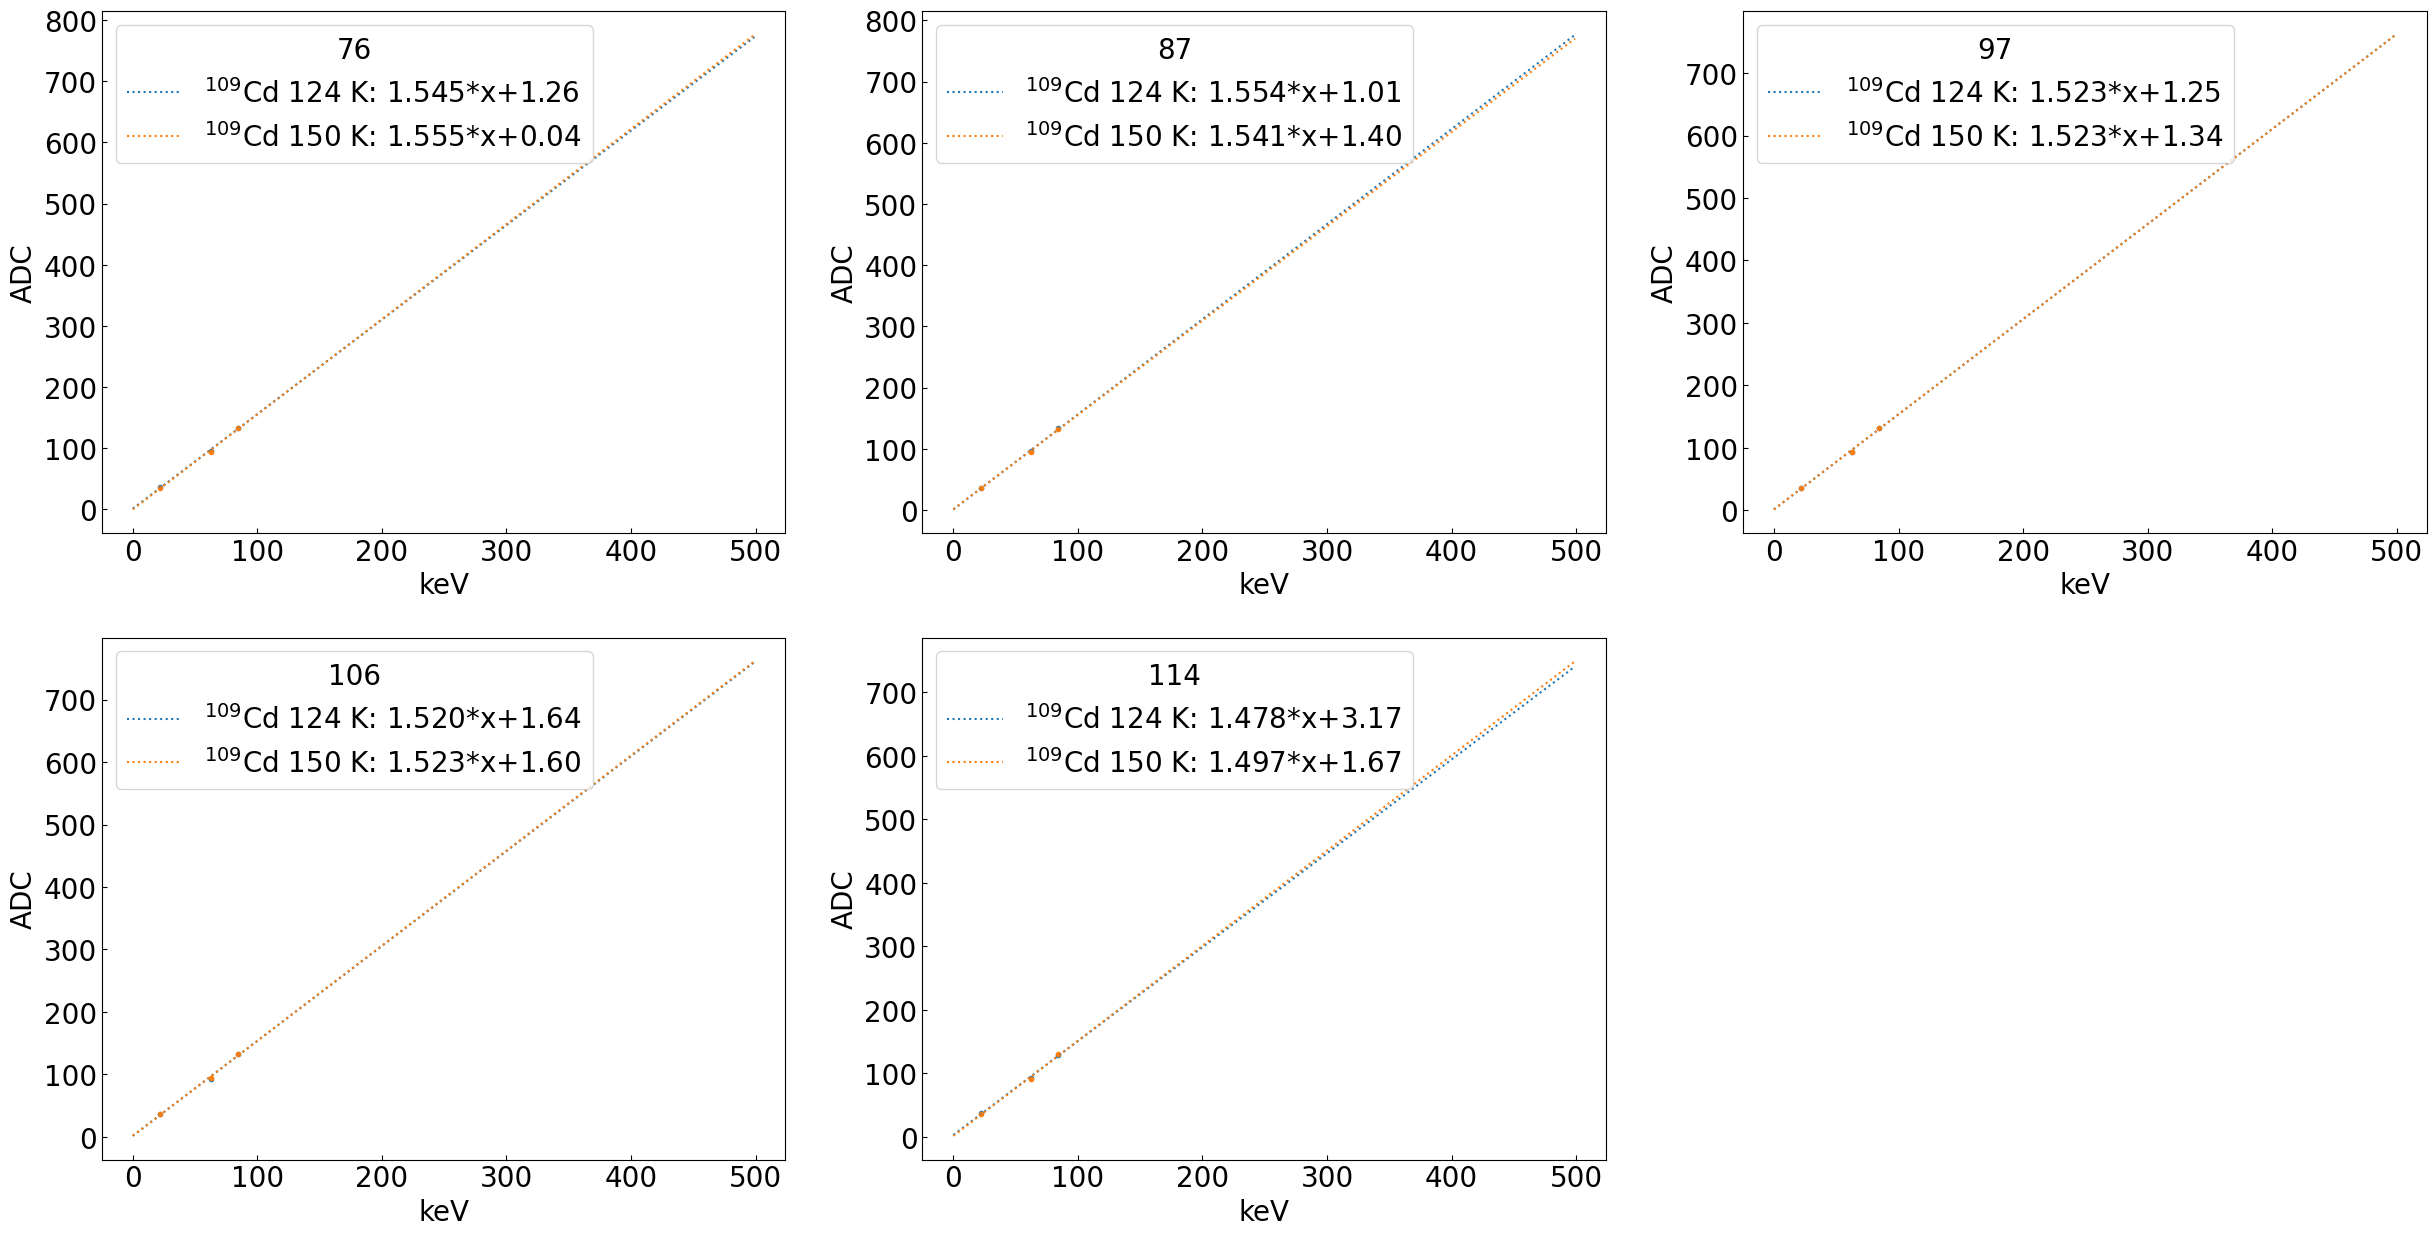

In [19]:
pix = [0,3,6,11,14]
# pix = [0]

nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)
labels = ['','124 K', '','','','','','150 K']
toADC_Cd = []
cnt = 0
indx = 0
ADCdata_Cd_test124 = []
ADCdata_Cd_test150 = []

ADCdata_Cd_test124_err = []
ADCdata_Cd_test150_err = []
for i in pix:
    Cd = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs_Cd)):

        if j==1 or j==7:
            if len(ADC_data_Cd[j][i])<=1:
                Cd.append([0])
                pass
            if len(ADC_data_Cd[j][i])<4:
                ax.set_ylabel('ADC',size=20)
                ax.set_xlabel('keV',size=20)

                a, b = np.polyfit(eV_points_Cd[0:len(ADC_data_Cd[j][i])],ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],deg=1)
                ax.scatter(eV_points_Cd[0:len(ADC_data_Cd[j][i])],ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],marker = '.')

                Cd.append([a,b])
#                 print(a,b)
                ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{109}$Cd %s: %.3f*x+%.2f'%(labels[j],a,b))
                ax.legend(loc="upper left",fontsize=20,title = '%d'%pixel[indx],title_fontsize = 20)
        if j==7:
            ADCdata_Cd_test124.append(ADC_data_Cd[j][i])
            ADCdata_Cd_test124_err.append(ADC_error_Cd[j][i])
        if j==1:
            ADCdata_Cd_test150.append(ADC_data_Cd[j][i])
            ADCdata_Cd_test150_err.append(ADC_error_Cd[j][i])
    toADC_Cd.append(Cd)
    indx+=1
plt.show()

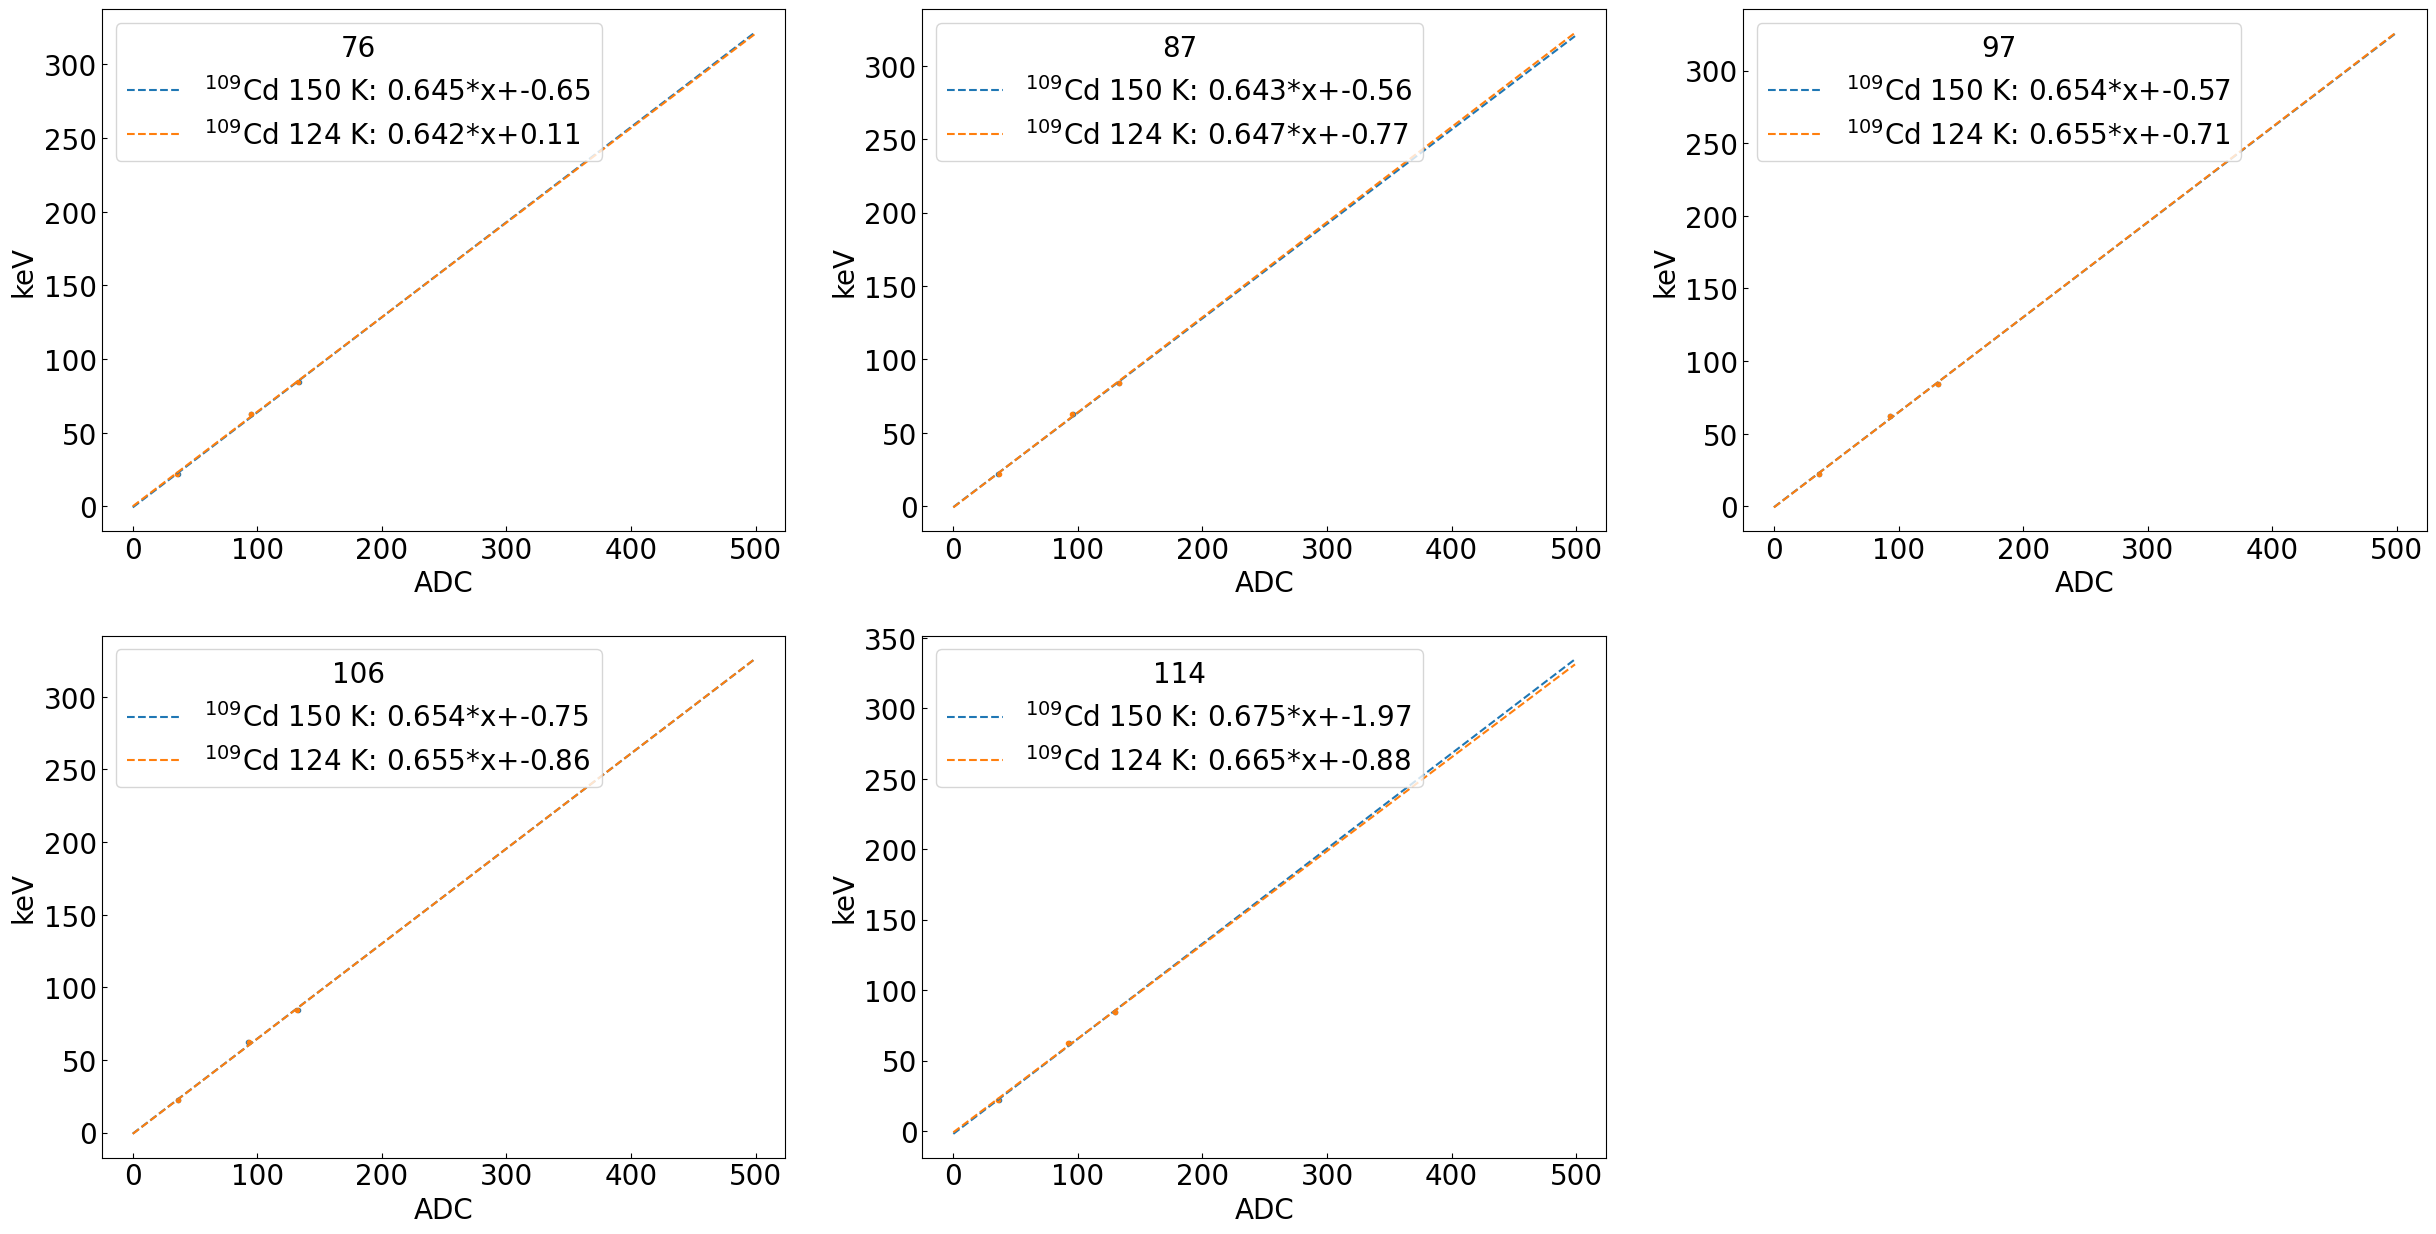

In [20]:
pix = [0,3,6,11,14]
# pix = [0]

nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)
labels = ['','150 K', '','','','','','124 K']
toeV_Cd = []
cnt = 0
indx = 0
# ADCdata_Cd_test = []
for i in pix:
    Cd = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs_Cd)):

        if j==1 or j==7:
            if len(ADC_data_Cd[j][i])<=1:
                Cd.append([0])
                pass
            if len(ADC_data_Cd[j][i])<4:
                ax.set_ylabel('keV',size=20)
                ax.set_xlabel('ADC',size=20)

                a, b = np.polyfit(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],deg=1)
                ax.scatter(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],marker = '.')

                Cd.append([a,b])
#                 print(a,b)
                ax.plot(x,calibration_lin(x,a,b),linestyle = '--',label = r'$^{109}$Cd %s: %.3f*x+%.2f'%(labels[j],a,b))
                ax.legend(loc="upper left",fontsize=20,title = '%d'%pixel[indx],title_fontsize = 20)
#                 ADCdata_Cd_test.append(ADC_data_Cd[j][i])
    toeV_Cd.append(Cd)
    indx+=1
plt.show()

In [51]:
dfCd = {}
for i in range(len(toADC_Cd)):
    dfCd[i] = {'lin':toADC_Cd[i][0][0],'const':toADC_Cd[i][0][1]}

In [52]:
toADC_Cd

[[[np.float64(1.5453400745874775), np.float64(1.259501351953223)],
  [np.float64(1.5550234384562218), np.float64(0.03763428369877371)]],
 [[np.float64(1.5537158195254148), np.float64(1.0073662364329663)],
  [np.float64(1.5407160809888711), np.float64(1.3982300830732608)]],
 [[np.float64(1.523283498341184), np.float64(1.2525926727327423)],
  [np.float64(1.5227792815105048), np.float64(1.3442728411757798)]],
 [[np.float64(1.5197319353687868), np.float64(1.6393640962764098)],
  [np.float64(1.5225973794569287), np.float64(1.5982633516899527)]],
 [[np.float64(1.4778354554459432), np.float64(3.1728114331878716)],
  [np.float64(1.4972667025074682), np.float64(1.6739865258057565)]]]

In [21]:
dx = (300-90)
dy = (3.67-3.81)
dT = 150.824458-124.2852325
dkeV = np.abs((dy/dx)*dT)

In [22]:
dkeV

np.float64(0.017692817000000007)

In [23]:
love = dT*0.000172

In [24]:
Cd_converted124 = []
Cd_converted124_err = []
for i in range(len(toeV_Cd)):
    Cd_converted124.append(convert(ADCdata_Cd_test124[i],[toeV_Cd[i][1]])[0].tolist())
    Cd_converted124_err.append(convert(np.array(ADCdata_Cd_test124_err[i]),[toeV_Cd[i][1]])[0].tolist())
    
Cd_converted150 = []
Cd_converted150_err = []
for i in range(len(toeV_Cd)):
    Cd_converted150.append(convert(ADCdata_Cd_test150[i],[toeV_Cd[i][0]])[0].tolist())
    Cd_converted150_err.append(convert(np.array(ADCdata_Cd_test150_err[i]),[toeV_Cd[i][0]])[0].tolist())

In [29]:
toeV_Cd

[[[np.float64(0.6452004553810753), np.float64(-0.6468265141866726)],
  [np.float64(0.6415308643207207), np.float64(0.11118831067816194)]],
 [[np.float64(0.6426258615819529), np.float64(-0.5605686509468093)],
  [np.float64(0.647496362509786), np.float64(-0.770722123574359)]],
 [[np.float64(0.6536038841519386), np.float64(-0.5724036390672003)],
  [np.float64(0.6546898587895488), np.float64(-0.7083132718516956)]],
 [[np.float64(0.6542384567758954), np.float64(-0.7498662368493401)],
  [np.float64(0.6545919676315666), np.float64(-0.85935007864297)]],
 [[np.float64(0.67455993259745), np.float64(-1.9651302731226767)],
  [np.float64(0.6651271824471605), np.float64(-0.8811198952011788)]]]

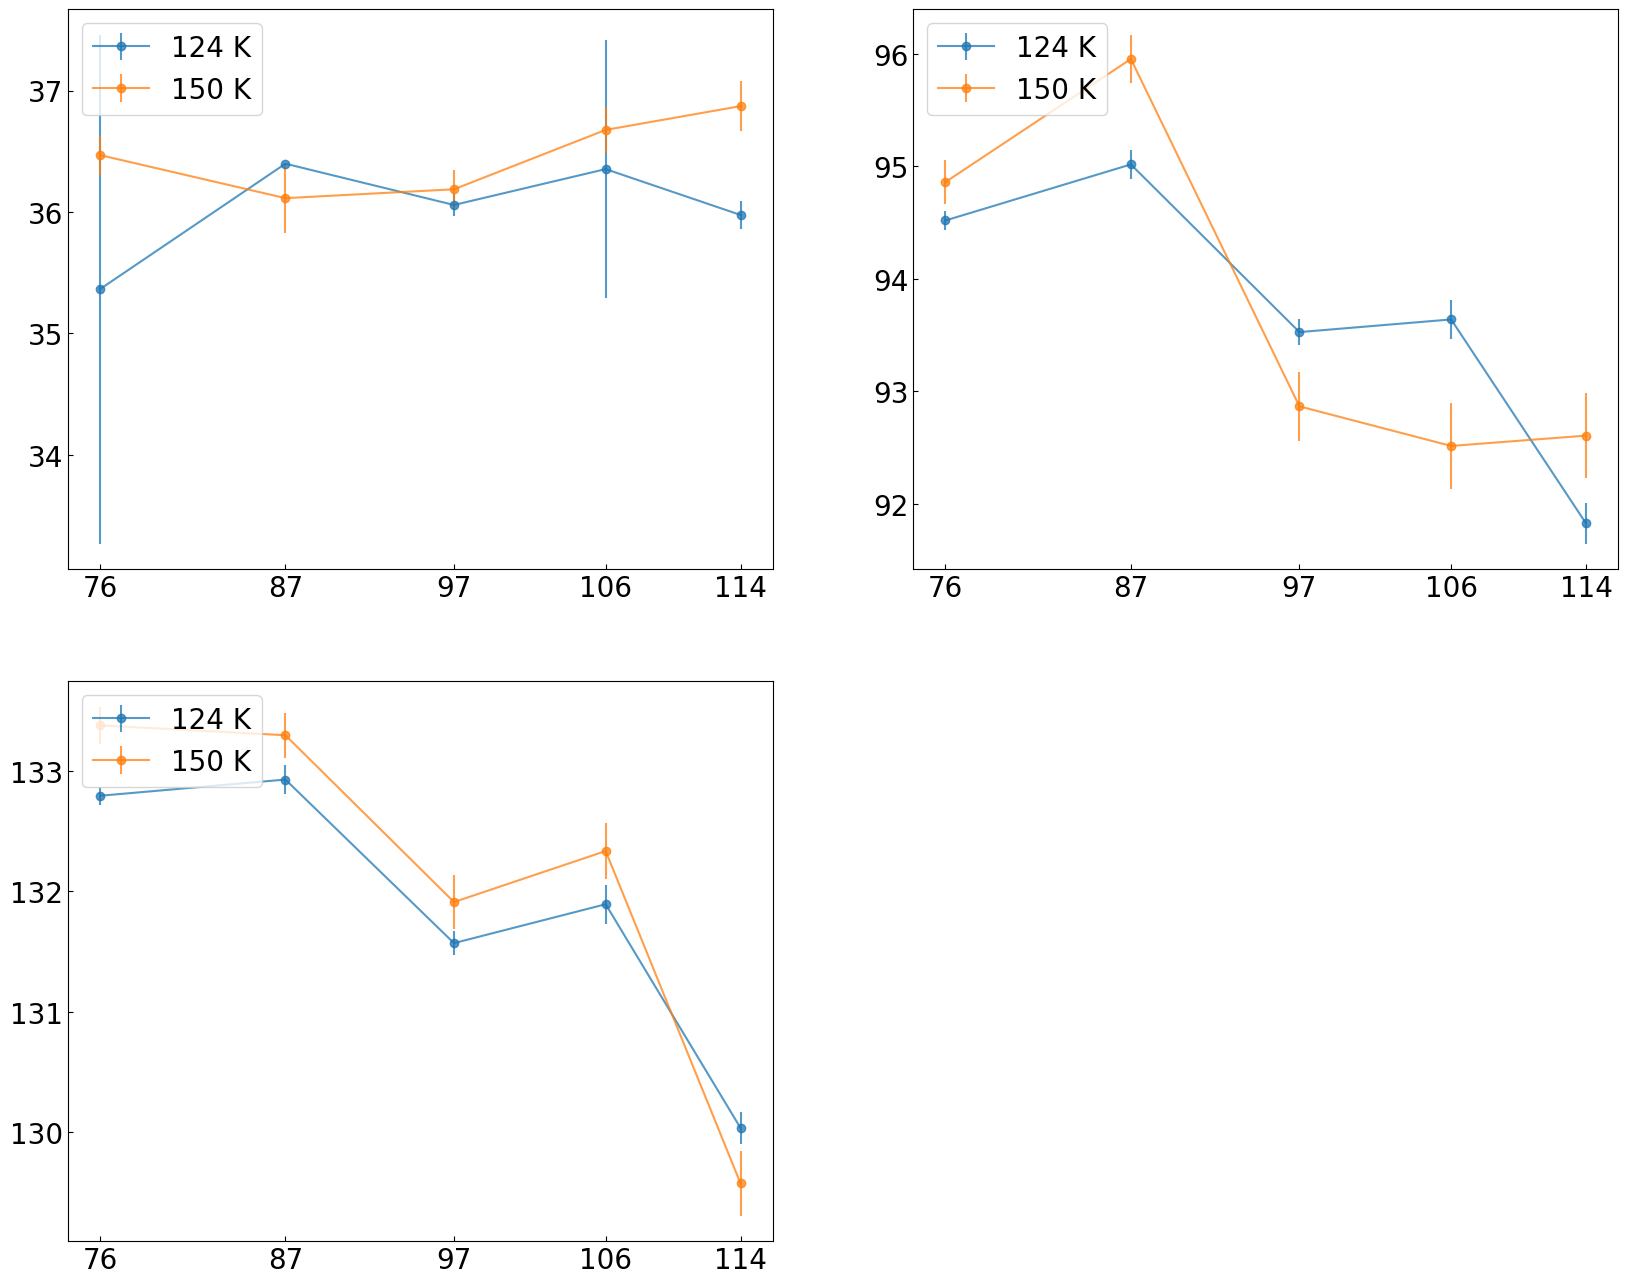

In [25]:
nrows,ncols=2,2
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
for i in range(3):
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

    ax.errorbar(pixel,np.array(ADCdata_Cd_test124)[:,i],yerr = np.abs(np.array(ADCdata_Cd_test124_err))[:,i],label = '124 K',marker = 'o',alpha = 0.75)
    ax.errorbar(pixel,np.array(ADCdata_Cd_test150)[:,i],yerr = np.abs(np.array(ADCdata_Cd_test150_err))[:,i],label = '150 K',marker = 'o',alpha = 0.75)
#     ax.axhline(eV_points_Cd[i],color = 'C2')
    ax.set_xticks(pixel)
    ax.legend(loc = 'upper left',fontsize=20)
plt.show()

In [28]:
ADCdata_Cd_test124_err,Cd_converted124_err

([[2.096112787995913, np.float64(0.0826354141394596), 0.07519506167295828],
  [inf, np.float64(0.12540094337763175), 0.11837873204254216],
  [0.0940643545132799, np.float64(0.11472723477884403), 0.10183762418674151],
  [np.float64(1.0649199359576287),
   np.float64(0.17682258255098526),
   0.16175821802925502],
  [np.float64(0.11220123083103857),
   np.float64(0.18132705396603122),
   0.13018853828198548]],
 [[1.4559093592748957, 0.16420147933455015, 0.15942826358586476],
  [inf, -0.6895254688820468, -0.6940723251782923],
  [-0.6467302928782663, -0.6332025147150188, -0.6416412120534146],
  [-0.1622620423943839, -0.7436034364092254, -0.753464448422624],
  [-0.8064918066714266, -0.7605143426953083, -0.7945279595467676]])

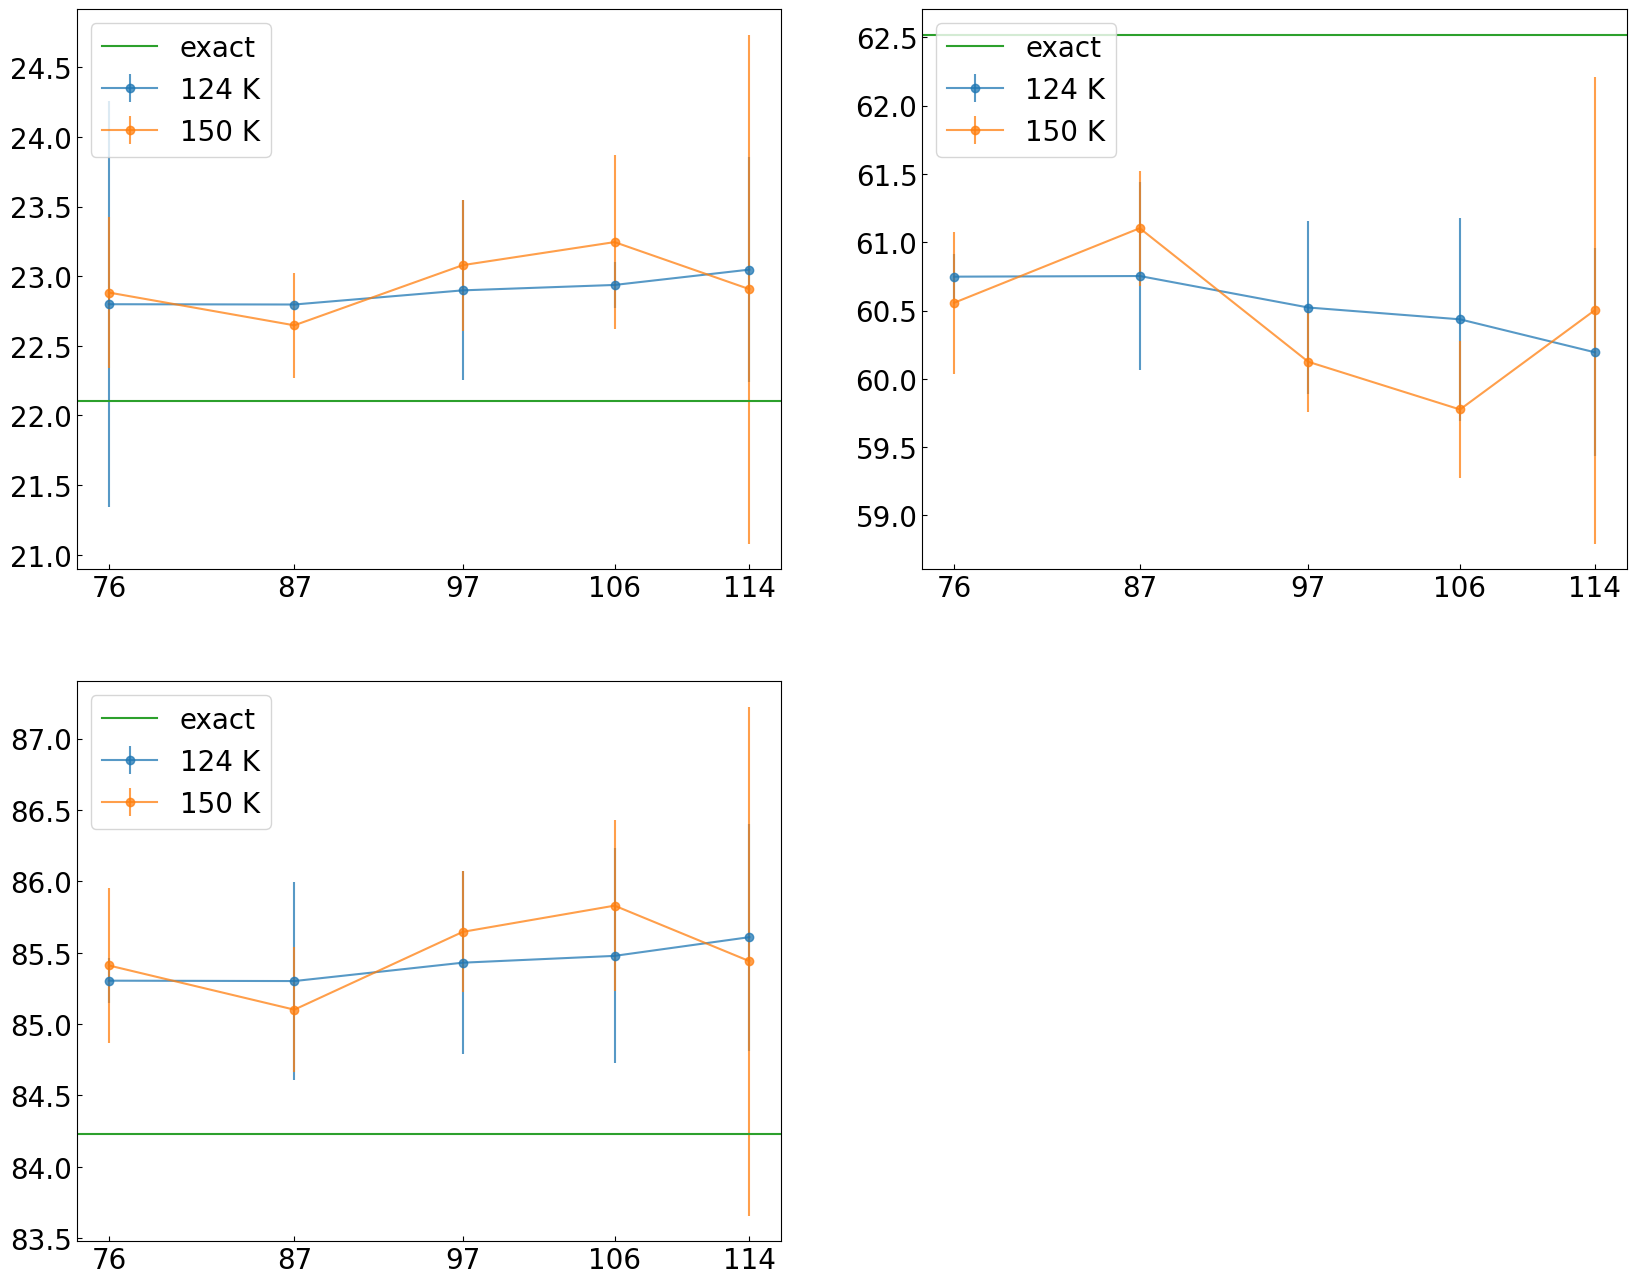

In [26]:
nrows,ncols=2,2
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
for i in range(3):
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)

    ax.errorbar(pixel,np.array(Cd_converted124)[:,i],yerr = np.abs(np.array(Cd_converted124_err))[:,i],label = '124 K',marker = 'o',alpha = 0.75)
    ax.errorbar(pixel,np.array(Cd_converted150)[:,i],yerr = np.abs(np.array(Cd_converted150_err))[:,i],label = '150 K',marker = 'o',alpha = 0.75)
    ax.axhline(eV_points_Cd[i],color = 'C2',label = 'exact')
    ax.set_xticks(pixel)
    ax.legend(loc = 'upper left',fontsize=20)
plt.show()

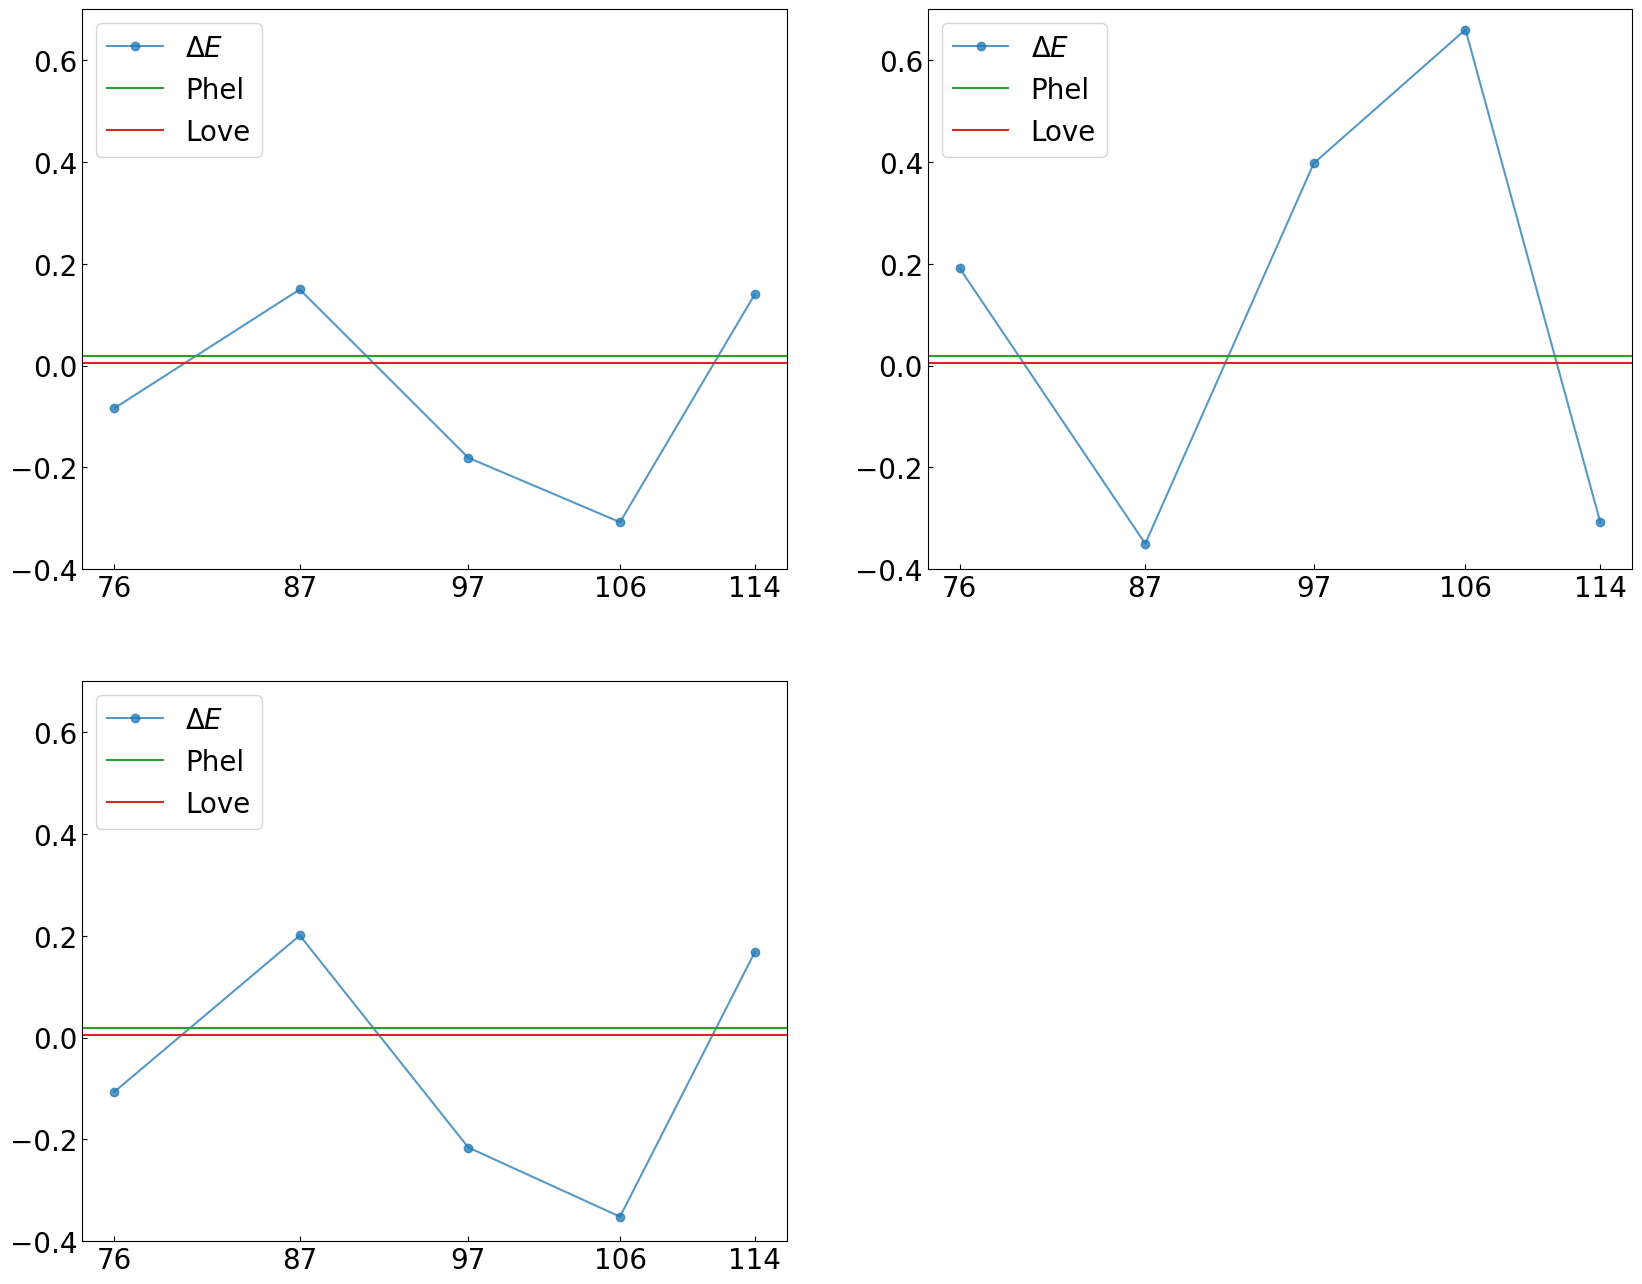

In [245]:
nrows,ncols=2,2
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
for i in range(3):
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    
    ax.plot(pixel,np.array(Cd_converted124)[:,i]-np.array(Cd_converted150)[:,i],marker = 'o',alpha = 0.75,label = r'$\Delta E$')
    ax.axhline(dkeV,color = 'C2',label = 'Phel')
    ax.axhline(love,color = 'C3',label = 'Love')
    ax.set_xticks(pixel)
    ax.legend(loc = 'upper left',fontsize=20)
    ax.set_ylim(-0.4,0.7)
plt.show()

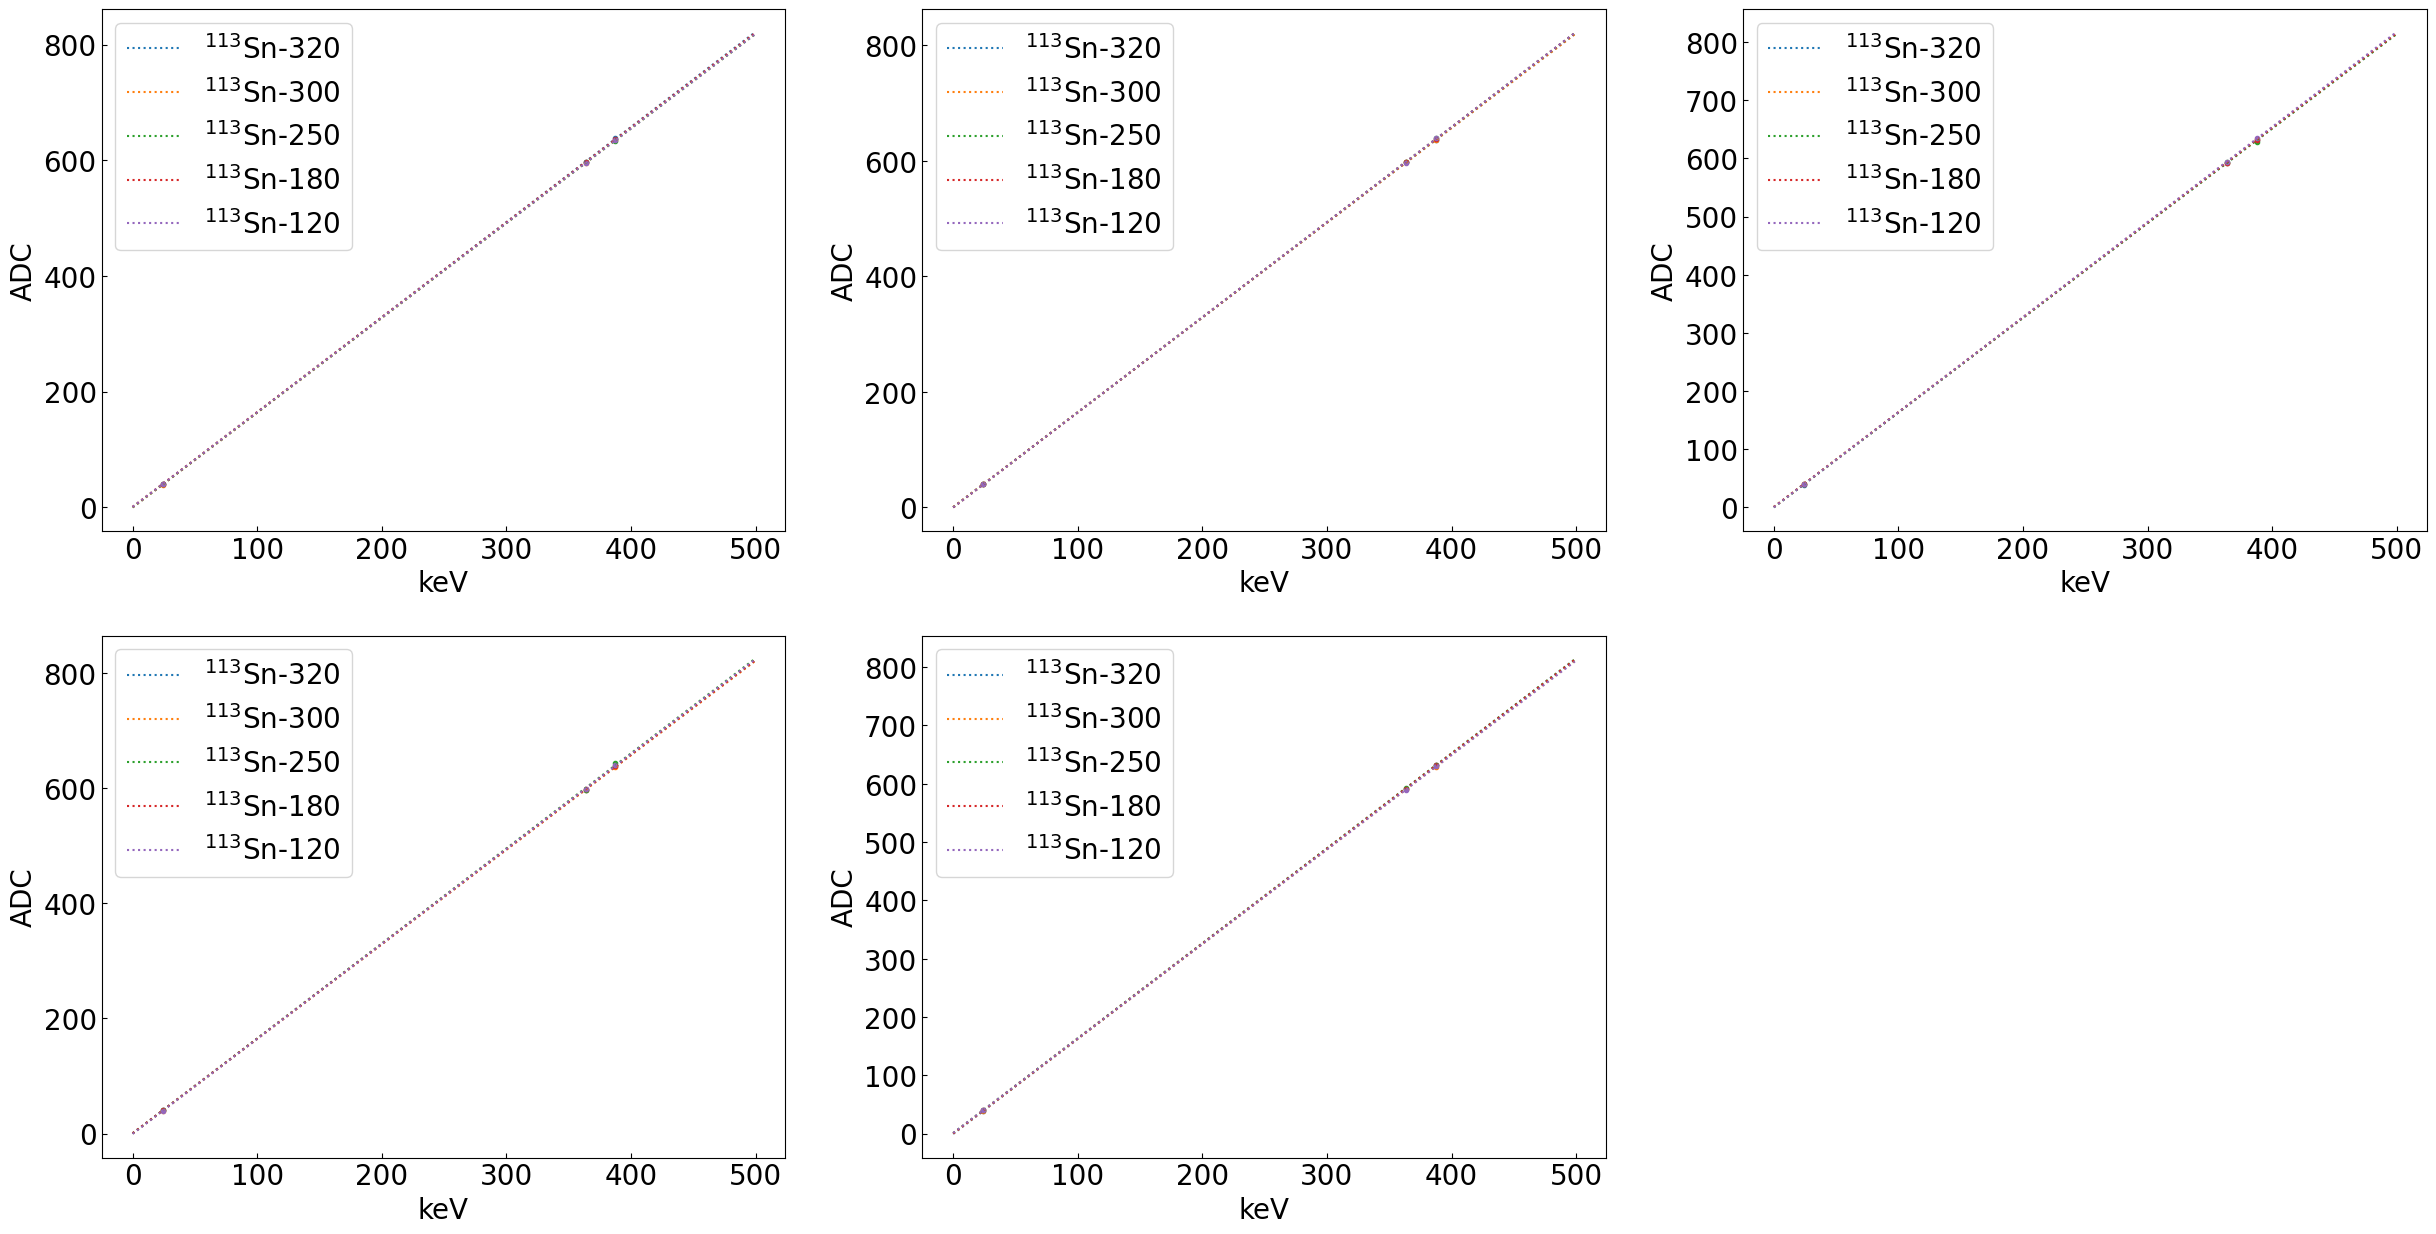

In [212]:
pix = [0,3,6,11,14]
# pix = [0]

nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)

toADC_Sn = []
cnt = 0
for i in pix:
    Sn = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs)):
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn[j][i])<4:
            ax.set_ylabel('ADC',size=20)
            ax.set_xlabel('keV',size=20)
            
            a, b = np.polyfit(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],deg=1)
            ax.scatter(eV_points_Sn[0:len(ADC_data_Sn[j][i])],ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],marker = '.')
            
            Sn.append([a,b])
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn%d'%bias[j])
            ax.legend(loc="upper left",prop={'size':20})
    toADC_Sn.append(Sn)

plt.show()

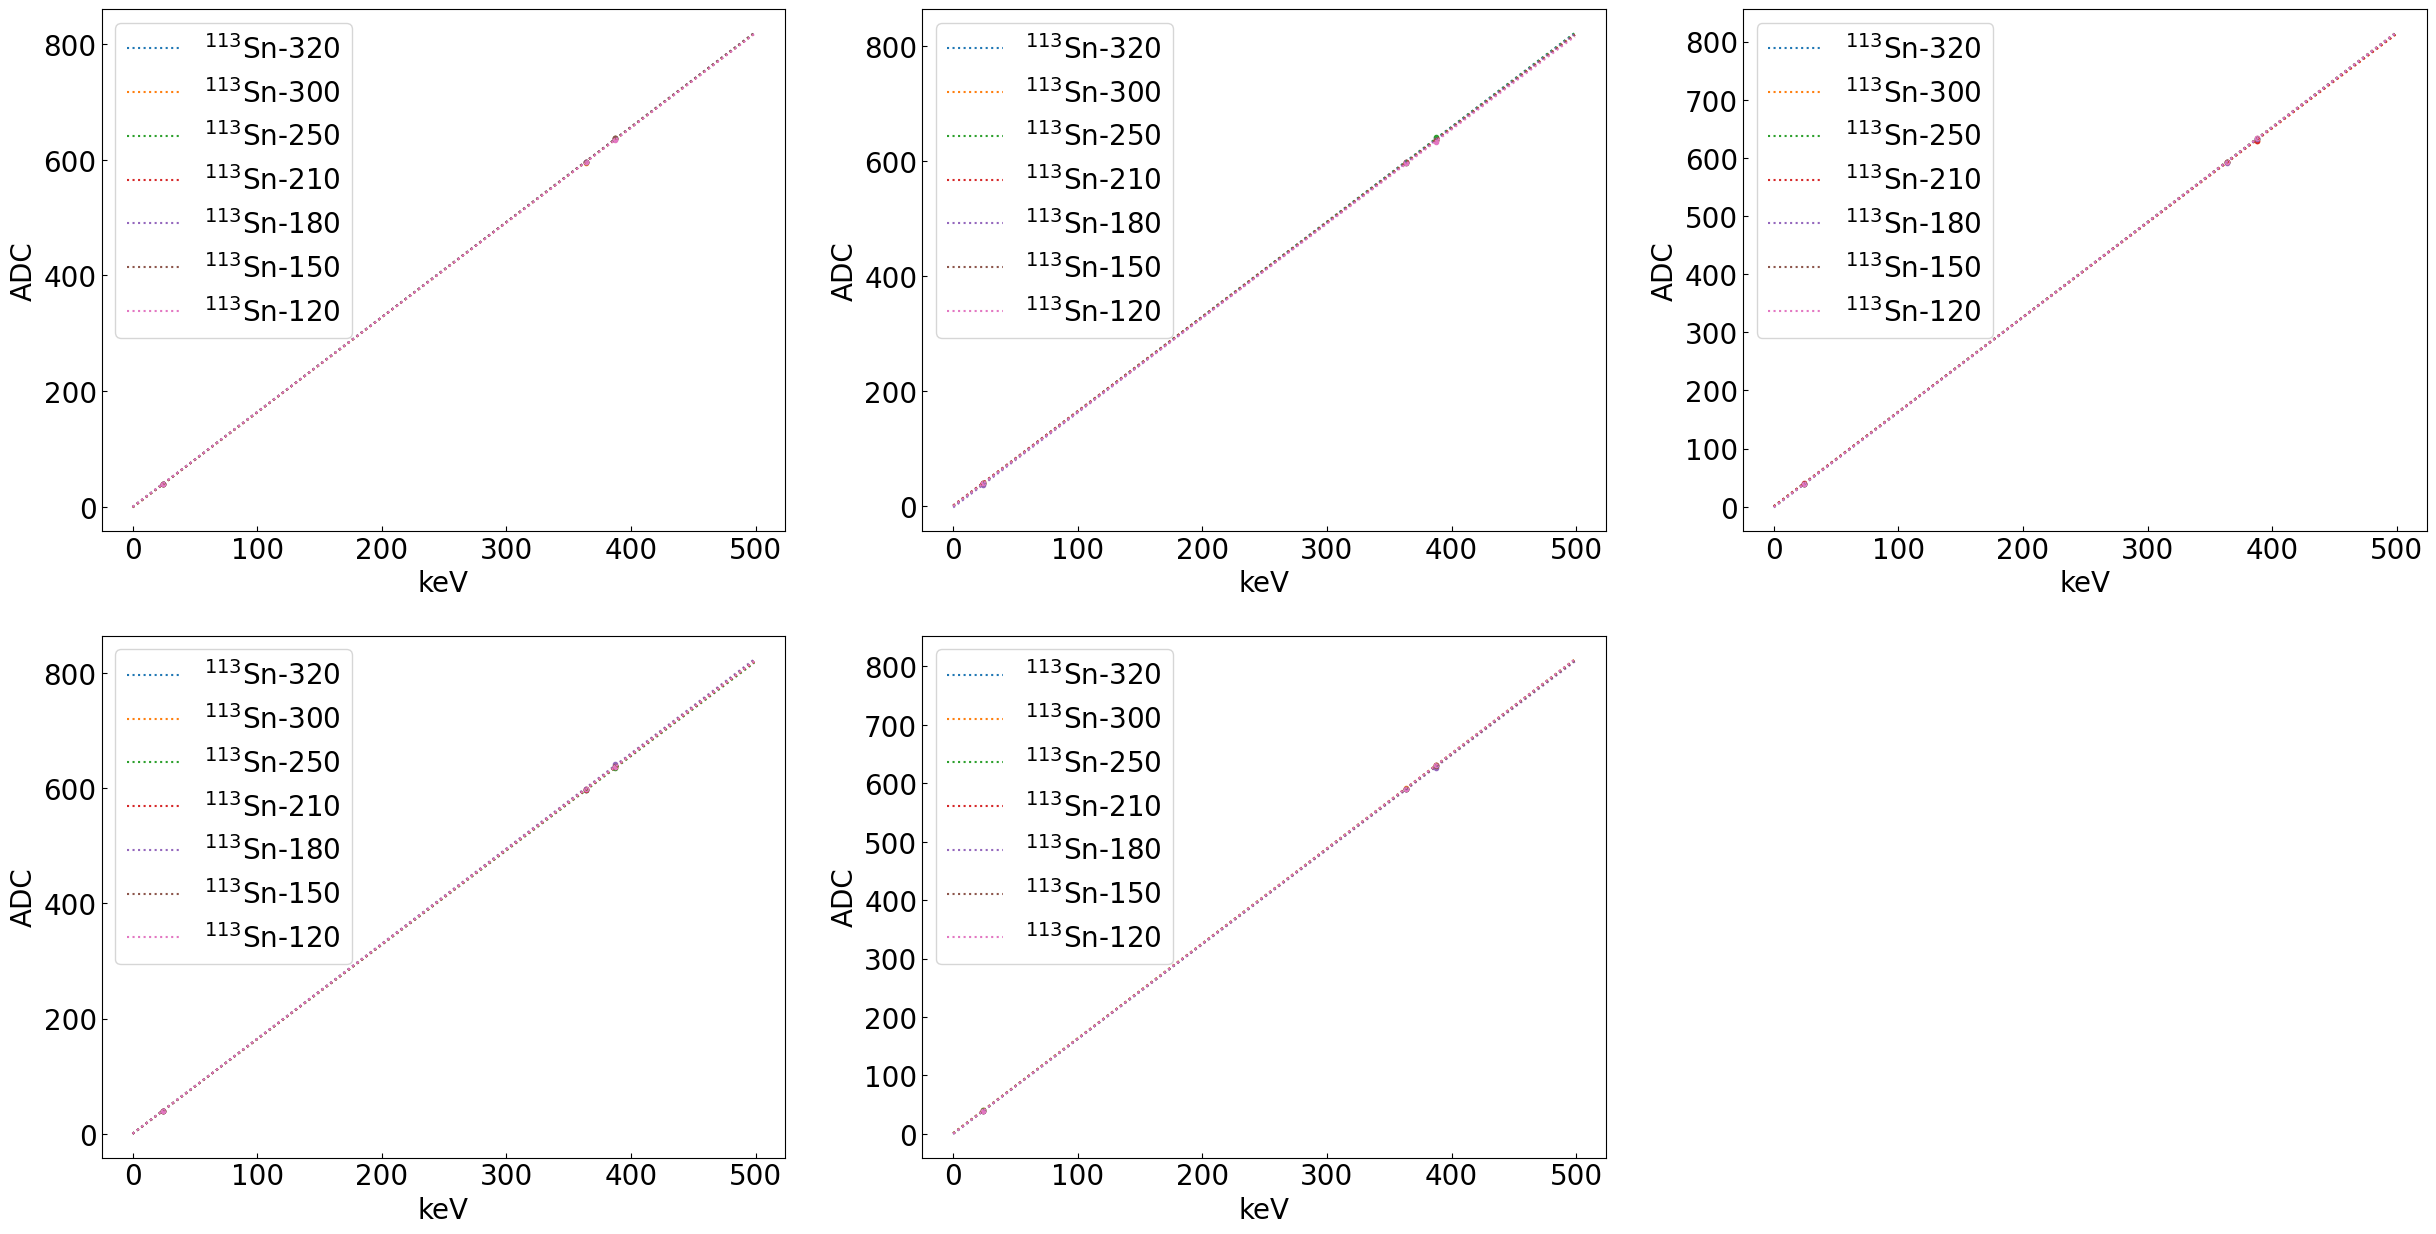

In [16]:
pix = [0,3,6,11,14]
# pix = [0]

nrows,ncols=10,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,500)

toADC_Sn2 = []
cnt = 0
for i in pix:
    Sn = []
    cnt +=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    for j in range(len(runs2)):
        if len(ADC_data_Sn2[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn2[j][i])<4:
            ax.set_ylabel('ADC',size=20)
            ax.set_xlabel('keV',size=20)
            
            a, b = np.polyfit(eV_points_Sn[0:len(ADC_data_Sn2[j][i])],ADC_data_Sn2[j][i][0:len(ADC_data_Sn2[j][i])],deg=1)
            ax.scatter(eV_points_Sn[0:len(ADC_data_Sn2[j][i])],ADC_data_Sn2[j][i][0:len(ADC_data_Sn2[j][i])],marker = '.')
            
            Sn.append([a,b])
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn%d'%bias2[j])
            ax.legend(loc="upper left",prop={'size':20})
    toADC_Sn2.append(Sn)

plt.show()

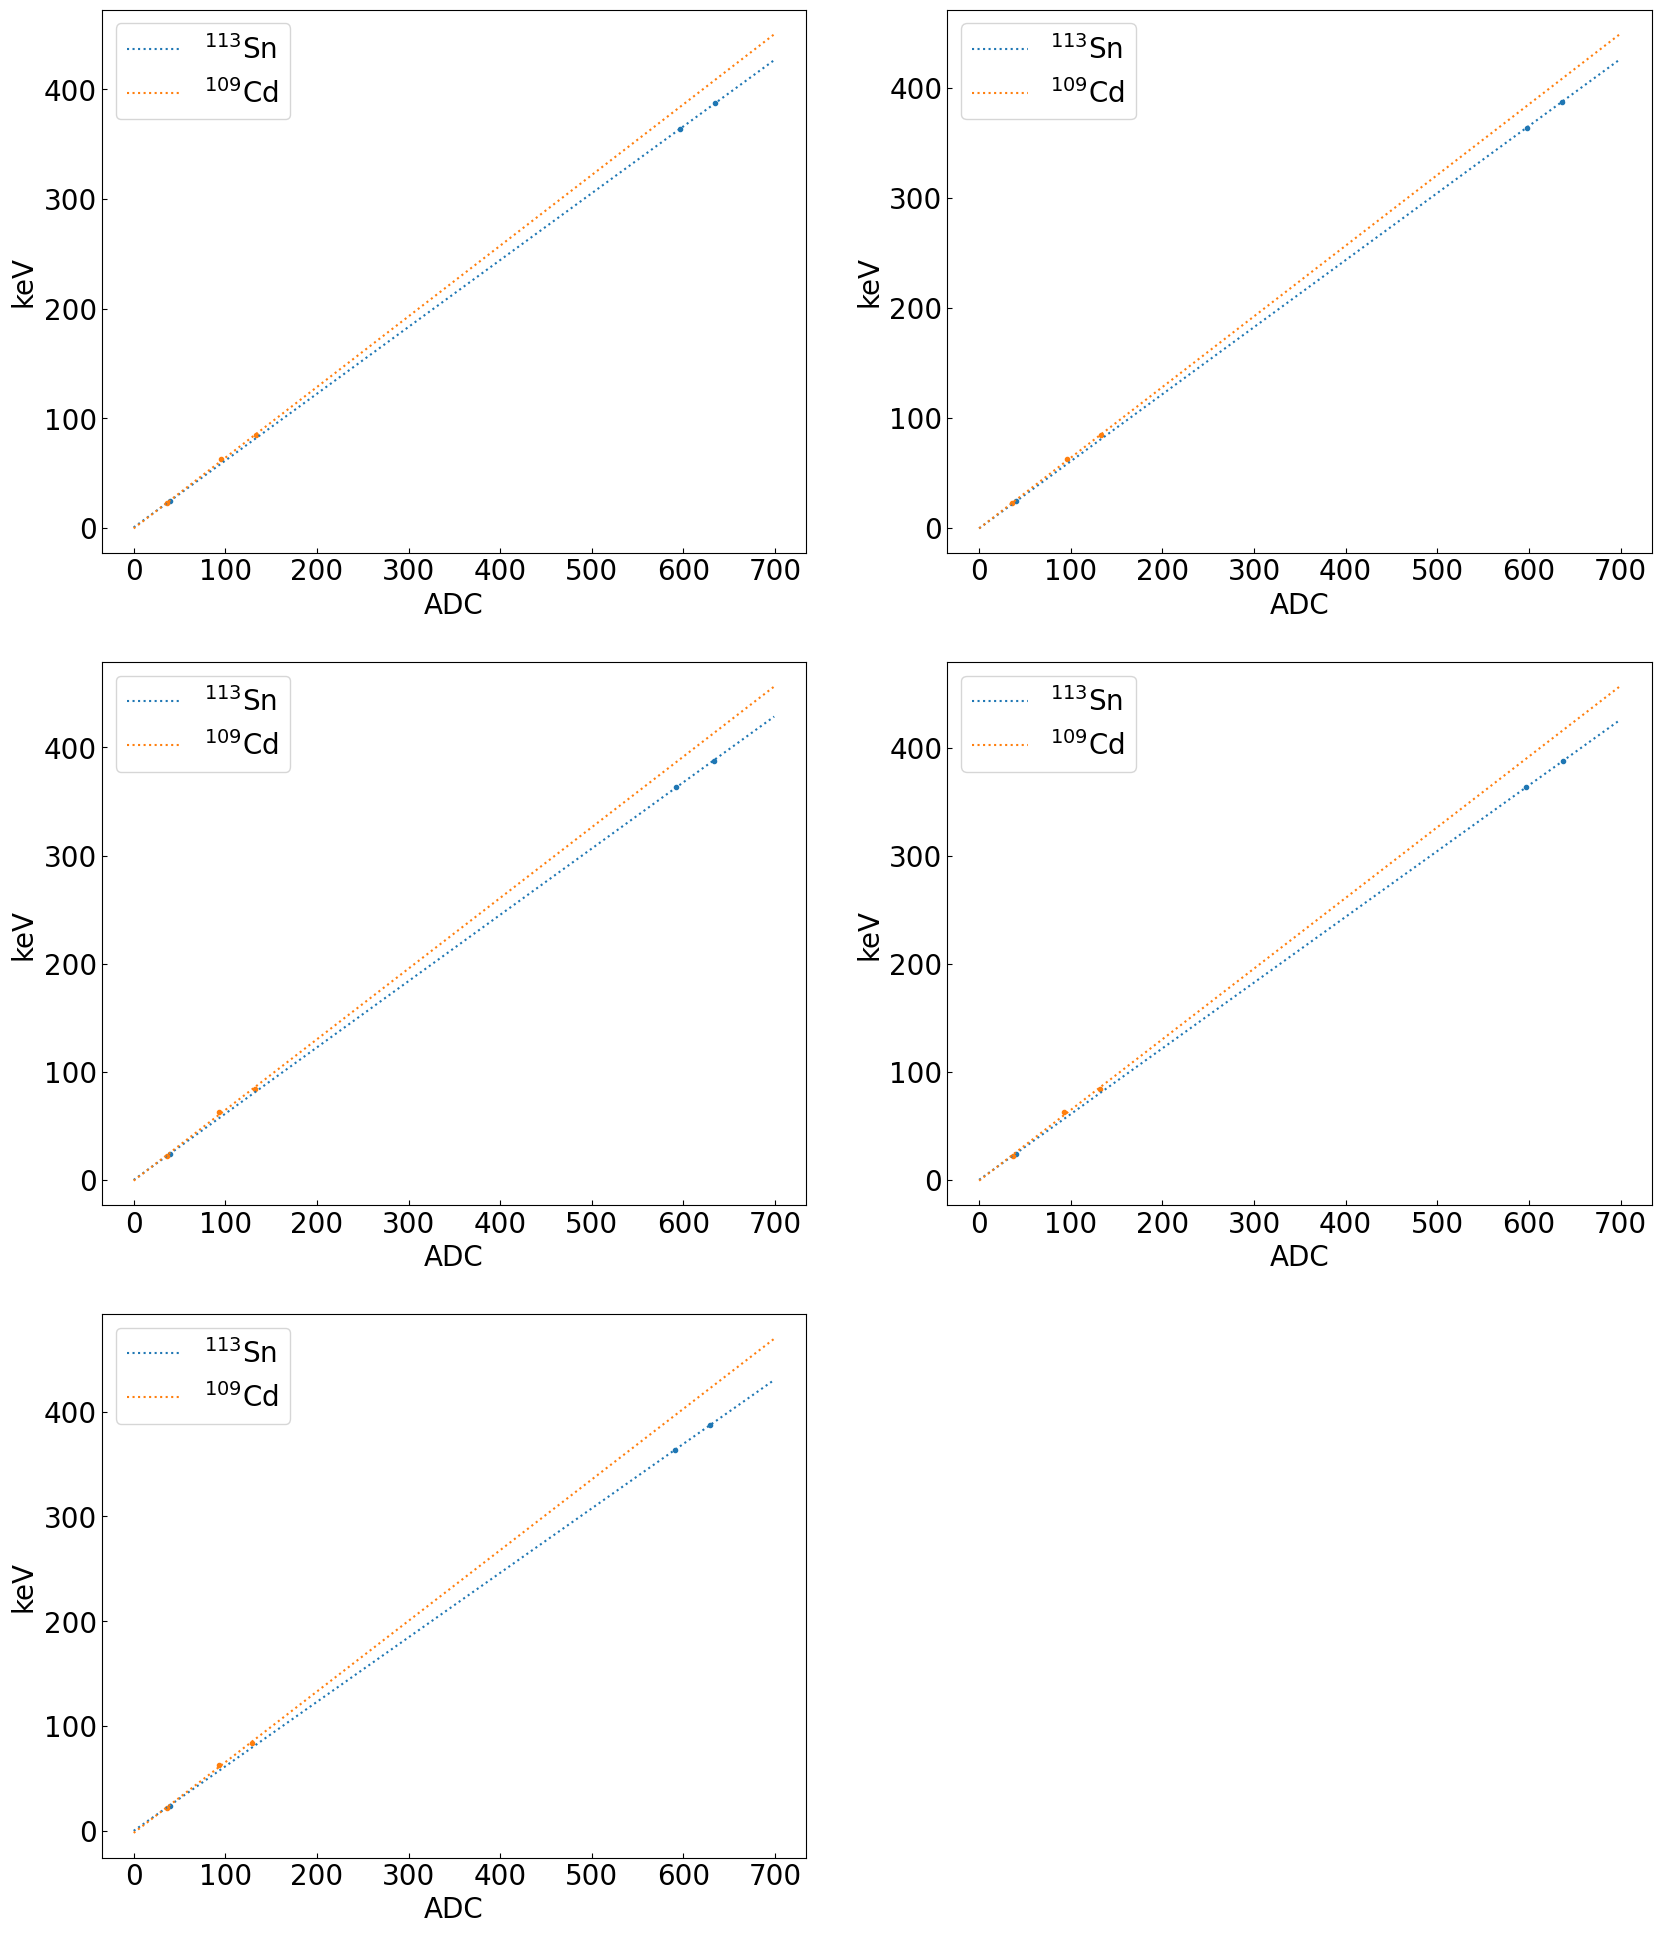

In [17]:
nrows,ncols=3,2
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(0,700)

tokeV_Sn = []
tokeV_Cd = []
cnt = 0
for i in pix:
    Sn = []
    Cd = []
    for j in range(1):
        j += 1
        cnt +=1
        ax=py.subplot(nrows,ncols,cnt)
        ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
        if len(ADC_data_Sn[j][i])<=1:
            Sn.append([0])
            pass
        if len(ADC_data_Sn[j][i])<4:
            ax.set_ylabel('keV',size=20)
            ax.set_xlabel('ADC',size=20)
            
            a, b = np.polyfit(ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],eV_points_Sn[0:len(ADC_data_Sn[j][i])],deg=1)
            ax.scatter(ADC_data_Sn[j][i][0:len(ADC_data_Sn[j][i])],eV_points_Sn[0:len(ADC_data_Sn[j][i])],marker = '.')
            
            Sn.append([a,b])
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{113}$Sn')
    
        if len(ADC_data_Cd[j][i])<=1:
            Cd.append([0])
            pass
        if len(ADC_data_Cd[j][i])<4:
            ax.set_ylabel('keV',size=20)
            ax.set_xlabel('ADC',size=20)
            
            a, b = np.polyfit(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],deg=1)
            
            ax.scatter(ADC_data_Cd[j][i][0:len(ADC_data_Cd[j][i])],eV_points_Cd[0:len(ADC_data_Cd[j][i])],marker = '.')
            
            Cd.append([a,b])
            
            ax.plot(x,calibration_lin(x,a,b),linestyle = ':',label = r'$^{109}$Cd')

        ax.legend(loc="upper left",prop={'size':20})
    tokeV_Sn.append(Sn)
    tokeV_Cd.append(Cd)

plt.show()

In [234]:
convert(eV_points_Cd[0],np.array(tokeV_Sn)[0])

[np.float64(13.73912924876803)]

array([0.6101513 , 0.25296502])

In [18]:
low350 = []
for i in range(len(pix)):
    low350.append(convert(350,toADC_Sn[i]))
    
low350_2 = []
for i in range(len(pix)):
    low350_2.append(convert(350,toADC_Sn2[i]))
    
low75_Cd = []
for i in range(len(pix)):
    low75_Cd.append(convert(75,toADC_Cd[i]))
    
high375 = []
for i in range(len(pix)):
    high375.append(convert(375,toADC_Sn[i]))
    
high375_2 = []
for i in range(len(pix)):
    high375_2.append(convert(375,toADC_Sn2[i]))

high95_Cd = []
for i in range(len(pix)):
    high95_Cd.append(convert(95,toADC_Cd[i]))
    
low300 = []
for i in range(len(pix)):
    low300.append(convert(300,toADC_Sn[i]))
    
low330 = []
for i in range(len(pix)):
    low330.append(convert(330,toADC_Sn[i]))
    
high395 = []
for i in range(len(pix)):
    high395.append(convert(395,toADC_Sn[i]))
    
low359 = []
for i in range(len(pix)):
    low359.append(convert(359,toADC_Sn[i]))
    
high369 = []
for i in range(len(pix)):
    high369.append(convert(369,toADC_Sn[i]))

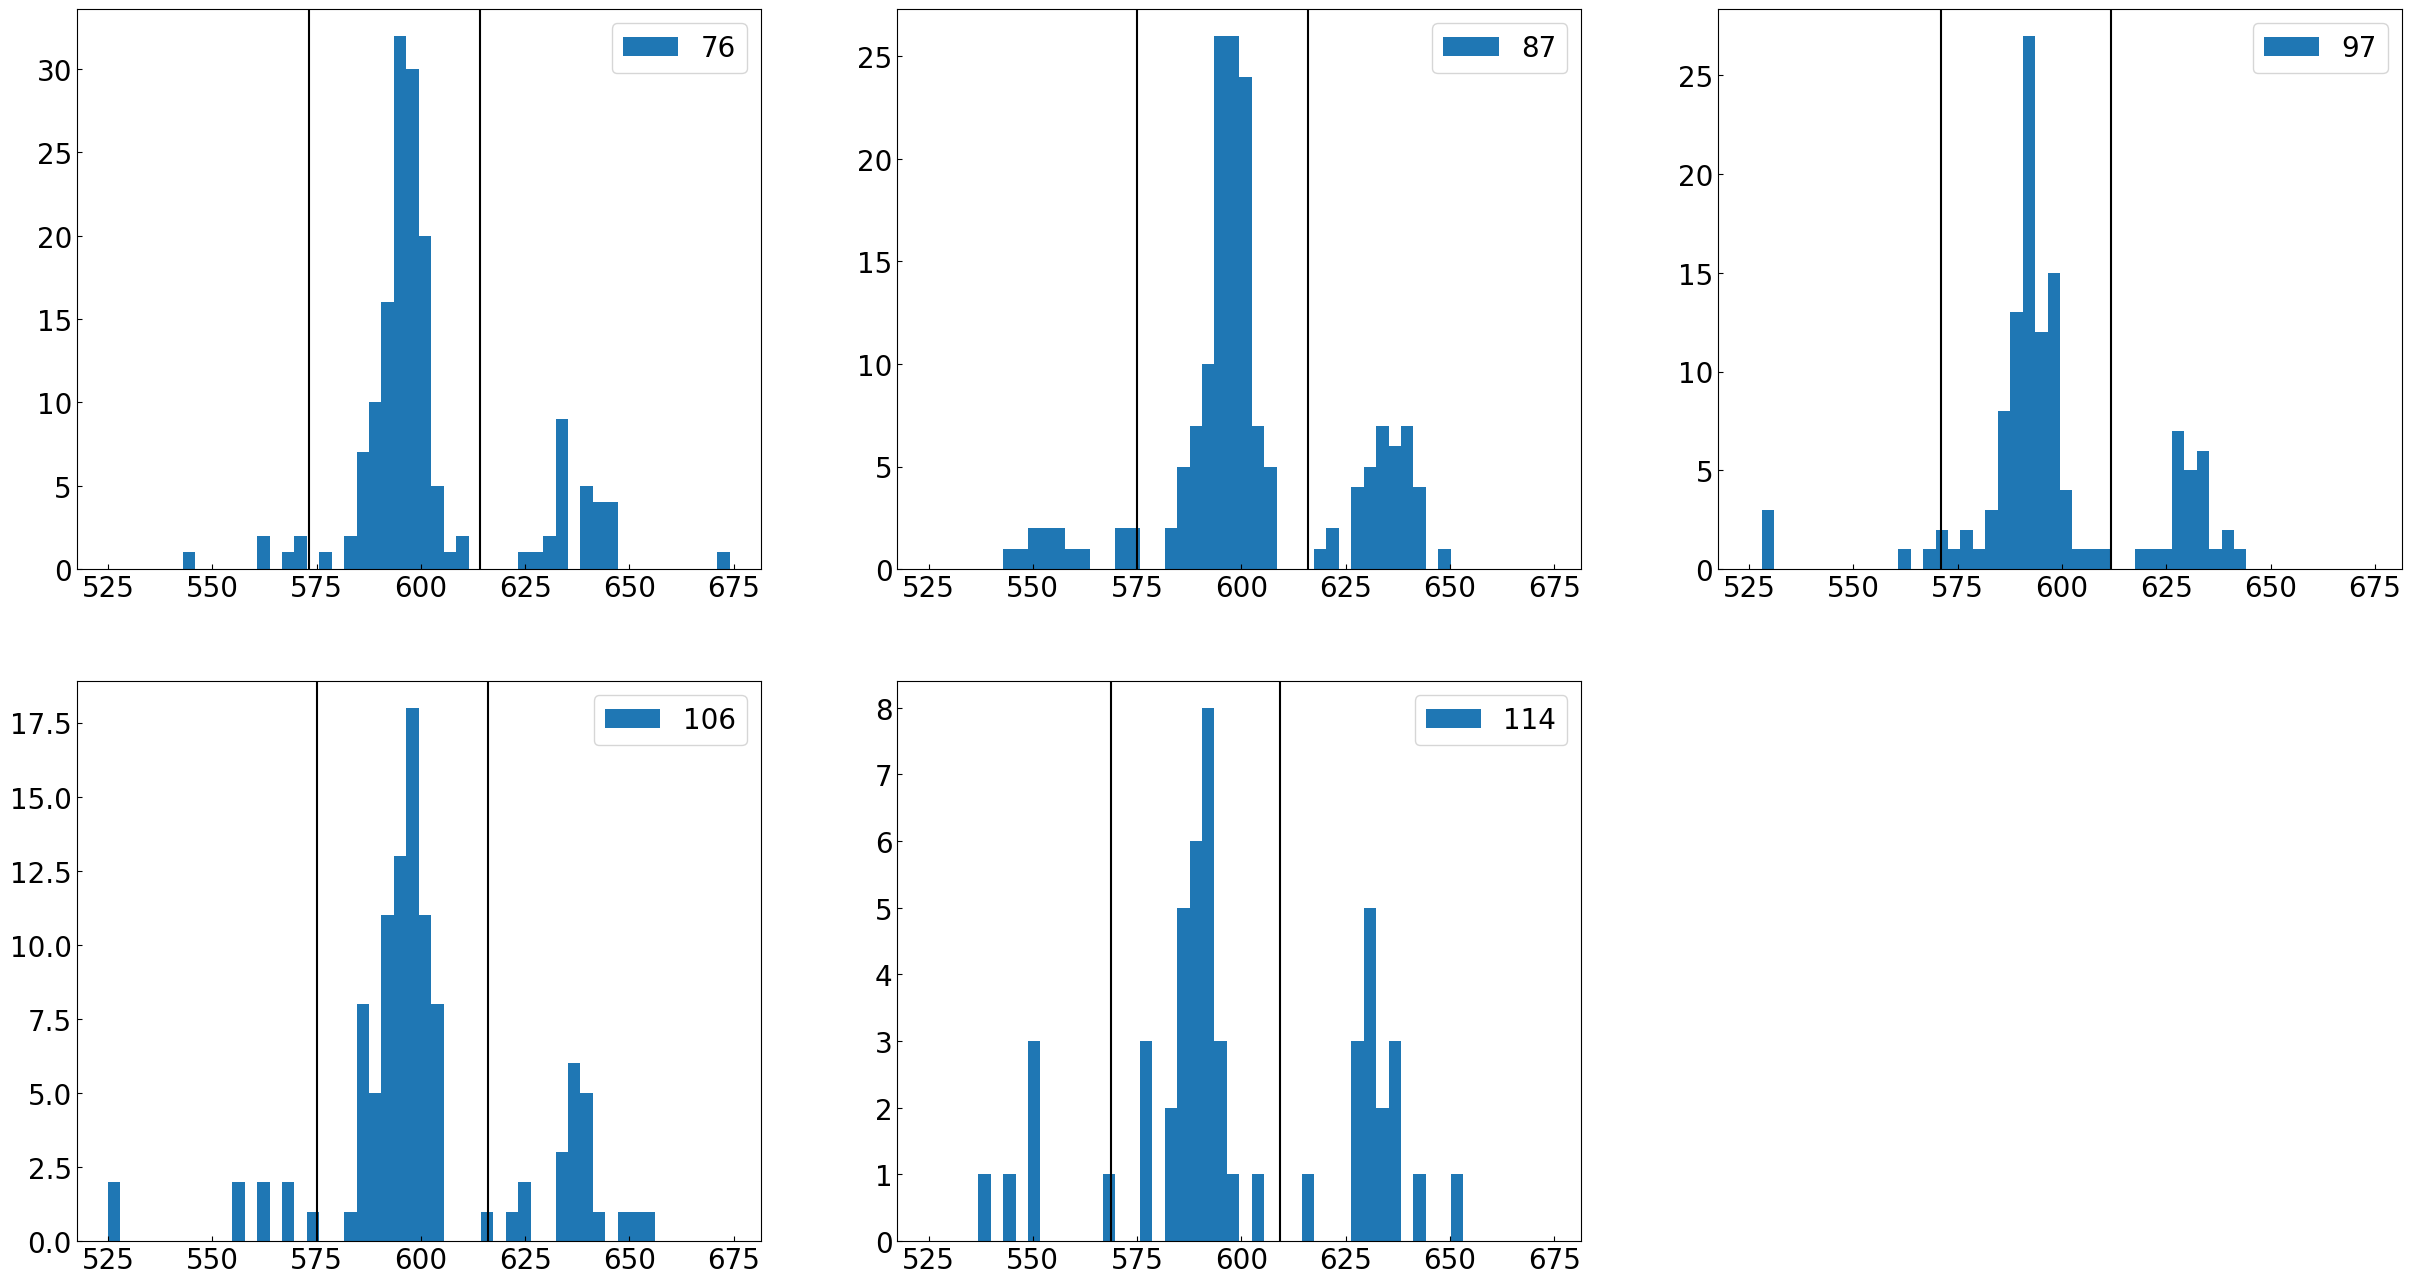

In [19]:
nrows,ncols=2,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(450,850)
cnt = 0
for i in range(len(pix)):
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.hist(x[75:225],weights = np.float64(dataAll[dataAll['pixel']==pixel[i]].iloc[0]['CE hist'].replace('[','').replace(']','').split())[75:225],bins=50,label = '%d'%pixel[i])
    ax.axvline(high375[i][1],color = 'black')
    ax.axvline(low350[i][1],color = 'black')
    ax.legend(prop={'size':20})

plt.show()

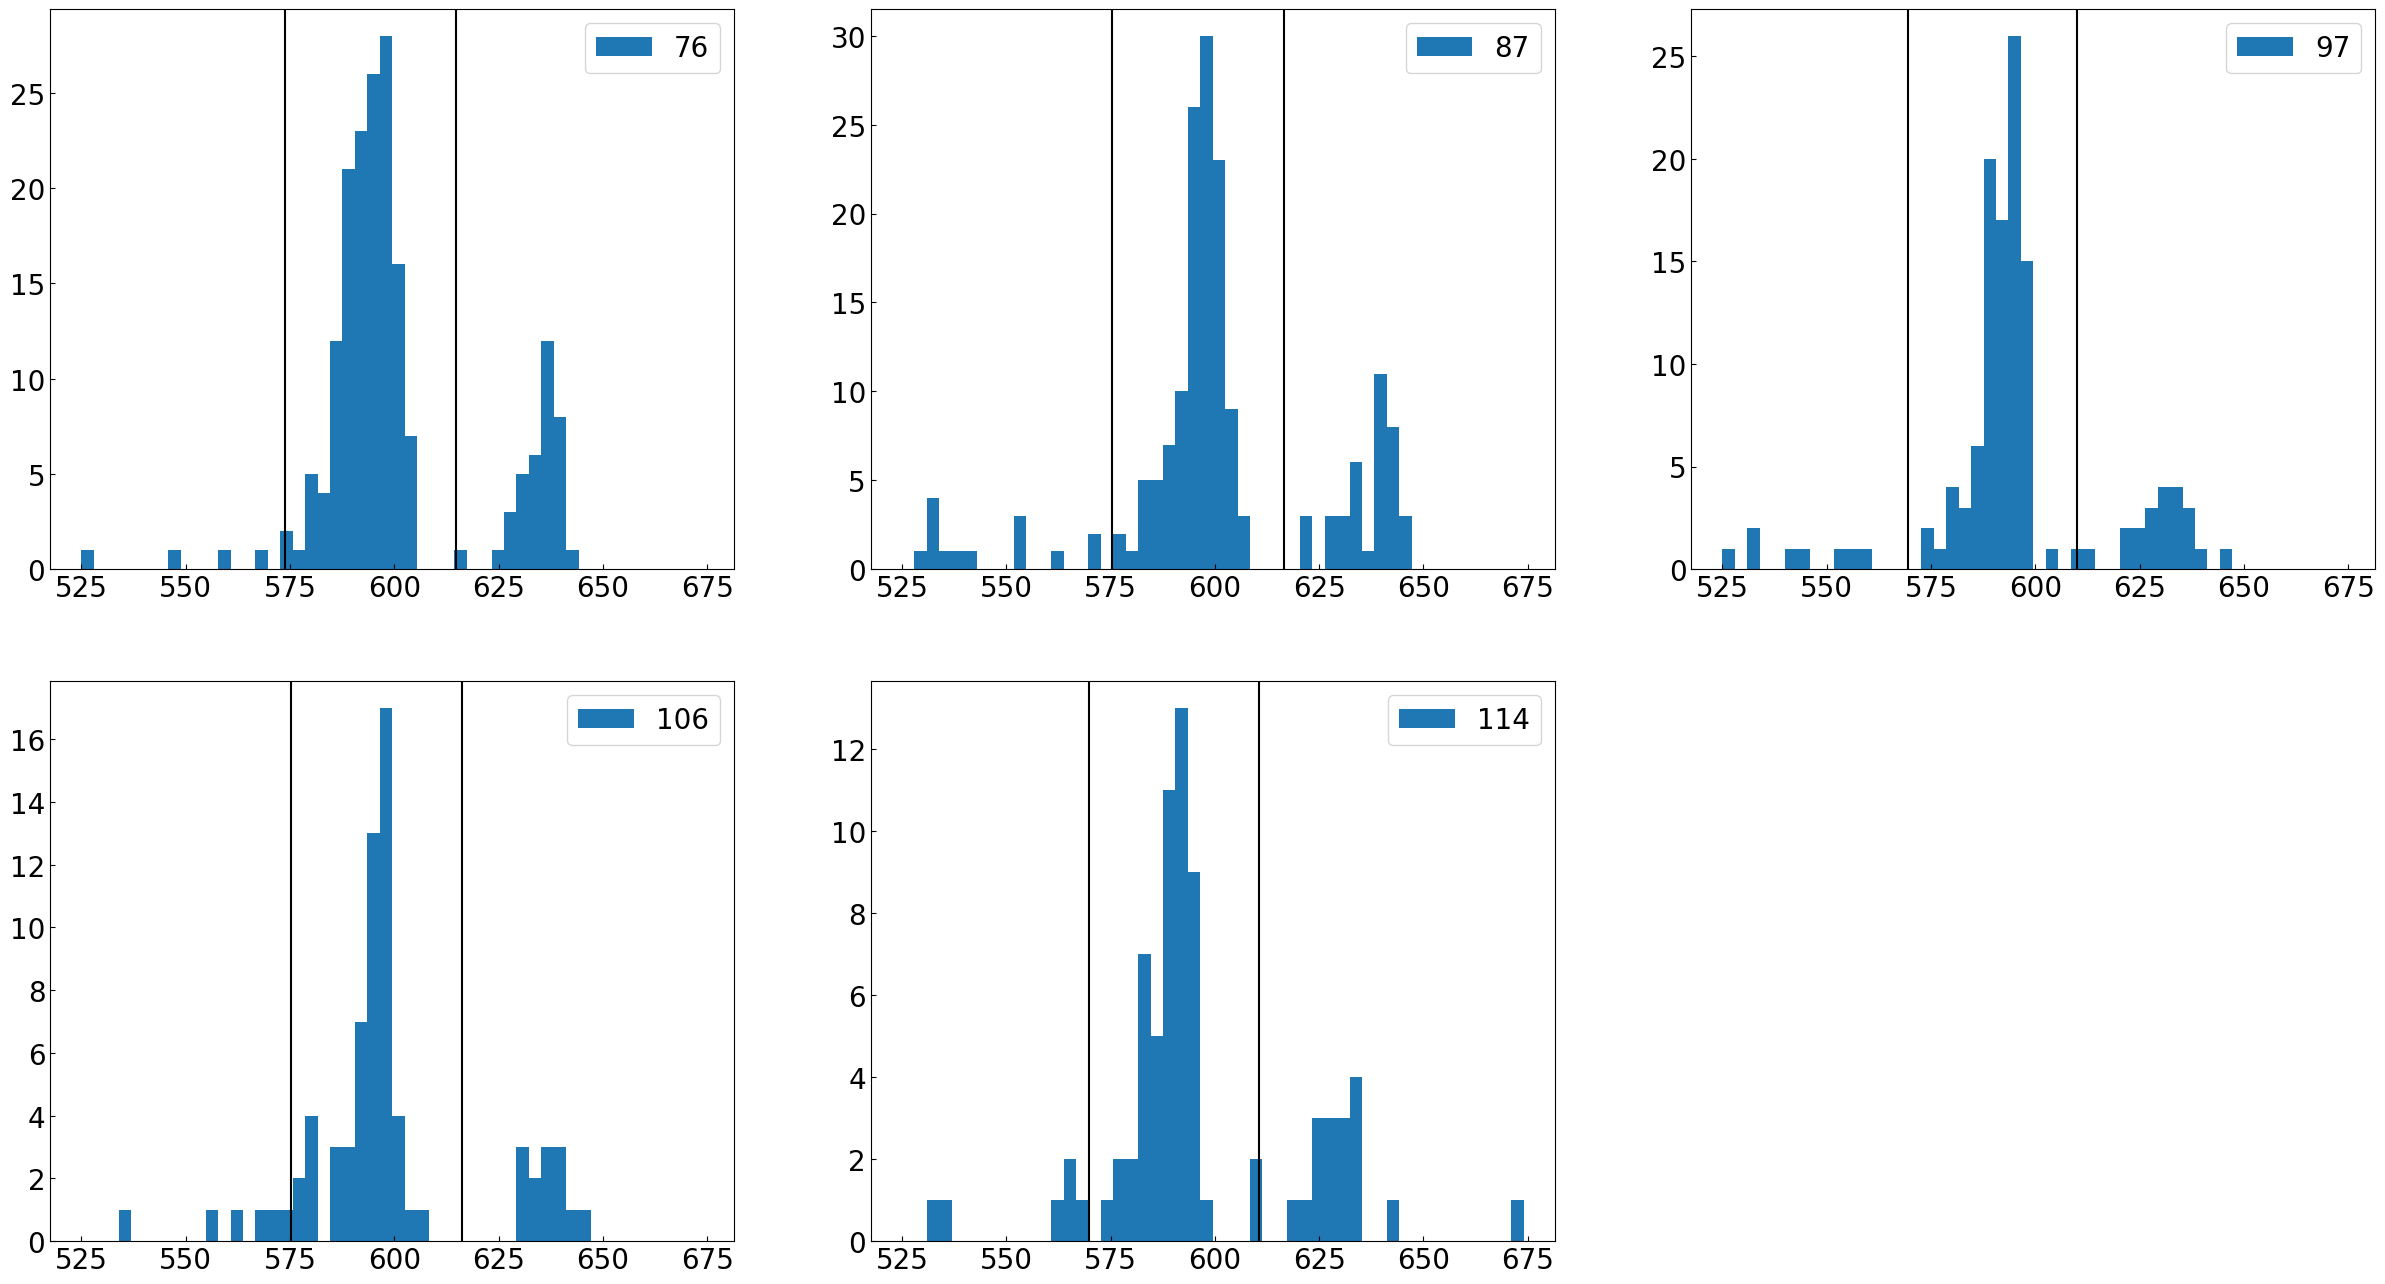

In [20]:
nrows,ncols=2,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(450,850)
cnt = 0
for i in range(len(pixel)):
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.hist(x[75:225],weights = np.float64(dataAll2[dataAll2['pixel']==pixel[i]].iloc[0]['CE hist'].replace('[','').replace(']','').split())[75:225],bins=50,label = '%d'%pixel[i])
    ax.axvline(high375_2[i][1],color = 'black')
    ax.axvline(low350_2[i][1],color = 'black')
    ax.legend(prop={'size':20})

plt.show()

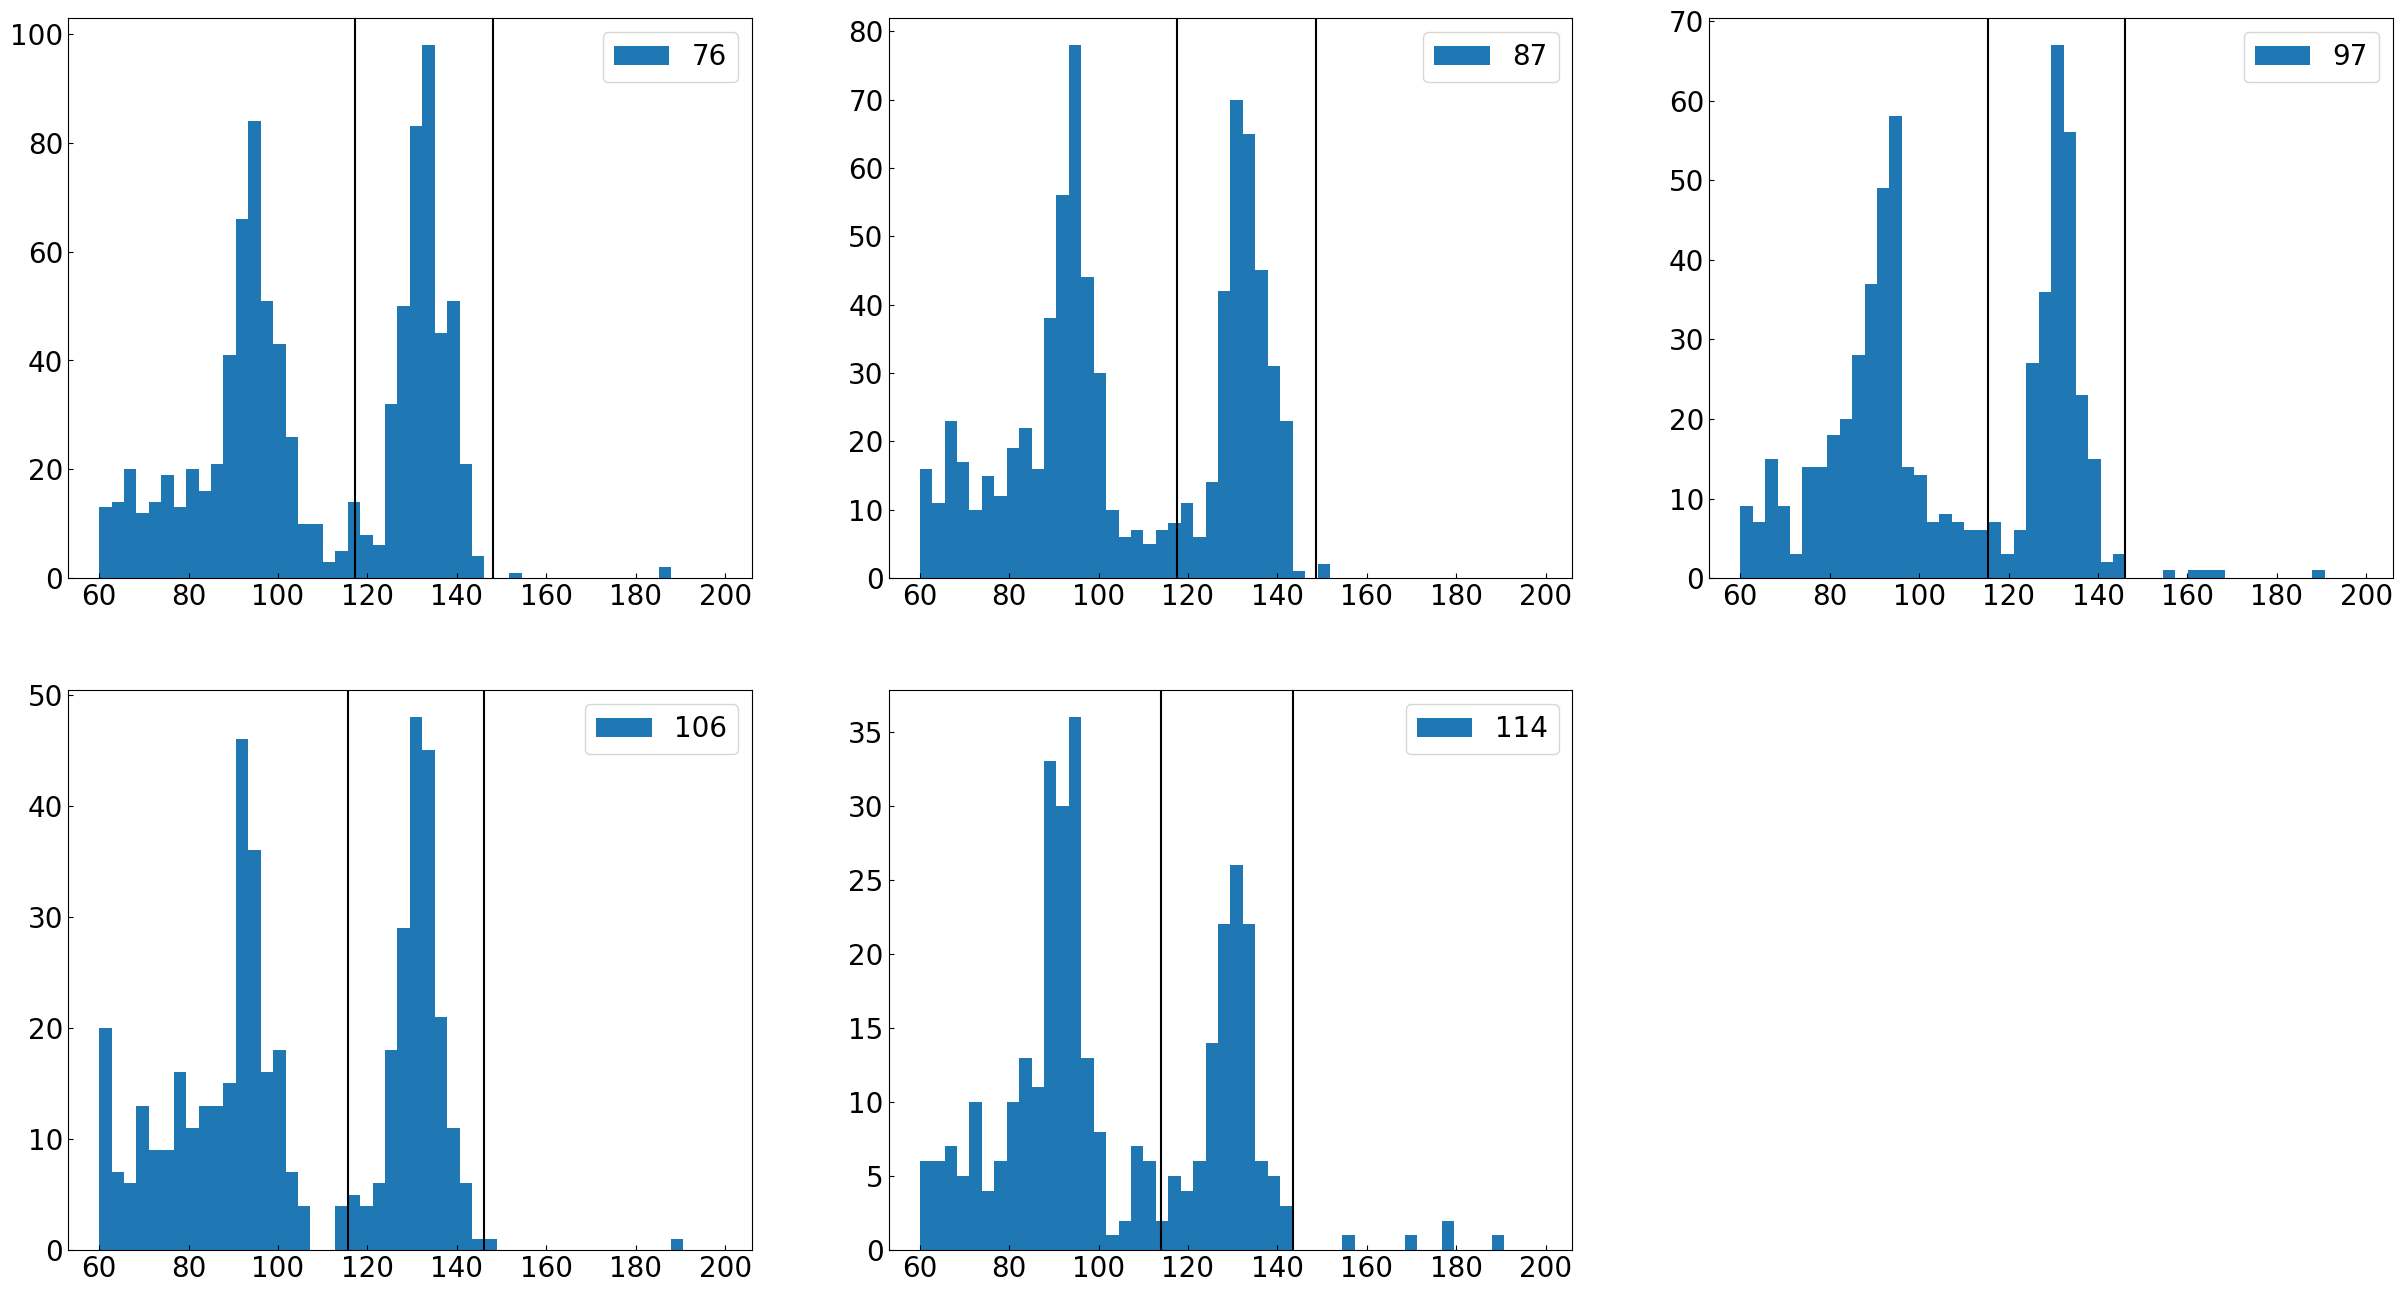

In [24]:
nrows,ncols=2,3
py.figure(figsize=(10*ncols,8*nrows))
x = np.arange(60,250)
cnt = 0
for i in range(len(pixel)):
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.hist(x[0:140],weights = np.float64(dataAll_Cd[dataAll_Cd['pixel']==pixel[i]].iloc[0]['CE hist'].replace('[','').replace(']','').split())[0:140],bins=50,label = '%d'%pixel[i])
    ax.axvline(high95_Cd[i][1],color = 'black')
    ax.axvline(low75_Cd[i][1],color = 'black')
    ax.legend(prop={'size':20})

plt.show()

In [22]:
def getCutByRuns(runs,pix,cut):
    byRuns = []
    for j in range(len(runs)):
        l = []
        for i in range(len(pix)):
            l.append(cut[i][j])
        byRuns.append(l)
    
    return byRuns

In [23]:
lowByRuns350 = getCutByRuns(runs,pix,low350)
highByRuns395 = getCutByRuns(runs,pix,high395)

lowByRuns350_2 = getCutByRuns(runs2,pix,low350_2)
highByRuns375_2 = getCutByRuns(runs2,pix,high375_2)

lowByRuns330 = getCutByRuns(runs,pix,low330)
highByRuns375 = getCutByRuns(runs,pix,high375)

lowByRuns75_Cd = getCutByRuns(runs2,pix,low75_Cd)
highByRuns95_Cd = getCutByRuns(runs2,pix,high95_Cd)

In [30]:
# %%time 
# riseTime_bothPeaks = []
# time_bothPeaks = []
# for i in range(len(runs)):
#     r, t = get_risetime(runs[i],pixel,lowByRuns350[i],highByRuns395[i])
#     riseTime_bothPeaks.append(r)
#     time_bothPeaks.append(t)
#     print(runs[i])

got run
got run
got run
got run
got run
1389
got run
got run
got run


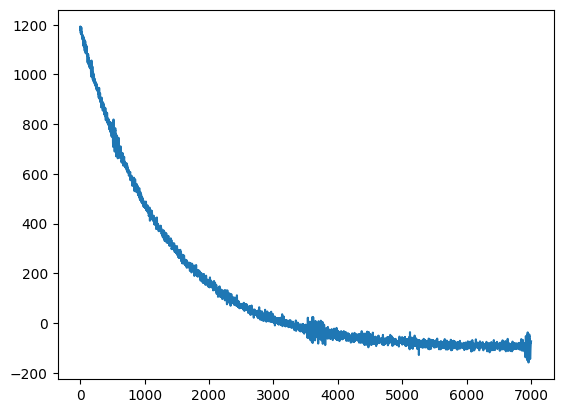

got run
got run
1374
got run
got run


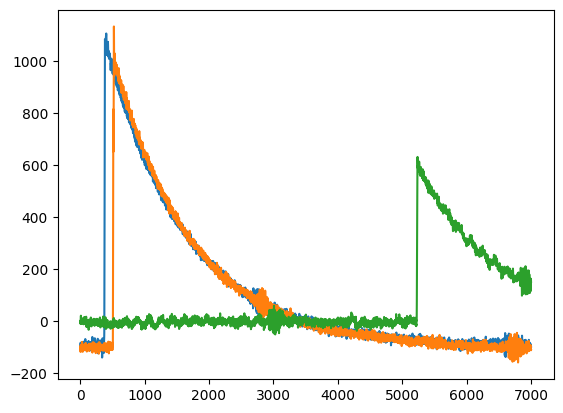

got run
got run
got run
1391
got run
got run
got run


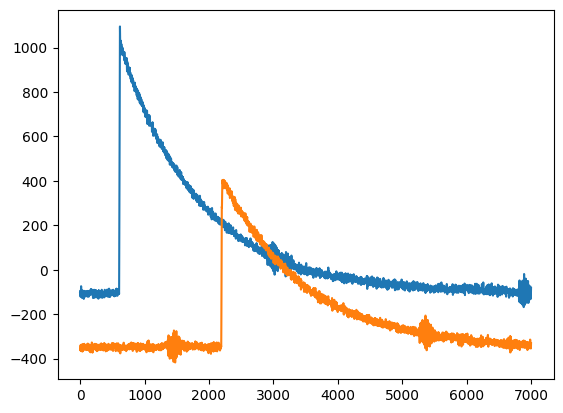

got run
got run
1392
got run
got run
got run
got run
got run


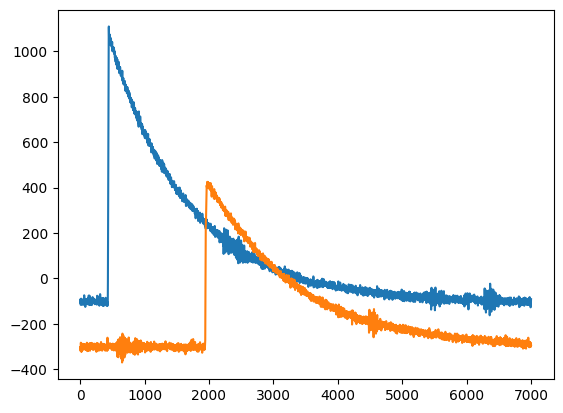

1393
CPU times: user 6min 31s, sys: 1min 10s, total: 7min 41s
Wall time: 27min 46s


In [31]:
%%time 
riseTime_singlePeakLoose = []
time_singlePeakLoose = []
for i in range(len(runs)):
    r, t = get_risetime(runs[i],pixel,lowByRuns350[i],highByRuns375[i])
    riseTime_singlePeakLoose.append(r)
    time_singlePeakLoose.append(t)
    print(runs[i])

In [29]:
# %%time 
# riseTime_singlePeakWide = []
# time_singlePeakWide = []
# for i in range(len(runs)):
#     r, t = get_risetime(runs[i],pixel,lowByRuns300[i],highByRuns375[i])
#     riseTime_singlePeakWide.append(r)
#     time_singlePeakWide.append(t)
#     print(runs[i])

In [28]:
# %%time 
# riseTime_singlePeakTight = []
# time_singlePeakTight = []
# for i in range(len(runs)):
#     r, t = get_risetime(runs[i],pixel,lowByRuns359[i],highByRuns369[i])
#     riseTime_singlePeakTight.append(r)
#     time_singlePeakTight.append(t)
#     print(runs[i])

got run
got run
got run
got run
got run
1375
got run
got run
got run
got run
got run
1376
got run
got run


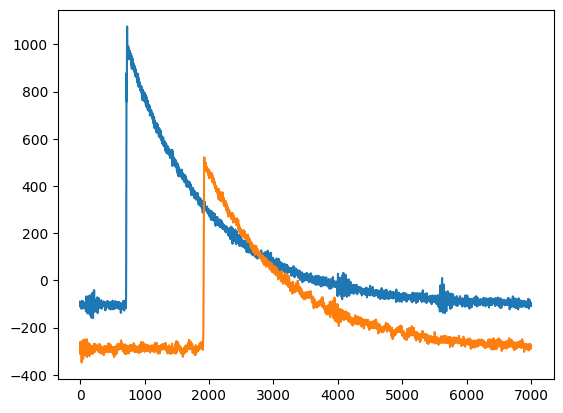

got run
got run
got run
1377
got run
got run
got run
got run
got run


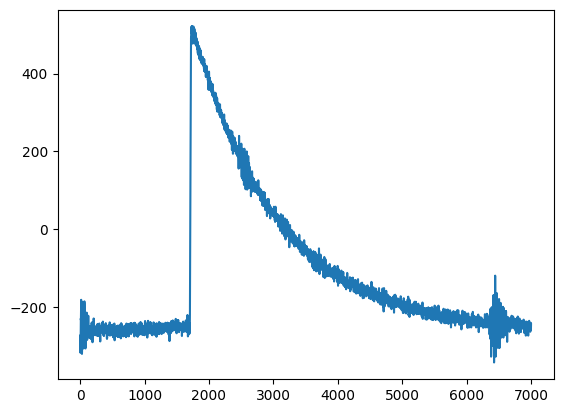

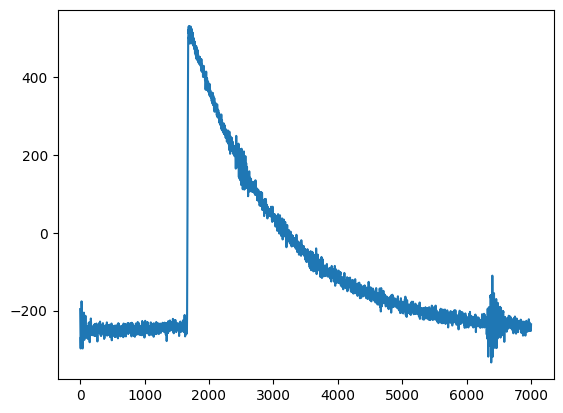

1379
got run
got run


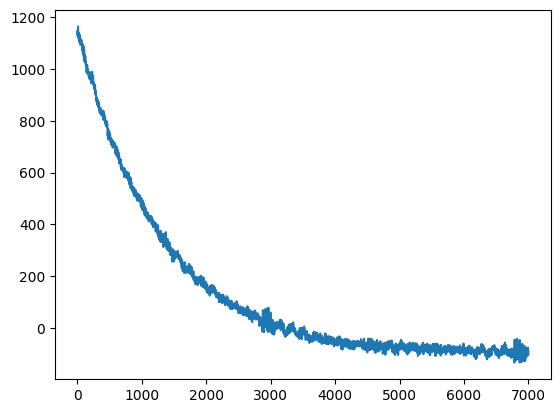

got run
got run
got run
1381
got run
got run
got run
got run
got run
1383
got run
got run
got run
got run
got run
1385
CPU times: user 3min 44s, sys: 46.1 s, total: 4min 30s
Wall time: 17min 51s


In [32]:
%%time 
riseTime_singlePeakLoose_2 = []
time_singlePeakLoose_2 = []
for i in range(len(runs2)):
    r, t = get_risetime(runs2[i],pixel,lowByRuns350_2[i],highByRuns375_2[i])
    riseTime_singlePeakLoose_2.append(r)
    time_singlePeakLoose_2.append(t)
    print(runs2[i])

In [27]:
# %%time 
# riseTime_singlePeakTight = []
# time_singlePeakTight = []
# for i in range(len(runs)):
#     r, t = get_risetime(runs[i],pixel,lowByRuns359[i],highByRuns369[i])
#     riseTime_singlePeakTight.append(r)
#     time_singlePeakTight.append(t)
#     print(runs[i])

In [26]:
# %%time 
# riseTime_bothPeaks_2 = []
# time_bothPeaks_2 = []
# for i in range(len(runs)):
#     r, t = get_risetime(runs[i],pixel,lowByRuns350_2[i],highByRuns395_2[i])
#     riseTime_bothPeaks_2.append(r)
#     time_bothPeaks_2.append(t)
#     print(runs[i])

got run
got run
got run
got run
got run
1749
got run
got run
got run
got run
got run
1751
got run
got run
got run
got run
got run
1756
got run
got run
got run
got run
got run
1760
got run
got run
got run
got run
got run
1763
got run
got run
got run
got run


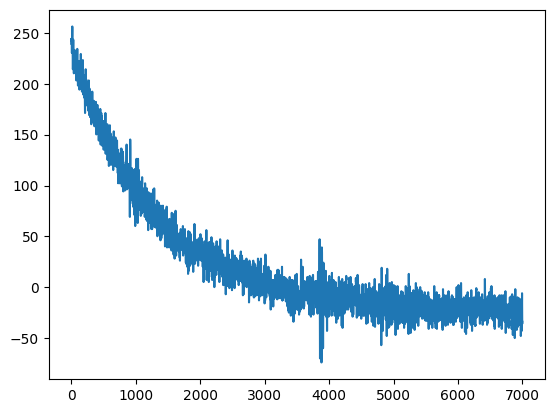

got run
1766
got run
got run
got run


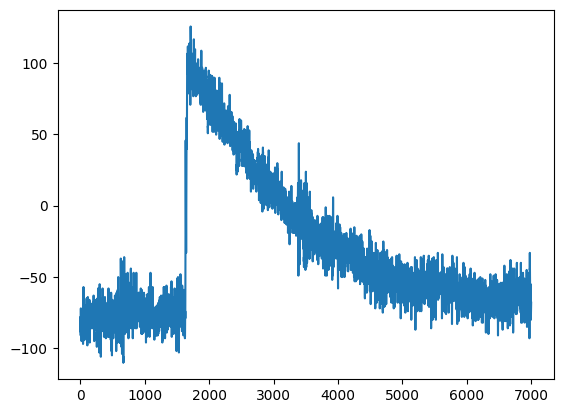

got run
got run
1769
CPU times: user 6min 26s, sys: 26.2 s, total: 6min 52s
Wall time: 15min 18s


In [25]:
%%time 
riseTime_singlePeakLoose_Cd = []
time_singlePeakLoose_Cd = []
for i in range(len(runs_Cd)):
    r, t = get_risetime(runs_Cd[i],pixel,lowByRuns75_Cd[i],highByRuns95_Cd[i])
    riseTime_singlePeakLoose_Cd.append(r)
    time_singlePeakLoose_Cd.append(t)
    print(runs_Cd[i])

In [33]:
ranges = [[25,40],[25,45],[25,47],[27,60],[35,65]]
p0 = [[26,30,3],[120,33,3],[17,35,3],[22,40,3],[15,50,3]]

In [34]:
colormap = plt.cm.nipy_spectral
colors = colormap(np.linspace(0, 1, 8))
# colors = ['red', 'orange','yellow','green','blue']

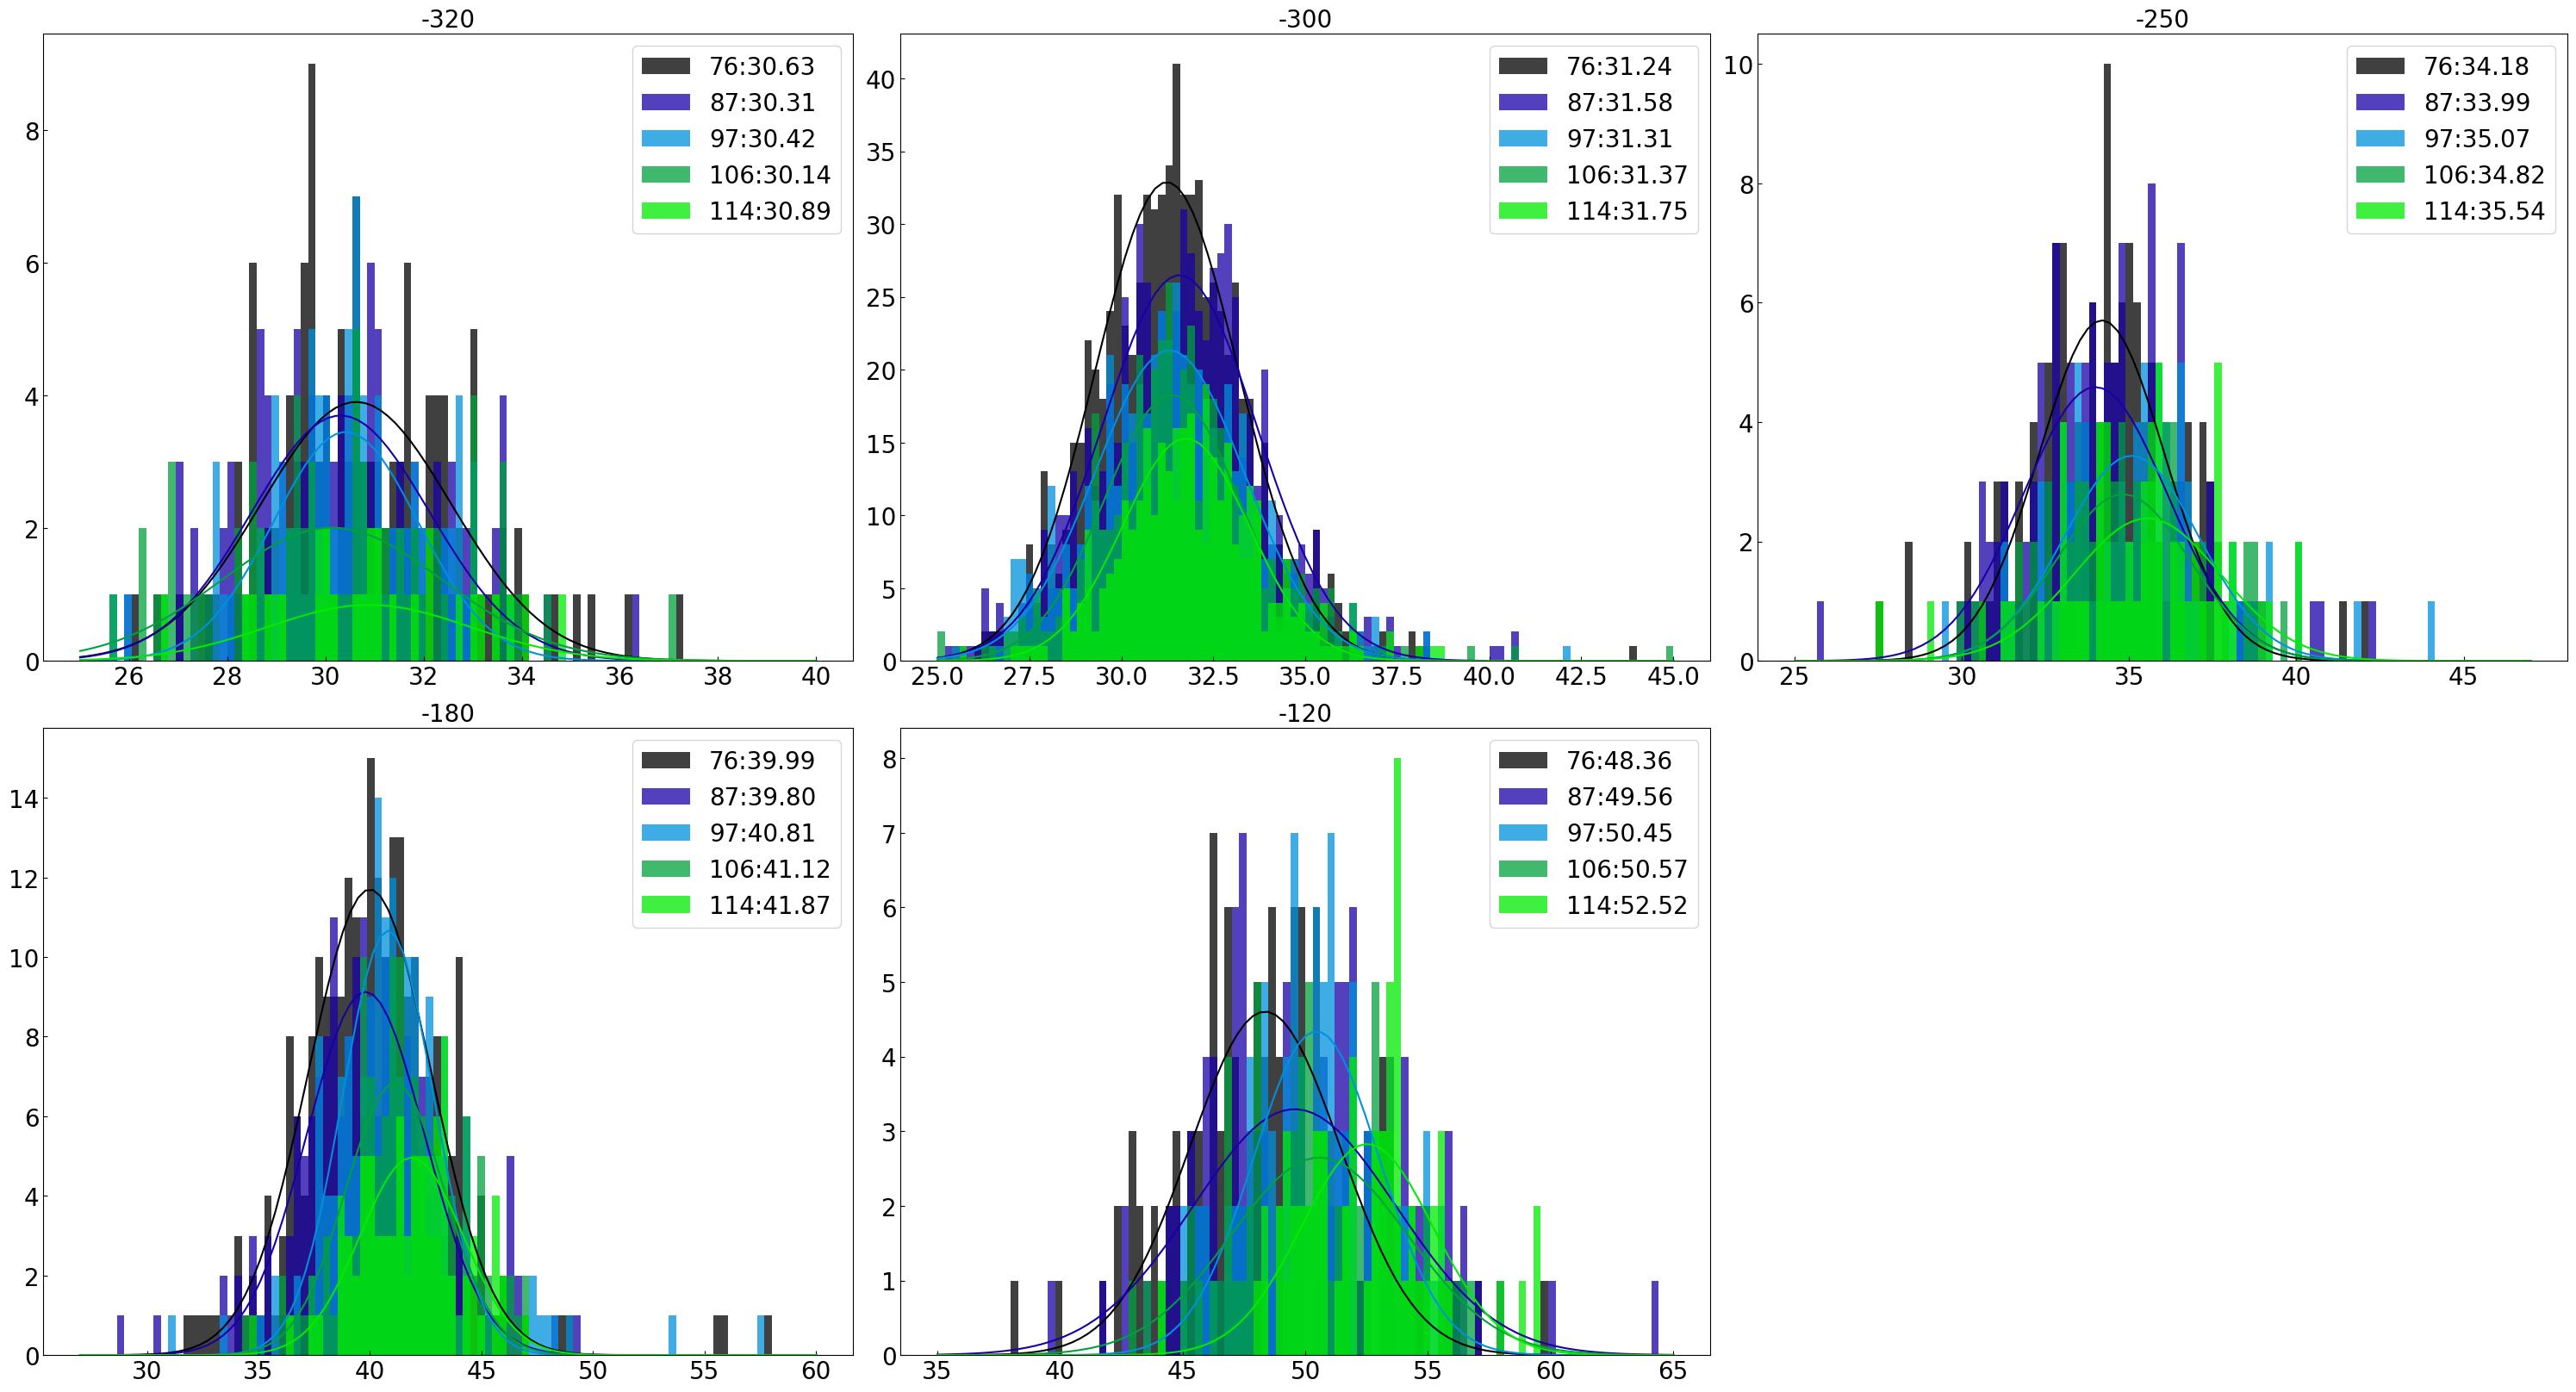

In [35]:
nrows,ncols=3,3
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
binNum = 100

for i in range(len(riseTime_singlePeakLoose)):
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.set_prop_cycle('color', colors)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%bias[i],size=20)
    for j in range(len(pixel)):
        
        y,x = np.histogram(riseTime_singlePeakLoose[i][j],bins = np.linspace(ranges[i][0],ranges[i][1],100))
        x = np.linspace(ranges[i][0],ranges[i][1],99)
        params, err = curve_fit(gaussian,x,y,p0 = p0[i])
        ax.hist(riseTime_singlePeakLoose[i][j],bins=100,range = (ranges[i][0],ranges[i][1]),label = '%d:%.2f'%(pixel[j],params[1]),alpha=0.75)
        
        ax.plot(x,gaussian(x,*params),color = colors[j])
        
        ax.legend(prop={'size':20})
py.tight_layout()

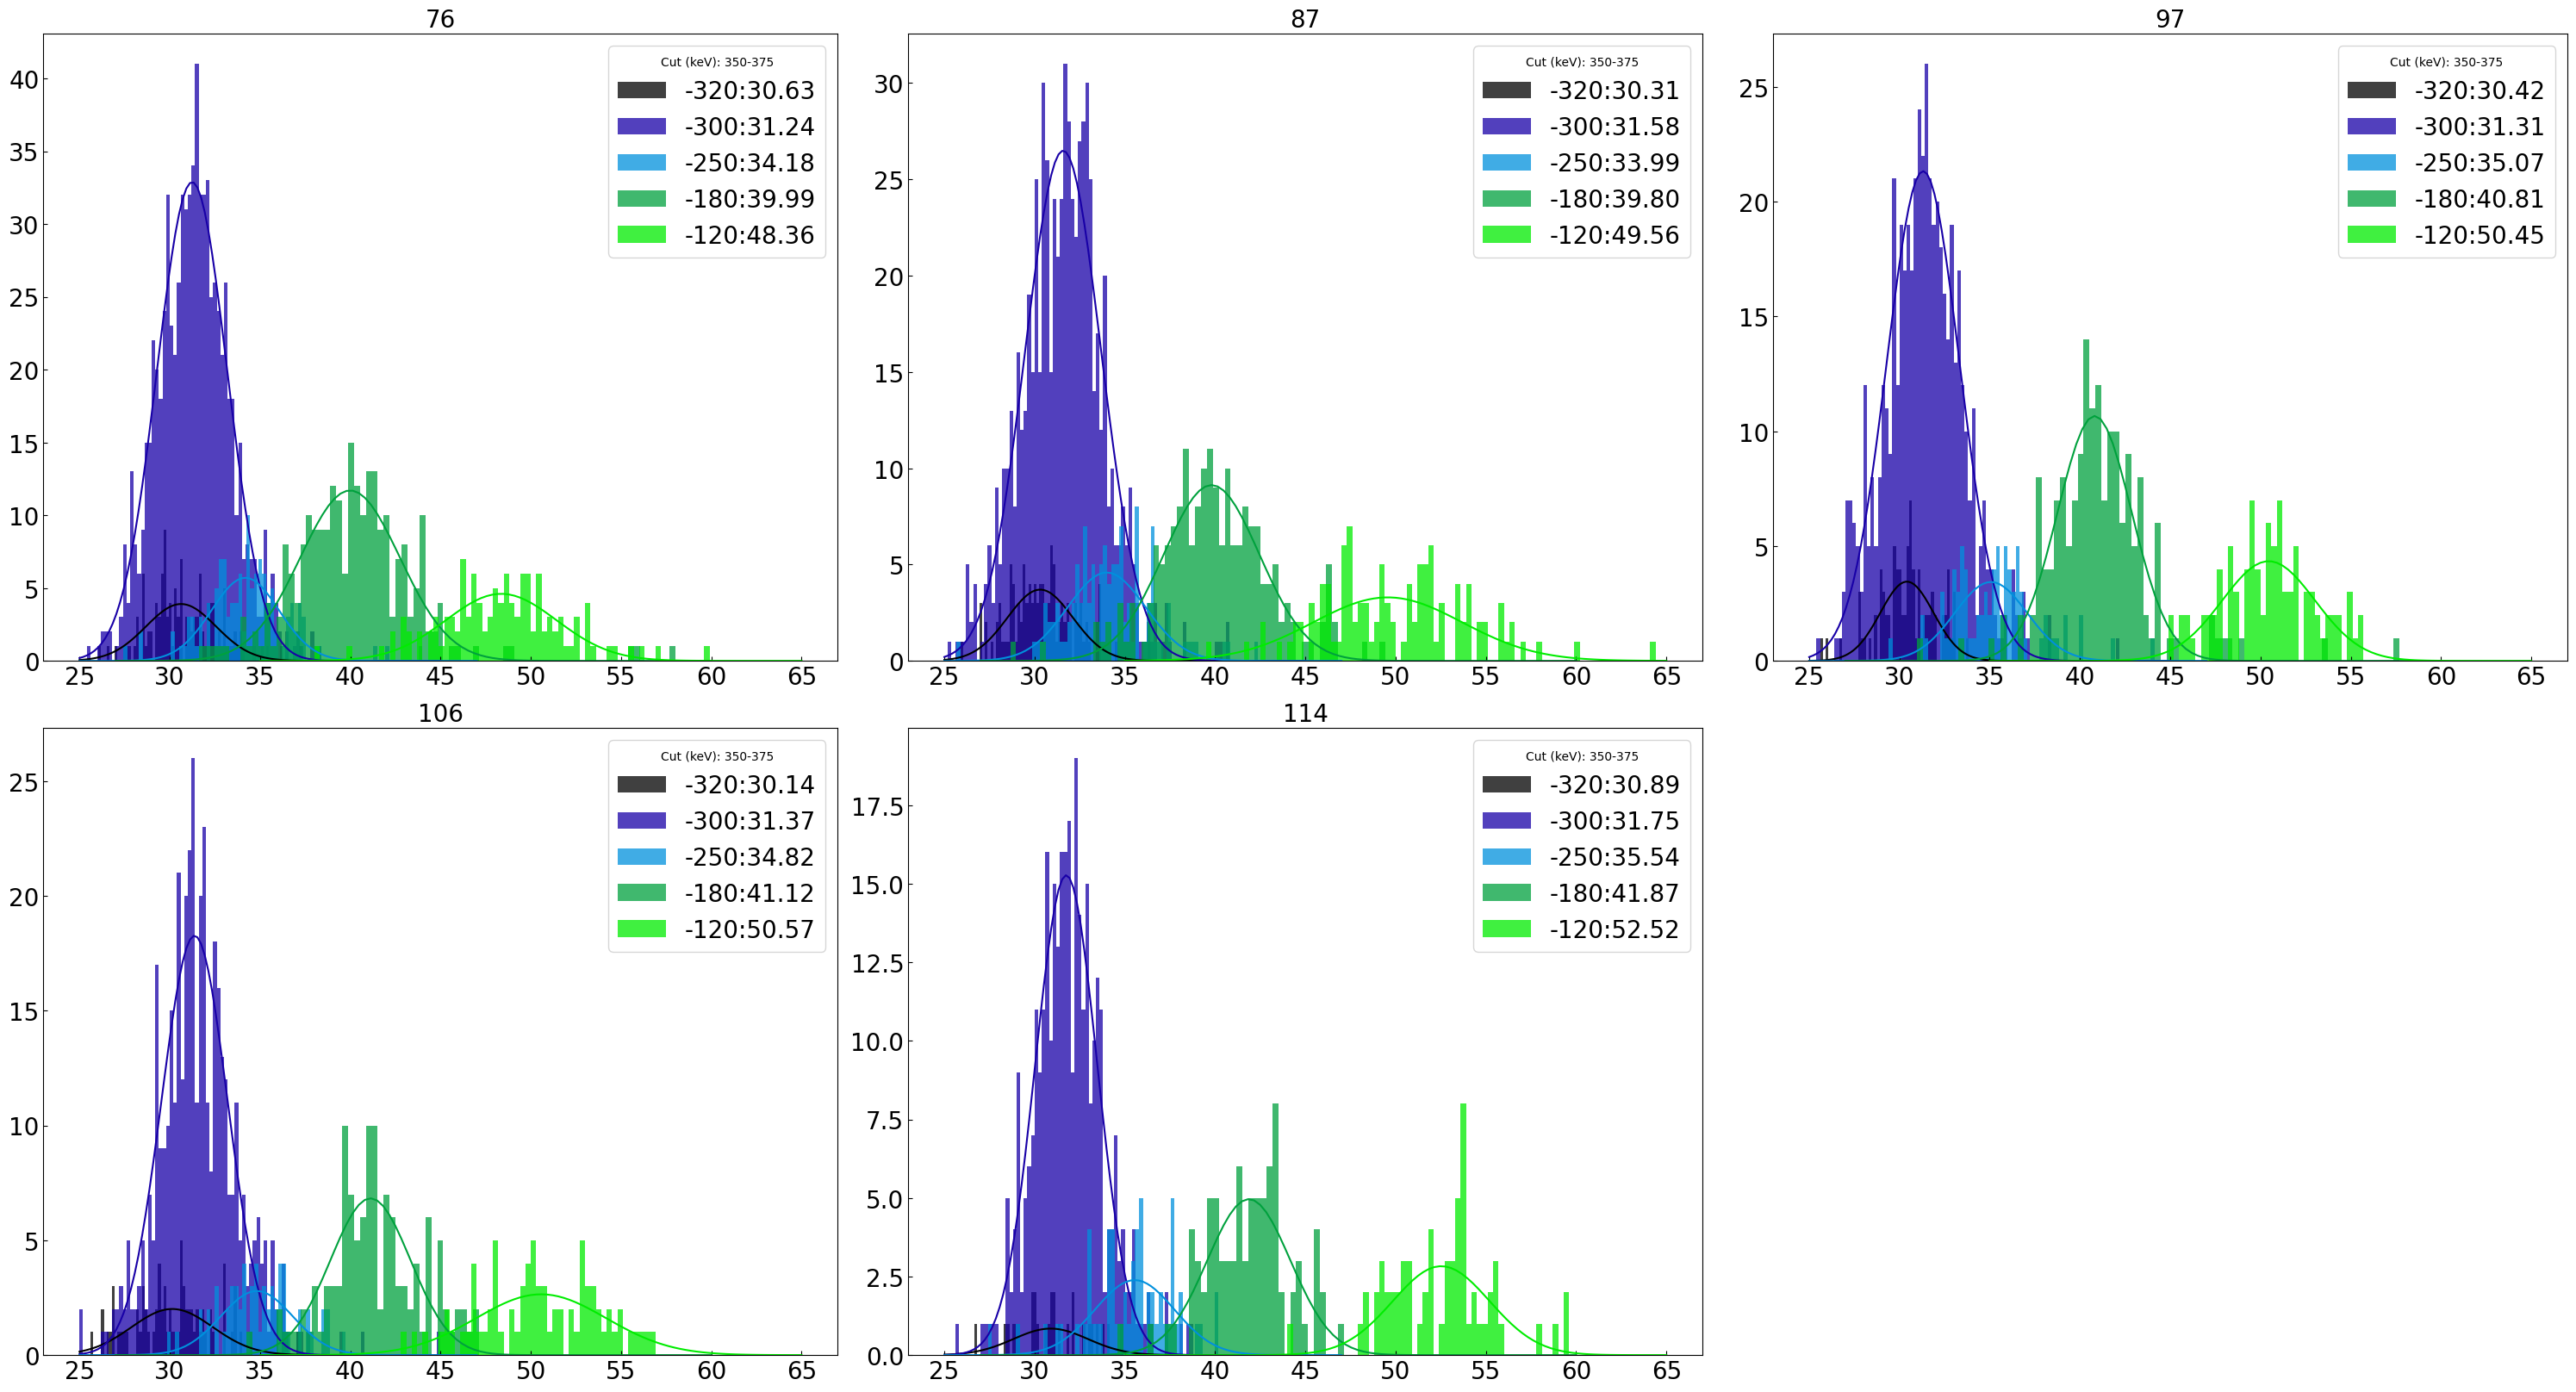

In [36]:
nrows,ncols=3,3
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
binNum = 100
centroidsLoose = []
centroid_errorsLoose = []
for j in range(len(pixel)):

    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.set_prop_cycle('color', colors)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%pixel[j],size=20)
    cent = []
    err_list = []
    for i in range(len(bias)):
        
        y,x = np.histogram(riseTime_singlePeakLoose[i][j],bins = np.linspace(ranges[i][0],ranges[i][1],100))
        x = np.linspace(ranges[i][0],ranges[i][1],99)
        params, err = curve_fit(gaussian,x,y,p0 = p0[i])
        
        cent.append(params[1])
        err_list.append(err[1])
        
        ax.hist(riseTime_singlePeakLoose[i][j],bins=100,range = (ranges[i][0],ranges[i][1]),label = '%d:%.2f'%(bias[i],params[1]),alpha=0.75)
        
        ax.plot(x,gaussian(x,*params),color = colors[i])
        
        ax.legend(prop={'size':20},title = "Cut (keV): 350-375")
    centroidsLoose.append(cent)
    centroid_errorsLoose.append(err_list)
py.tight_layout()

In [37]:
ranges2 = [[22,40],[25,45],[25,47],[25,50],[25,60],[25,65],[35,70]]
p02 = [[26,30,3],[12,33,3],[17,35,3],[18,38,3],[22,40,3],[5,45,3],[5,50,3]]

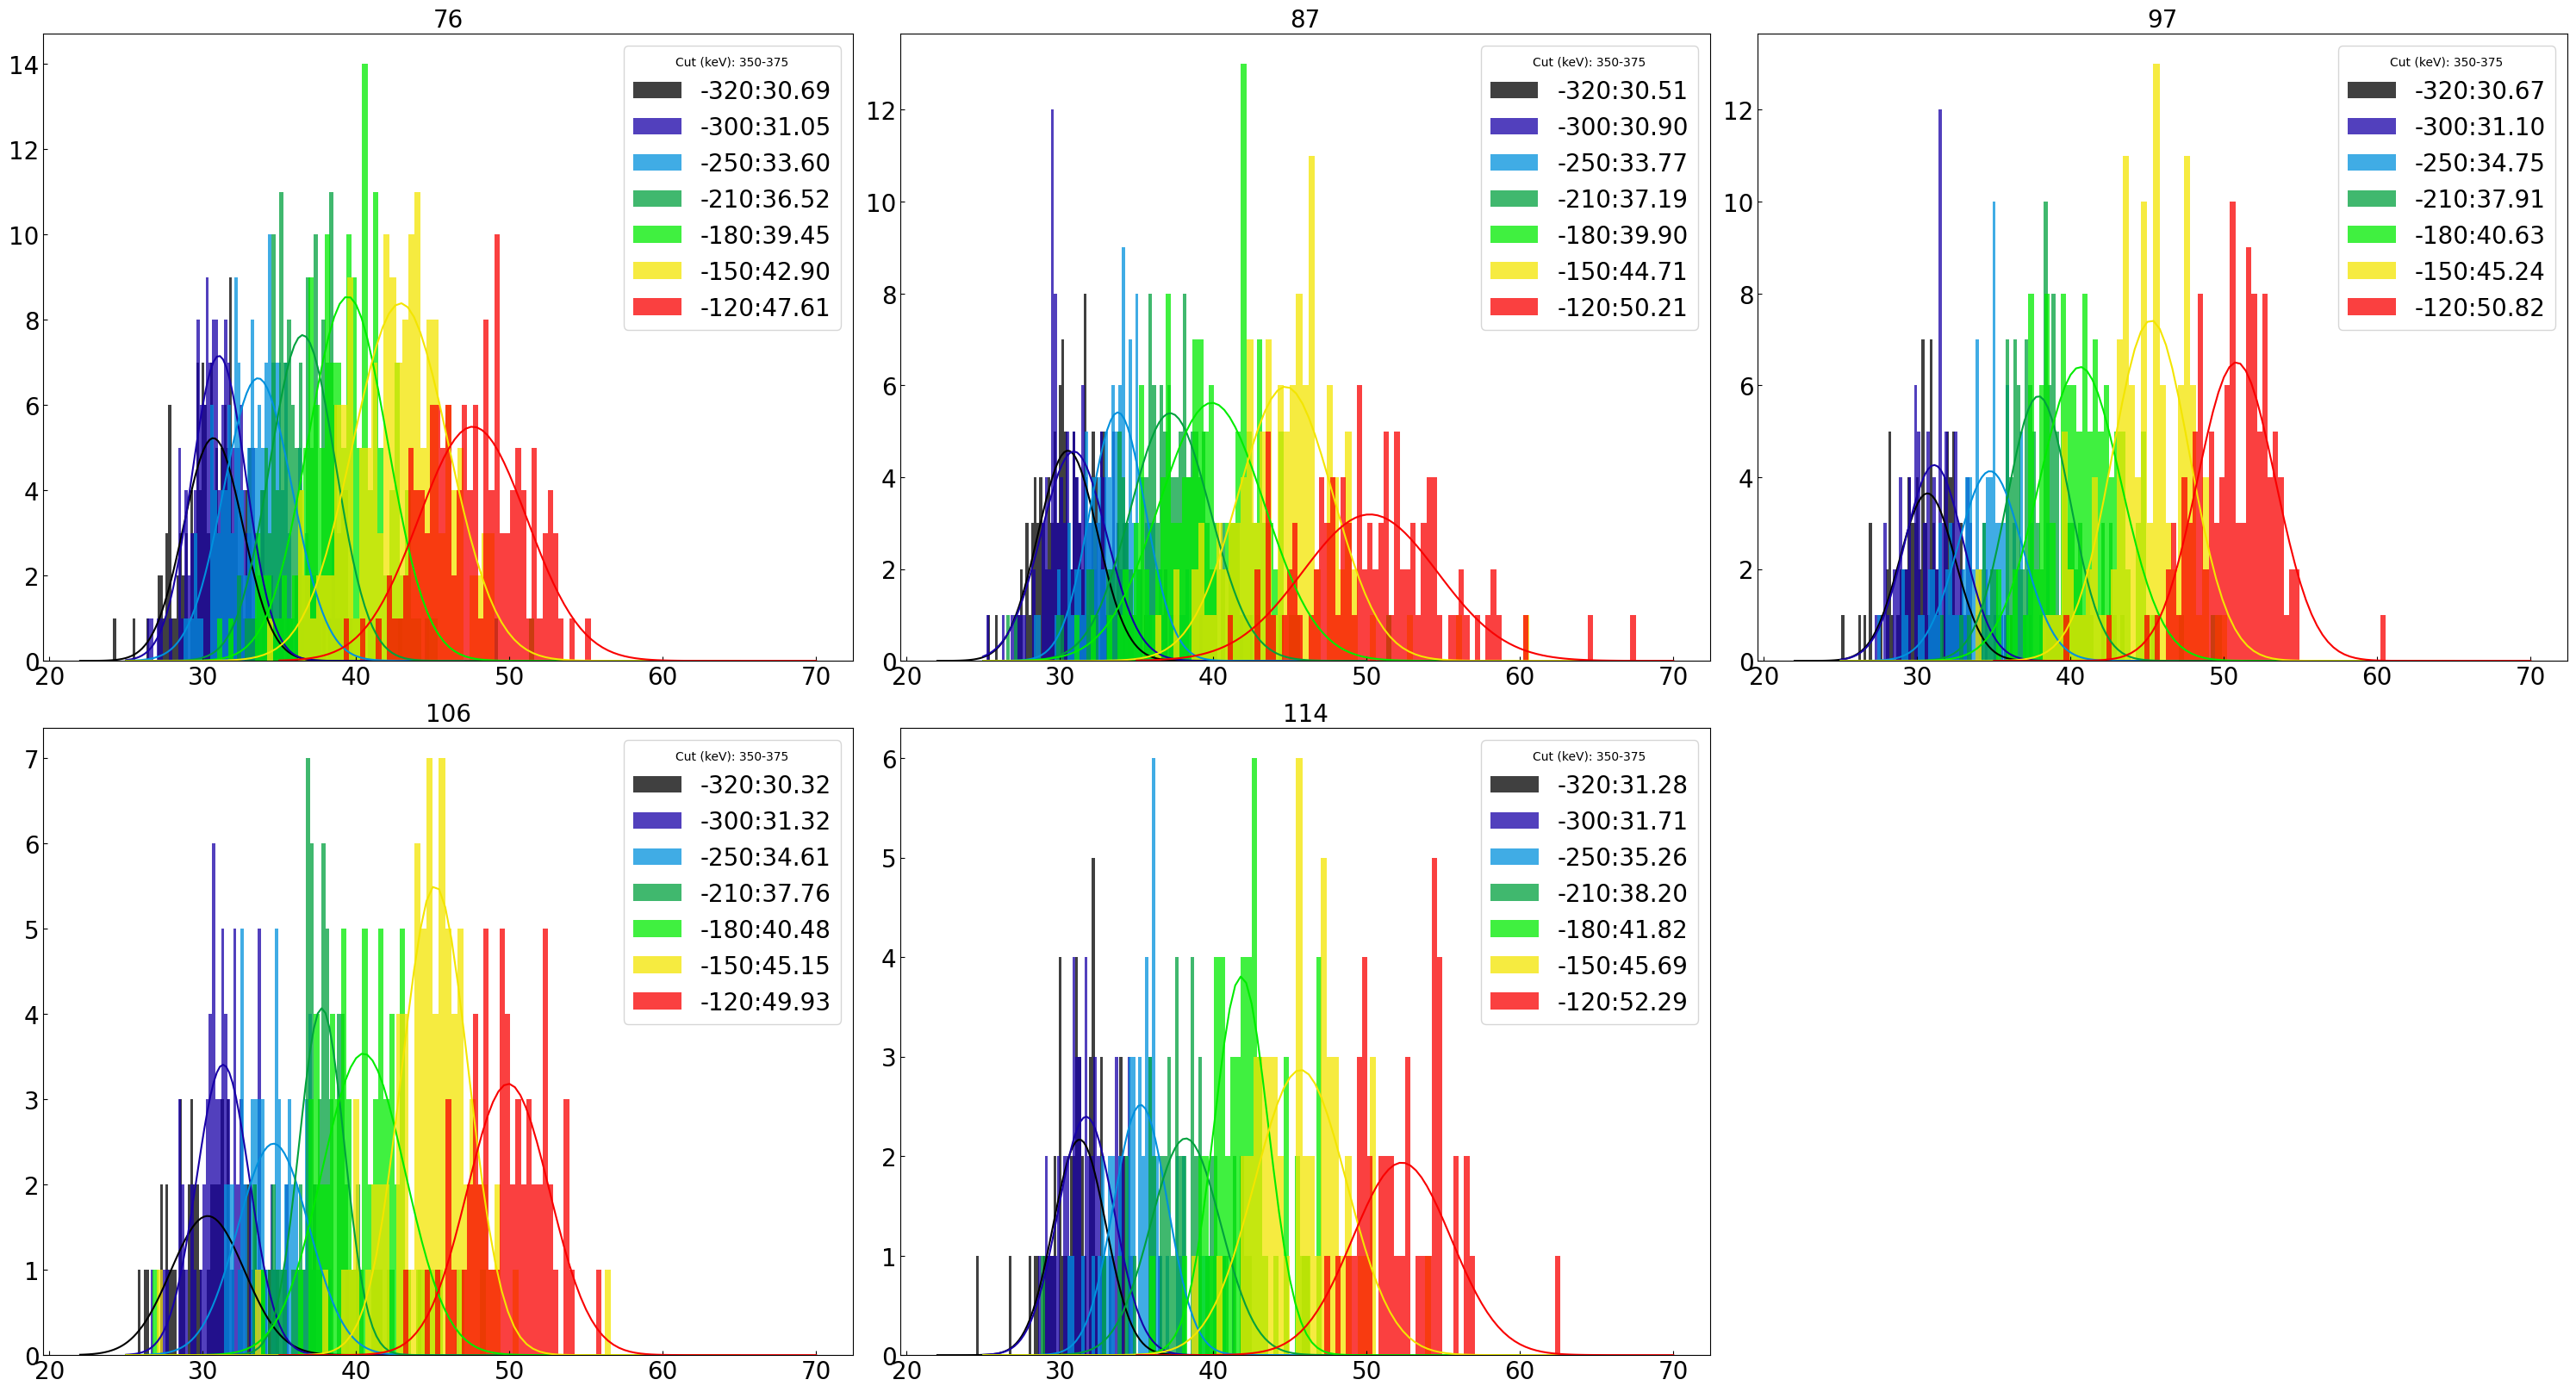

In [38]:
nrows,ncols=3,3
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
binNum = 100
centroidsLoose_2 = []
centroid_errorsLoose_2 = []
for j in range(len(pixel)):

    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.set_prop_cycle('color', colors)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%pixel[j],size=20)
    cent = []
    err_list = []
    for i in range(len(bias2)):
        
        y,x = np.histogram(riseTime_singlePeakLoose_2[i][j],bins = np.linspace(ranges2[i][0],ranges2[i][1],100))
        x = np.linspace(ranges2[i][0],ranges2[i][1],99)
        params, err = curve_fit(gaussian,x,y,p0 = p02[i],maxfev=3000)
        
        cent.append(params[1])
        err_list.append(err[1])
        
        ax.hist(riseTime_singlePeakLoose_2[i][j],bins=100,range = (ranges2[i][0],ranges2[i][1]),label = '%d:%.2f'%(bias2[i],params[1]),alpha=0.75)
        
        ax.plot(x,gaussian(x,*params),color = colors[i])
        
        ax.legend(prop={'size':20},title = "Cut (keV): 350-375")
    centroidsLoose_2.append(cent)
    centroid_errorsLoose_2.append(err_list)
py.tight_layout()

In [39]:
ranges3 = [[25,70],[25,70],[25,80],[25,80],[25,80],[25,90],[35,100]]
p03 = [[8,35,3],[8,35,3],[10,40,3],[8,45,3],[10,50,3],[10,60,3],[8,70,3]]

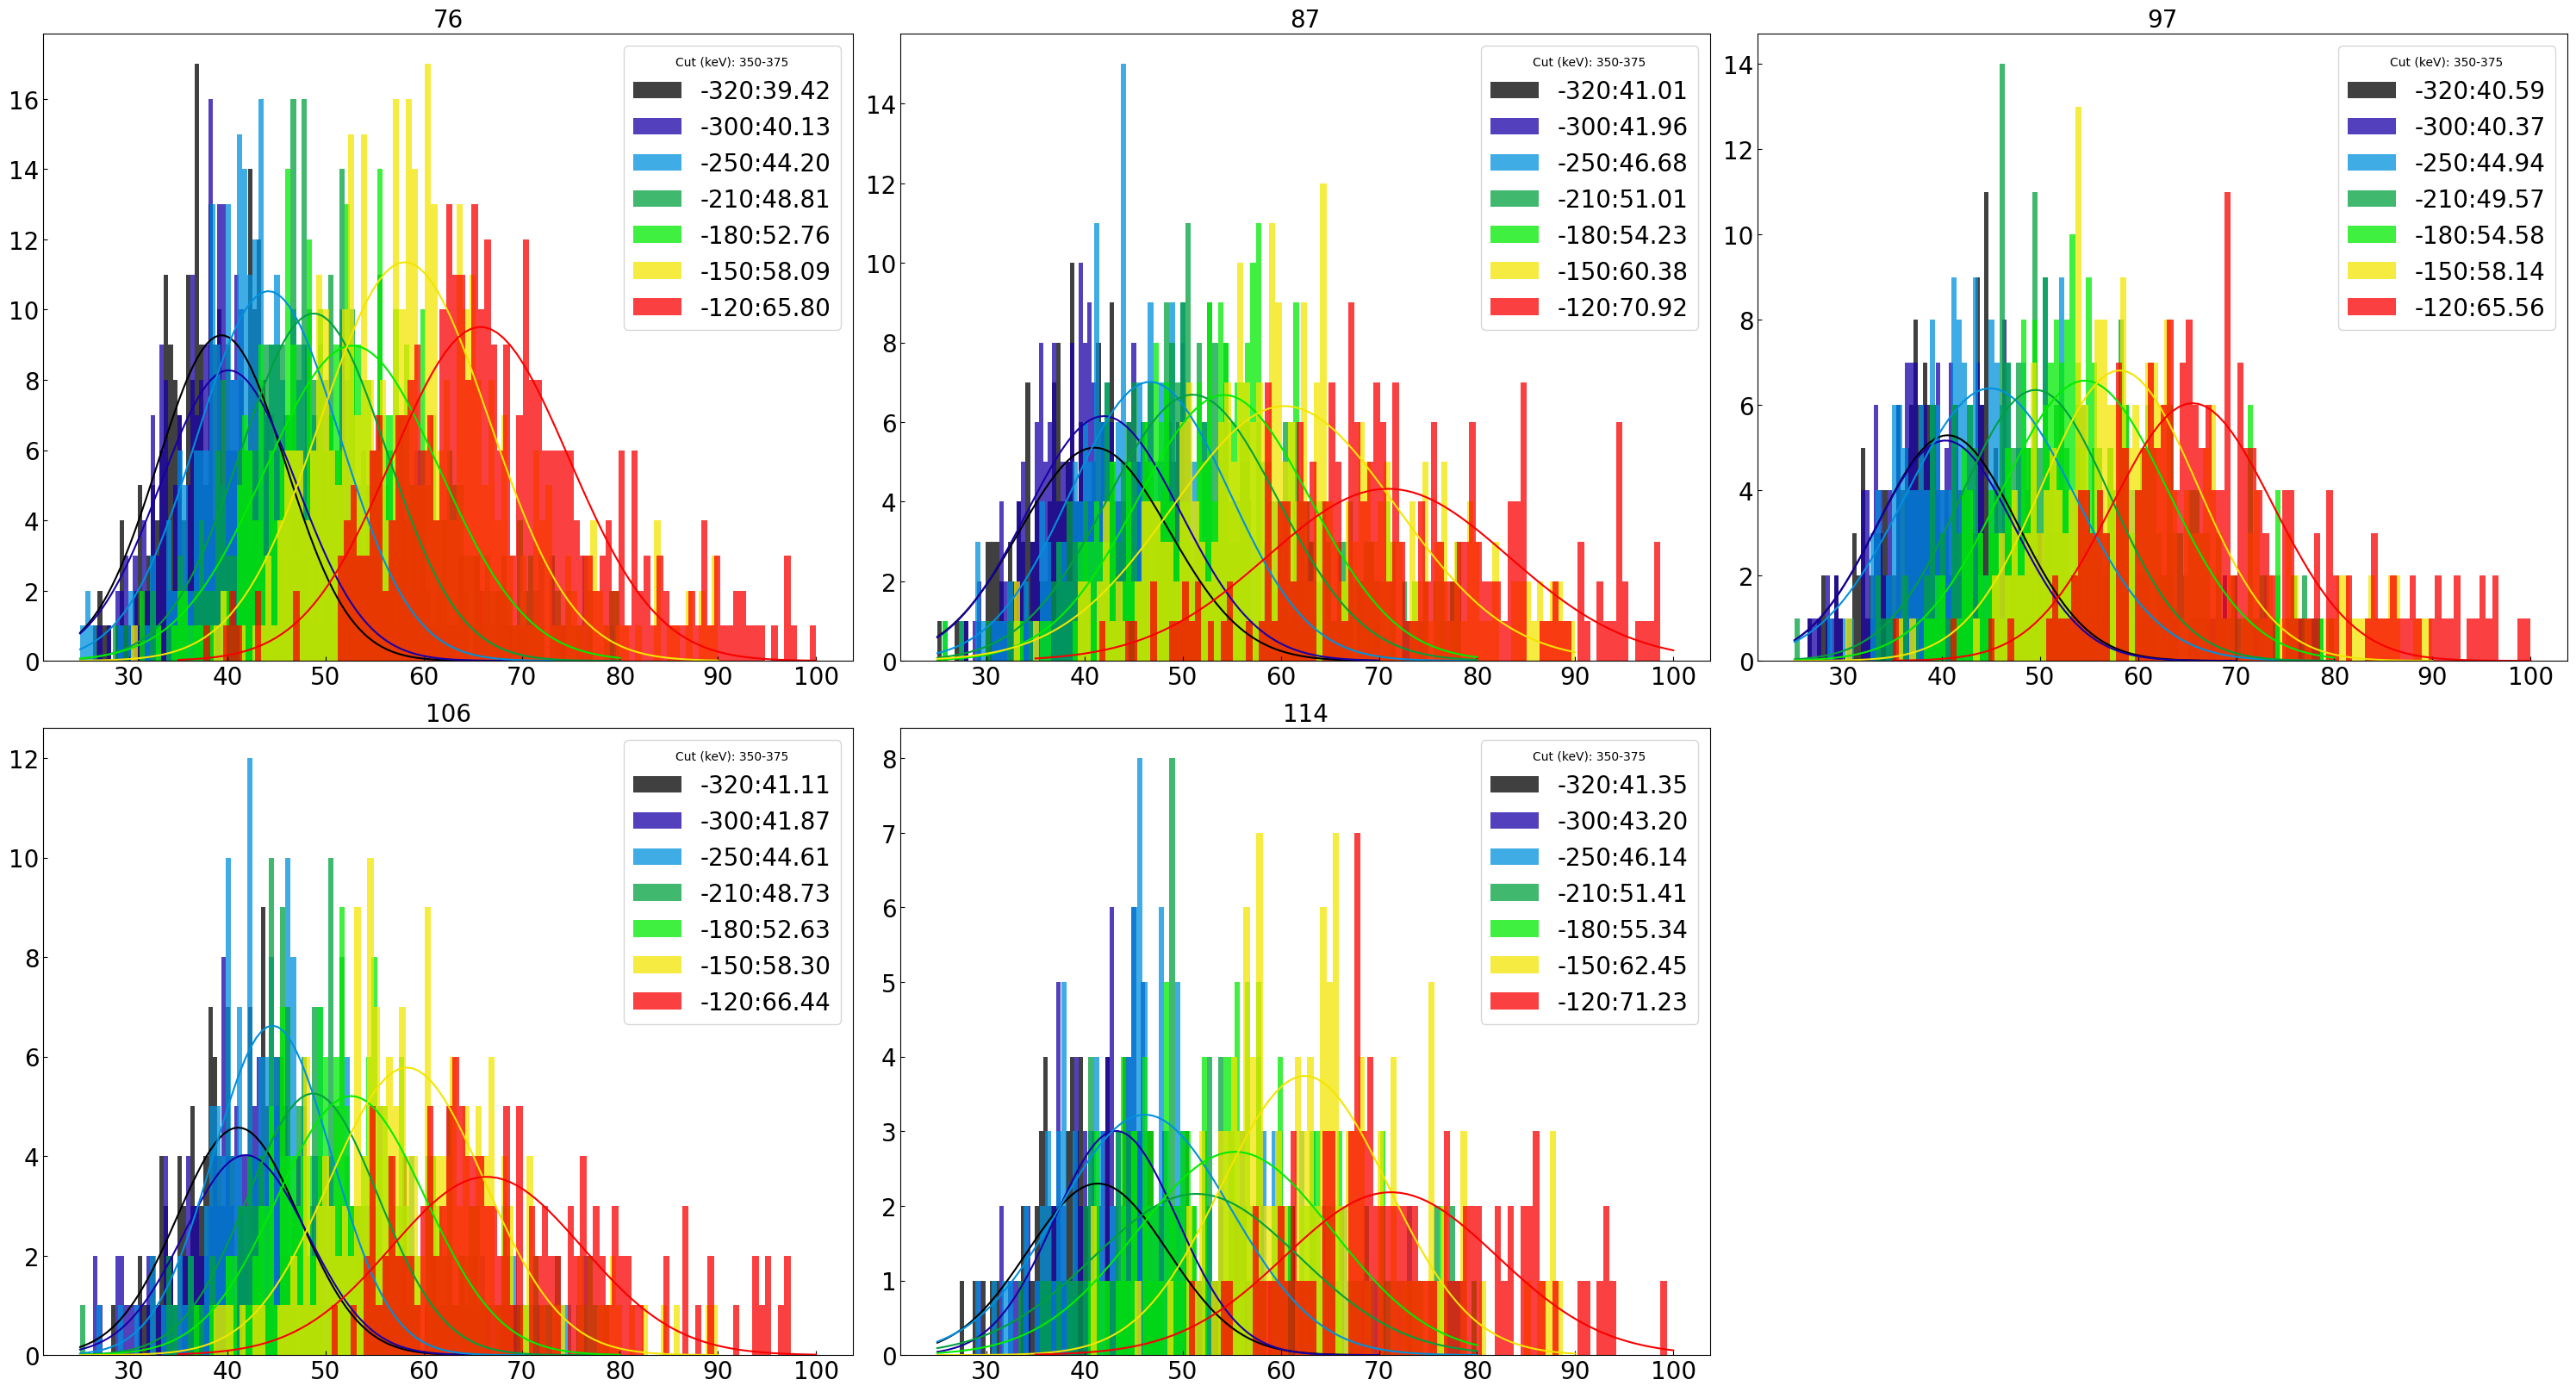

In [40]:
nrows,ncols=3,3
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
binNum = 100
centroidsLoose_Cd = []
centroid_errorsLoose_Cd = []
for j in range(len(pixel)):

    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.set_prop_cycle('color', colors)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%pixel[j],size=20)
    cent = []
    err_list = []
    for i in range(len(bias2)):
        
        y,x = np.histogram(riseTime_singlePeakLoose_Cd[i][j],bins = np.linspace(ranges3[i][0],ranges3[i][1],100))
        x = np.linspace(ranges3[i][0],ranges3[i][1],99)
        params, err = curve_fit(gaussian,x,y,p0 = p03[i],maxfev=3000)
        
        cent.append(params[1])
        err_list.append(err[1])
        
        ax.hist(riseTime_singlePeakLoose_Cd[i][j],bins=100,range = (ranges3[i][0],ranges3[i][1]),label = '%d:%.2f'%(bias2[i],params[1]),alpha=0.75)
        
        ax.plot(x,gaussian(x,*params),color = colors[i])
        
        ax.legend(prop={'size':20},title = "Cut (keV): 350-375")
    centroidsLoose_Cd.append(cent)
    centroid_errorsLoose_Cd.append(err_list)
py.tight_layout()

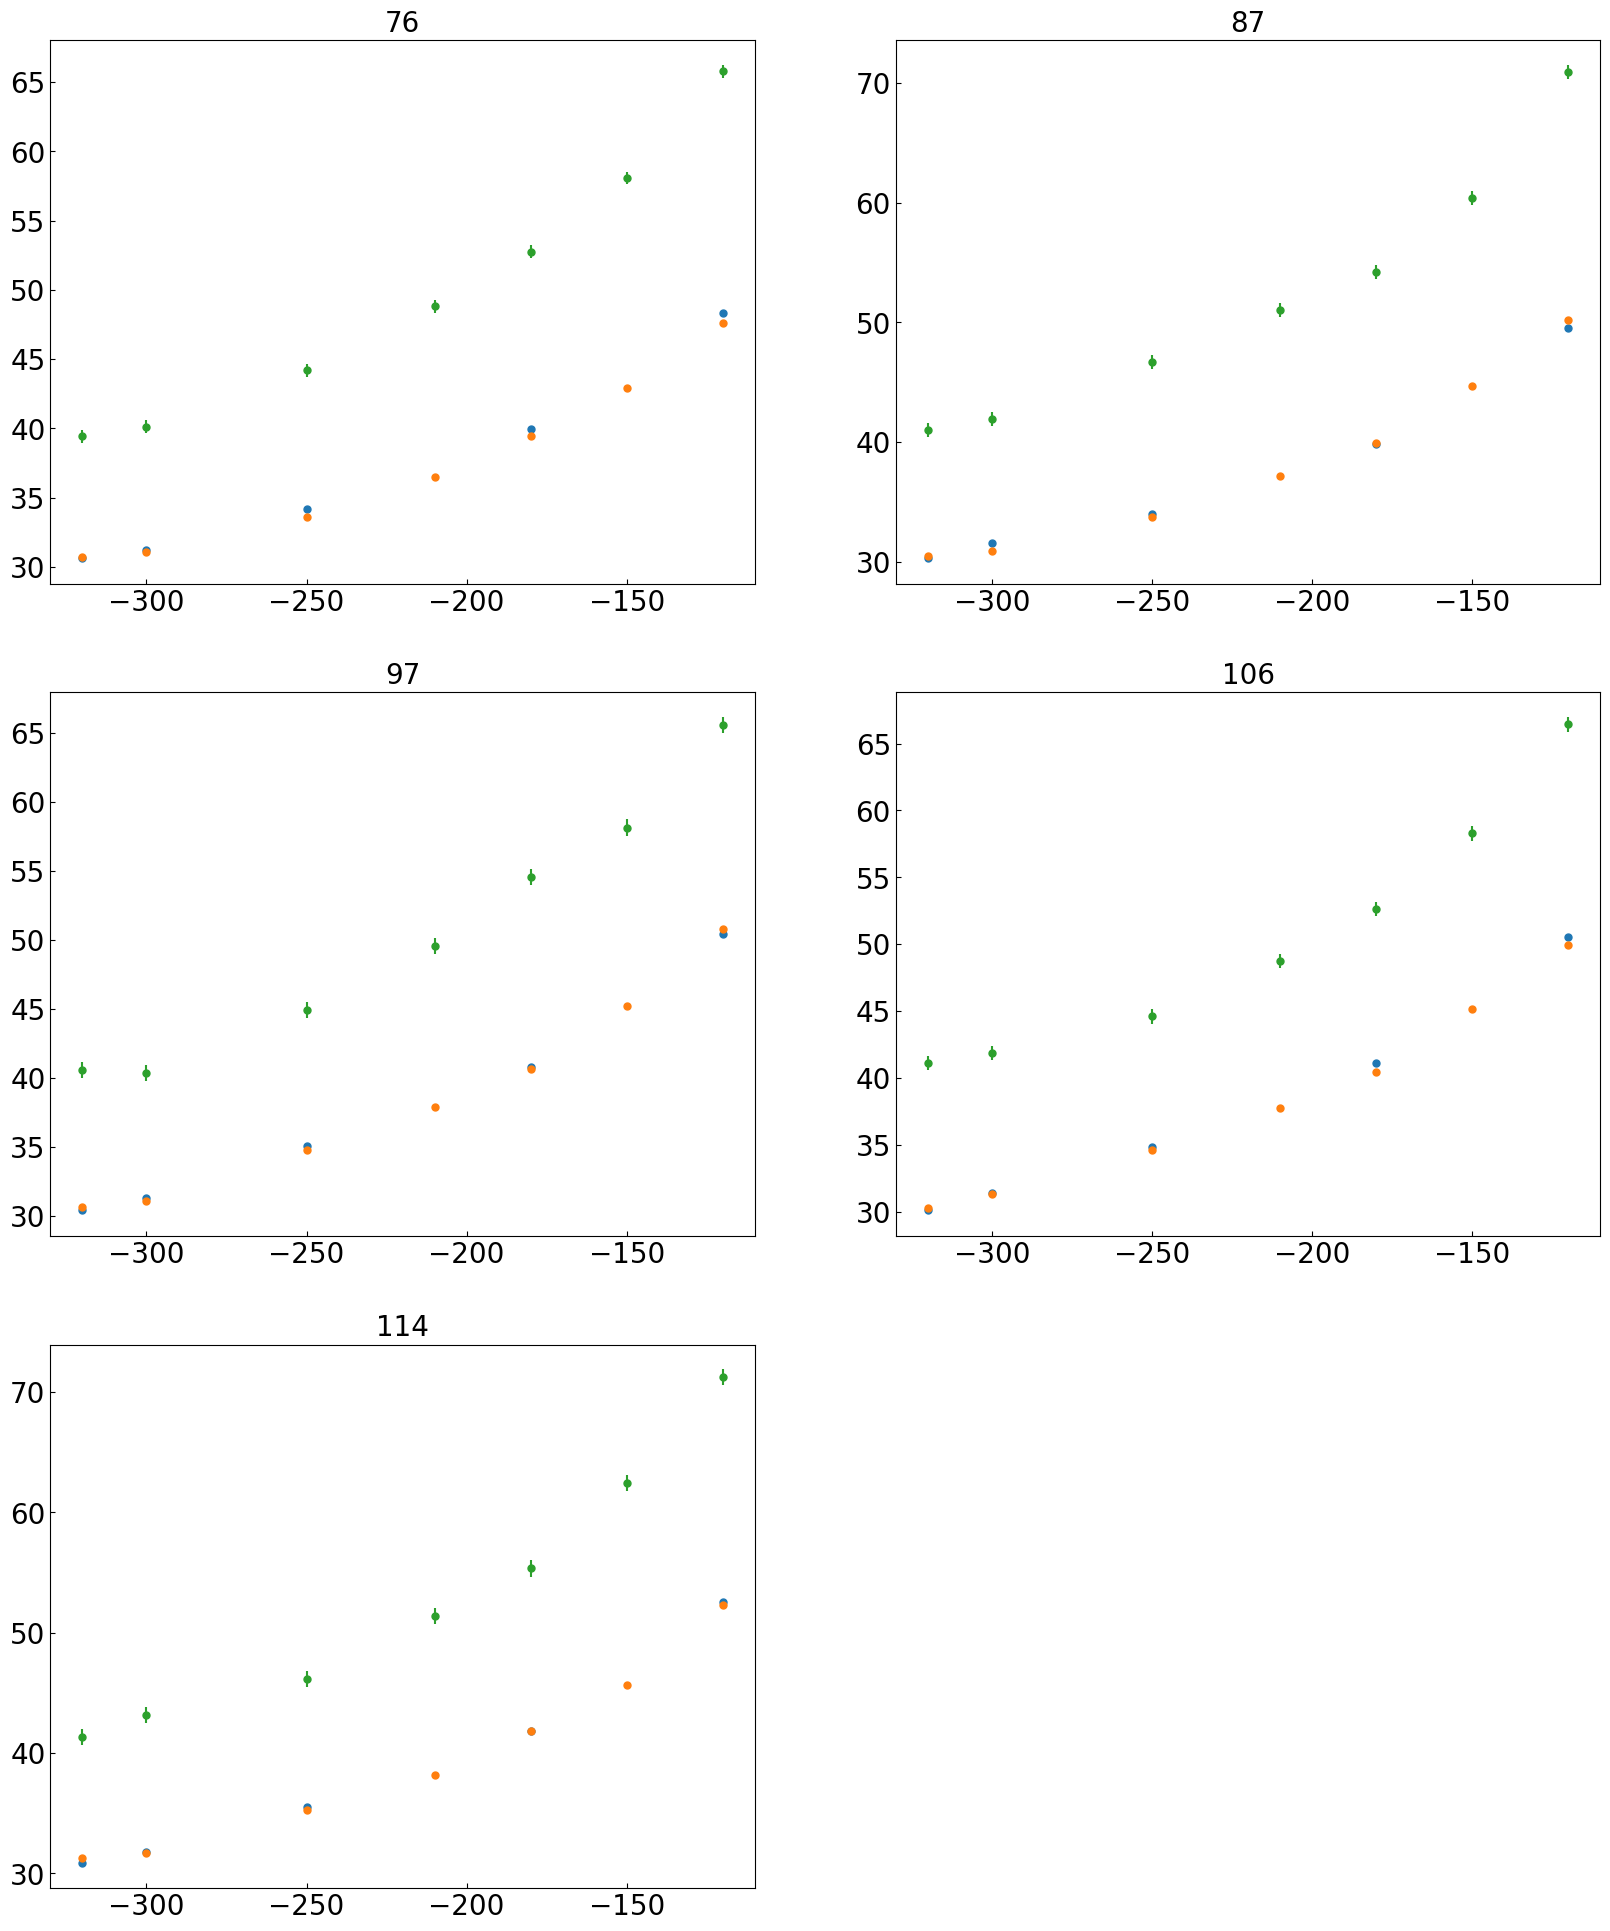

In [44]:
nrows,ncols=3,2
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
for i in range(len(centroidsLoose)):
    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%pixel[i],size=20)
    plt.errorbar(bias,centroidsLoose[i],yerr = np.sqrt(np.diag(centroid_errorsLoose[i]))[1],fmt='o',markersize=5)
    plt.errorbar(bias2,centroidsLoose_2[i],yerr = np.sqrt(np.diag(centroid_errorsLoose_2[i]))[1],fmt='o',markersize=5)
    plt.errorbar(bias2,centroidsLoose_Cd[i],yerr = np.sqrt(np.diag(centroid_errorsLoose_Cd[i]))[1],fmt='o',markersize=5)

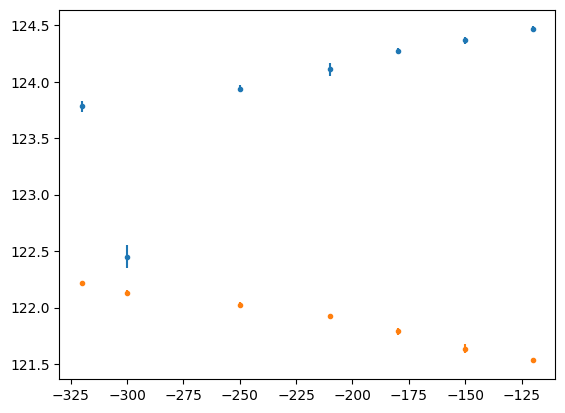

In [47]:
plt.errorbar(bias2,tempSn,yerr = tempSn_err,fmt='o',markersize=3)
plt.errorbar(bias2,tempSn2,yerr = tempSn2_err,fmt='o',markersize=3)
plt.show()

In [ ]:
nrows,ncols=3,3
py.figure(figsize=(10*ncols,8*nrows))
cnt = 0
binNum = 100
centroidsBothPeaks = []
centroid_errorsBothPeaks = []
for j in range(len(pixel)):

    cnt+=1
    ax=py.subplot(nrows,ncols,cnt)
    ax.set_prop_cycle('color', colors)
    ax.tick_params(direction='in',which='both',axis='both',labelsize=20)
    ax.set_title('%d'%pixel[j],size=20)
    cent = []
    err_list = []
    for i in range(len(bias)):
        
        y,x = np.histogram(riseTime_bothPeaks[i][j],bins = np.linspace(ranges[i][0],ranges[i][1],100))
        x = np.linspace(ranges[i][0],ranges[i][1],99)
        params, err = curve_fit(gaussian,x,y,p0 = p0[i])
        
        cent.append(params[1])
        err_list.append(err[1])
        
        ax.hist(riseTime_bothPeaks[i][j],bins=100,range = (ranges[i][0],ranges[i][1]),label = '%d:%.2f'%(bias[i],params[1]),alpha=0.75)
        
        ax.plot(x,gaussian(x,*params),color = colors[i])
        
        ax.legend(prop={'size':20},title = "Cut (keV): 350-395")
    centroidsBothPeaks.append(cent)
    centroid_errorsBothPeaks.append(err_list)
py.tight_layout()

In [29]:
len(riseTime_singlePeakLoose_2)

7

In [65]:
df = {}
for i in range(len(riseTime_singlePeakLoose_Cd)):
    d = pd.DataFrame(riseTime_singlePeakLoose_Cd[i]).T
    d = d.rename(columns={0: '76', 1: '87',2:'97',3:'106',4:'114'})
    df[bias2[i]] = d
    d.to_csv('risetimeCd%d.csv'%runs_Cd[i],mode = 'w', header = True, index = False)

In [64]:
df

{-320:              76          87         97         106        114
 0     59.497822  111.264224  74.446970   40.081945  36.091921
 1    182.573522  331.348128  43.471559   39.241546  46.089999
 2     51.643525   38.181989  35.665716  109.336824  29.552953
 3     38.534083   58.463898  80.848410   44.261013  39.224827
 4     33.980891   46.699428  38.531615   48.848533  79.444468
 ..          ...         ...        ...         ...        ...
 401   37.528348         NaN        NaN         NaN        NaN
 402   40.947750         NaN        NaN         NaN        NaN
 403   41.219079         NaN        NaN         NaN        NaN
 404   56.916903         NaN        NaN         NaN        NaN
 405   44.941408         NaN        NaN         NaN        NaN
 
 [406 rows x 5 columns],
 -300:             76          87           97        106        114
 0    37.683015   38.758657    40.226572  30.042506  47.917015
 1    53.325542  141.058550    38.939744  31.832488  50.017829
 2    47.060209 

In [51]:
pd.DataFrame(df,index=np.arange(0,144),columns = pixel)

,76,87,97,106,114
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
139,NaN,NaN,NaN,NaN,NaN
140,NaN,NaN,NaN,NaN,NaN
141,NaN,NaN,NaN,NaN,NaN
142,NaN,NaN,NaN,NaN,NaN


In [65]:
import itertools

fields = ['bias voltage','76','87','97','106','114']

with open("riseTimeSnNew.csv", "w", newline='') as f:
    w = csv.DictWriter(f, fields)
    w.writeheader()
    for k in df:
        w.writerow({field: df[k].get(field) or k for field in fields})

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [96]:

fields = ['bias voltage','76','87','97','106','114']

with open("risetimeSnNew.csv", "w") as csv_file:
  csvwriter = csv.writer(csv_file)
  csvwriter.writerow(['bias voltage', '76', '87','97','106','114'])
  for org in df:
     csvwriter.writerow((org, df[org]['76'], df[org]['87'], df[org]['97'],df[org]['106'], df[org]['114']))
    w = csv.DictWriter(f, fields)
    w.writeheader()
    for k in dw:
        w.writerow({field: dw[k].get(field) or k for field in fields})

In [107]:
with open('risetimeSnNew.csv',newline='') as file:
    data = {}
    i=['76', '87','97','106','114']
    for row in csv.DictReader(file,fieldnames = fields):
#         for x in i:
#             print(row[x])
        for key, value in row.items():
            if key not in data:
                data[key] = []
            data[value] = {}
            for j in range(len(i)):
                data[value][i[j]] = row[i[j]]

In [105]:
data

{'bias voltage': {'76': '76',
  '87': '87',
  '97': '97',
  '106': '106',
  '114': '114'},
 '76': {'76': '76', '87': '87', '97': '97', '106': '106', '114': '114'},
 '87': {'76': '76', '87': '87', '97': '97', '106': '106', '114': '114'},
 '97': {'76': '76', '87': '87', '97': '97', '106': '106', '114': '114'},
 '106': {'76': '76', '87': '87', '97': '97', '106': '106', '114': '114'},
 '114': {'76': '76', '87': '87', '97': '97', '106': '106', '114': '114'},
 '-320': {'76': '0      31.787903\n1      29.923819\n2      32.901037\n3      26.448479\n4      31.499559\n         ...    \n139    27.860807\n140    31.754915\n141    30.914140\n142    29.904581\n143    31.175742\nName: 76, Length: 144, dtype: float64',
  '87': '0      32.650743\n1      33.841882\n2      32.281573\n3      29.673693\n4      29.831935\n         ...    \n139          NaN\n140          NaN\n141          NaN\n142          NaN\n143          NaN\nName: 87, Length: 144, dtype: float64',
  '97': '0      28.209970\n1      30.059

In [2]:
new_dict={}
with open('risetimeSnNew.csv','r') as csv_file:
    data=csv.DictReader(csv_file)
    i=['76', '87','97','106','114']
    
    for row in data:
        dict_brand=new_dict.get(row['bias voltage'],dict())
        for k in i:
            db = dict_brand.get(row[k],dict())
            db[k] = {j:row[k] for j in range(int(len(row[k].split())/2))}
            dict_brand[k] = db
            new_dict[row['bias voltage']]=dict_brand
print(new_dict)

{'-320': {'76': {'76': {0: '0      31.787903\n1      29.923819\n2      32.901037\n3      26.448479\n4      31.499559\n         ...    \n139    27.860807\n140    31.754915\n141    30.914140\n142    29.904581\n143    31.175742\nName: 76, Length: 144, dtype: float64', 1: '0      31.787903\n1      29.923819\n2      32.901037\n3      26.448479\n4      31.499559\n         ...    \n139    27.860807\n140    31.754915\n141    30.914140\n142    29.904581\n143    31.175742\nName: 76, Length: 144, dtype: float64', 2: '0      31.787903\n1      29.923819\n2      32.901037\n3      26.448479\n4      31.499559\n         ...    \n139    27.860807\n140    31.754915\n141    30.914140\n142    29.904581\n143    31.175742\nName: 76, Length: 144, dtype: float64', 3: '0      31.787903\n1      29.923819\n2      32.901037\n3      26.448479\n4      31.499559\n         ...    \n139    27.860807\n140    31.754915\n141    30.914140\n142    29.904581\n143    31.175742\nName: 76, Length: 144, dtype: float64', 4: '0   

In [114]:
new_dict['-300']['76']

'0      31.781084\n1      32.791523\n2      29.996825\n3      30.981379\n4      26.579370\n         ...    \n154    29.723276\n155    31.459384\n156    26.647048\n157    30.509944\n158    30.748640\nName: 76, Length: 159, dtype: float64'